In [140]:
import json
import pandas as pd
from pathlib import Path

# Path of your final dataset
DATA_PATH = "/content/corpus_documents.jsonl"

# Read JSONL file
records = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

# Convert JSON records into DataFrame
df = pd.DataFrame(records)

print("Number of documents:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

Number of documents: 30
Number of columns: 8

Columns:
['doc_id', 'file_name', 'format', 'owner', 'topic', 'source', 'raw_chars', 'text']


In [141]:
display(df.head())

,doc_id,file_name,format,owner,topic,source,raw_chars,text
0,1,agritech.tnau.ac.in_sri.html,.html,Amrutheshwari V,Rice cultivation practices,https://agritech.tnau.ac.in/sri.html,5652,Home | About Us | Success Stories | Farmers As...
1,2,www.agritech.tnau.ac.in_expert_system_paddy_cu...,.html,Amrutheshwari V,Rice cultivation practices,http://www.agritech.tnau.ac.in/expert_system/p...,12659,HOME ABOUT US CONTACT US Sub Topics Principles...
2,3,Rice-1.pdf,.pdf,Amrutheshwari V,Rice cultivation practices,https://drive.google.com/file/d/1W3_KGIa-sMnhv...,26086,IRRI Rice Production Manual IRRI is the world’...
3,4,Copy_of_rice_qa.json,.json,Amrutheshwari V,Rice cultivation practices,https://drive.google.com/file/d/1BH0ixjCIii10r...,44051,Answer the following question How can I promot...
4,5,Rice-2.pdf,.pdf,Amrutheshwari V,Rice cultivation practices,https://drive.google.com/file/d/1690A-9C6r53xm...,59500,Growing upland rice: a production handbook Afr...


In [142]:
print("Document format distribution:")
print(df["format"].value_counts())

Document format distribution:
format
.html    13
.pdf     10
.docx     4
.json     2
.csv      1
Name: count, dtype: int64


In [143]:
df["text"]

,text
0,Home | About Us | Success Stories | Farmers As...
1,HOME ABOUT US CONTACT US Sub Topics Principles...
2,IRRI Rice Production Manual IRRI is the world’...
3,Answer the following question How can I promot...
4,Growing upland rice: a production handbook Afr...
5,editorial Front Plant Sci . 2023 Nov 22;14:133...
6,Answer the following question How can I promot...
7,Home Step-by-step production Growth Pests and ...
8,INTEGRATED PEST MANAGEMENT PACKAGE FOR RICE An...
9,University of Nebraska - Lincoln University of...


In [144]:
print("Topic distribution:")
print(df["topic"].value_counts())

Topic distribution:
topic
Rice cultivation practices                                                                   5
Pest management in rice                                                                      5
Wheat cultivation practices                                                                  5
Pest management in wheat                                                                     5
Carrot pest, disease, pesticide management, insecticide, fungicide, nematode and IPM         5
Carrot pesticide application, dosage, herbicide, spraying safety and pre-harvest interval    5
Name: count, dtype: int64


In [145]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
doc_id       0
file_name    0
format       0
owner        0
topic        0
source       0
raw_chars    0
text         0
dtype: int64


In [146]:
empty_text = df["text"].fillna("").str.strip().eq("").sum()

print("Documents with empty text:", empty_text)

Documents with empty text: 0


In [147]:
df["text_length"] = df["text"].str.len()

print(df["text_length"].describe())

count        30.000000
mean      61205.866667
std      131000.541137
min         571.000000
25%        7417.500000
50%       15805.000000
75%       51607.000000
max      666021.000000
Name: text_length, dtype: float64


In [148]:
display(
    df[
        ["doc_id", "format", "topic", "text_length"]
    ].sort_values("text_length", ascending=False)
)

,doc_id,format,topic,text_length
14,15,.csv,Wheat cultivation practices,666021
9,10,.pdf,Pest management in rice,331212
23,24,.pdf,"Carrot pest, disease, pesticide management, in...",141110
27,28,.html,"Carrot pesticide application, dosage, herbicid...",89539
8,9,.pdf,Pest management in rice,85390
16,17,.pdf,Pest management in wheat,72459
4,5,.pdf,Rice cultivation practices,58305
18,19,.pdf,Pest management in wheat,53044
19,20,.docx,Pest management in wheat,47296
11,12,.pdf,Wheat cultivation practices,46940


In [149]:
import re

def clean_text(text):
    text = str(text)

    # Remove control characters
    text = re.sub(r"[\x00-\x1F\x7F]", " ", text)

    # Normalize multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["clean_text"] = df["text"].apply(clean_text)

In [150]:
print("Original:")
print(df.loc[0, "text"][:500])

print("\nCleaned:")
print(df.loc[0, "clean_text"][:500])

Original:
Home | About Us | Success Stories | Farmers Association | Farmers' Innovation | Publications | Contact TNAU Agritech Portal :: System of Rice Intensification (SRI) 1. Components of System of Rice Intensification (SRI) Young Seedling (14 days old) Single Seedling/hill Square Planting Weeding by Cono Weeder Alternate Wetting & Drying LCC based N Management 2. System of Rice Intensification (SRI) Cultivation 2.1. Season Dry season with assured irrigation is more suitable. Difficulty in crop establi

Cleaned:
Home | About Us | Success Stories | Farmers Association | Farmers' Innovation | Publications | Contact TNAU Agritech Portal :: System of Rice Intensification (SRI) 1. Components of System of Rice Intensification (SRI) Young Seedling (14 days old) Single Seedling/hill Square Planting Weeding by Cono Weeder Alternate Wetting & Drying LCC based N Management 2. System of Rice Intensification (SRI) Cultivation 2.1. Season Dry season with assured irrigation is more suitable. Diffi

In [151]:
!pip install nltk

In [152]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [153]:
from nltk.tokenize import word_tokenize

df["nltk_tokens"] = df["clean_text"].apply(word_tokenize)

In [154]:
print(df.loc[0, "nltk_tokens"][:100])

['Home', '|', 'About', 'Us', '|', 'Success', 'Stories', '|', 'Farmers', 'Association', '|', 'Farmers', "'", 'Innovation', '|', 'Publications', '|', 'Contact', 'TNAU', 'Agritech', 'Portal', ':', ':', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', '1', '.', 'Components', 'of', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', 'Young', 'Seedling', '(', '14', 'days', 'old', ')', 'Single', 'Seedling/hill', 'Square', 'Planting', 'Weeding', 'by', 'Cono', 'Weeder', 'Alternate', 'Wetting', '&', 'Drying', 'LCC', 'based', 'N', 'Management', '2', '.', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', 'Cultivation', '2.1', '.', 'Season', 'Dry', 'season', 'with', 'assured', 'irrigation', 'is', 'more', 'suitable', '.', 'Difficulty', 'in', 'crop', 'establishment', 'may', 'be', 'seen', 'in', 'areas', 'with', 'heavy', 'downpour', '(', 'NE']


In [155]:
all_tokens = [
    token
    for token_list in df["nltk_tokens"]
    for token in token_list
]

total_tokens = len(all_tokens)

print("Total token occurrences:", total_tokens)

Total token occurrences: 344156


In [156]:
dictionary = set(all_tokens)

print("Unique tokens / dictionary size:", len(dictionary))

Unique tokens / dictionary size: 22169


In [157]:
vocabulary_ratio = len(dictionary) / len(all_tokens)

print("Vocabulary ratio:", vocabulary_ratio)

Vocabulary ratio: 0.06441555573635212


In [158]:
def normalize_term(token):
    token = token.lower()

    # Remove punctuation around the term
    token = re.sub(r"^[^\w]+|[^\w]+$", "", token)

    return token


normalized_tokens = [
    normalize_term(token)
    for token in all_tokens
]

# Remove empty strings
normalized_tokens = [
    token for token in normalized_tokens
    if token
]

term_dictionary = set(normalized_tokens)

print("Total normalized terms:", len(normalized_tokens))
print("Unique normalized terms:", len(term_dictionary))

Total normalized terms: 282942
Unique normalized terms: 18081


In [159]:
exercise1_results = pd.DataFrame({
    "Measure": [
        "Total token occurrences",
        "Unique raw tokens",
        "Total normalized terms",
        "Unique normalized terms"
    ],
    "Count": [
        len(all_tokens),
        len(dictionary),
        len(normalized_tokens),
        len(term_dictionary)
    ]
})

display(exercise1_results)

,Measure,Count
0,Total token occurrences,344156
1,Unique raw tokens,22169
2,Total normalized terms,282942
3,Unique normalized terms,18081


In [160]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [161]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [162]:
def spacy_tokenize(text):
    doc = nlp(str(text))
    return [token.text for token in doc]

df["spacy_tokens"] = df["clean_text"].apply(spacy_tokenize)

In [163]:
df["nltk_token_count"] = df["nltk_tokens"].apply(len)
df["spacy_token_count"] = df["spacy_tokens"].apply(len)

token_count_comparison = df[
    [
        "doc_id",
        "topic",
        "nltk_token_count",
        "spacy_token_count"
    ]
]

display(token_count_comparison)

,doc_id,topic,nltk_token_count,spacy_token_count
0,1,Rice cultivation practices,900,937
1,2,Rice cultivation practices,1876,1971
2,3,Rice cultivation practices,4767,4929
3,4,Rice cultivation practices,7337,7103
4,5,Rice cultivation practices,16685,18257
5,6,Pest management in rice,2903,3041
6,7,Pest management in rice,2005,2047
7,8,Pest management in rice,1327,1342
8,9,Pest management in rice,15444,16109
9,10,Pest management in rice,60235,60618


In [164]:
print("NLTK tokens:")
print(df.loc[0, "nltk_tokens"][:100])

print("\n" + "="*80 + "\n")

print("spaCy tokens:")
print(df.loc[0, "spacy_tokens"][:100])

NLTK tokens:
['Home', '|', 'About', 'Us', '|', 'Success', 'Stories', '|', 'Farmers', 'Association', '|', 'Farmers', "'", 'Innovation', '|', 'Publications', '|', 'Contact', 'TNAU', 'Agritech', 'Portal', ':', ':', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', '1', '.', 'Components', 'of', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', 'Young', 'Seedling', '(', '14', 'days', 'old', ')', 'Single', 'Seedling/hill', 'Square', 'Planting', 'Weeding', 'by', 'Cono', 'Weeder', 'Alternate', 'Wetting', '&', 'Drying', 'LCC', 'based', 'N', 'Management', '2', '.', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', 'Cultivation', '2.1', '.', 'Season', 'Dry', 'season', 'with', 'assured', 'irrigation', 'is', 'more', 'suitable', '.', 'Difficulty', 'in', 'crop', 'establishment', 'may', 'be', 'seen', 'in', 'areas', 'with', 'heavy', 'downpour', '(', 'NE']


spaCy tokens:
['Home', '|', 'About', 'Us', '|', 'Success', 'Stories', '|', 'Farmers', 'Association', '|', 'Farmers', 

In [165]:
def compare_tokens(nltk_tokens, spacy_tokens):
    max_len = max(len(nltk_tokens), len(spacy_tokens))

    differences = []

    for i in range(max_len):
        nltk_token = nltk_tokens[i] if i < len(nltk_tokens) else "<none>"
        spacy_token = spacy_tokens[i] if i < len(spacy_tokens) else "<none>"

        if nltk_token != spacy_token:
            differences.append((nltk_token, spacy_token))

    return differences

In [166]:
for i, row in df.iterrows():

    differences = compare_tokens(
        row["nltk_tokens"],
        row["spacy_tokens"]
    )

    if differences:
        print("\nDocument:", row["doc_id"])
        print("Topic:", row["topic"])

        for nltk_token, spacy_token in differences[:10]:
            print(
                f"NLTK: {nltk_token!r:25} | "
                f"spaCy: {spacy_token!r}"
            )

        print("-" * 80)


Document: 1
Topic: Rice cultivation practices
NLTK: 'Seedling/hill'           | spaCy: 'Seedling'
NLTK: 'Square'                  | spaCy: '/'
NLTK: 'Planting'                | spaCy: 'hill'
NLTK: 'Weeding'                 | spaCy: 'Square'
NLTK: 'by'                      | spaCy: 'Planting'
NLTK: 'Cono'                    | spaCy: 'Weeding'
NLTK: 'Weeder'                  | spaCy: 'by'
NLTK: 'Alternate'               | spaCy: 'Cono'
NLTK: 'Wetting'                 | spaCy: 'Weeder'
NLTK: '&'                       | spaCy: 'Alternate'
--------------------------------------------------------------------------------

Document: 2
Topic: Rice cultivation practices
NLTK: 'i'                       | spaCy: 'i.'
NLTK: '.'                       | spaCy: 'Need'
NLTK: 'Need'                    | spaCy: 'more'
NLTK: 'more'                    | spaCy: 'uniform'
NLTK: 'uniform'                 | spaCy: 'land'
NLTK: 'land'                    | spaCy: 'leveling'
NLTK: 'leveling'                | spa

In [167]:
examples = [
    "root-knot",
    "pre-harvest",
    "rice-wheat",
    "2-3",
    "50%",
    "30 kg",
    "750 ml",
    "2,000",
    "sq.m"
]

for example in examples:
    print(f"\nText: {example}")
    print("NLTK :", word_tokenize(example))


Text: root-knot
NLTK : ['root-knot']

Text: pre-harvest
NLTK : ['pre-harvest']

Text: rice-wheat
NLTK : ['rice-wheat']

Text: 2-3
NLTK : ['2-3']

Text: 50%
NLTK : ['50', '%']

Text: 30 kg
NLTK : ['30', 'kg']

Text: 750 ml
NLTK : ['750', 'ml']

Text: 2,000
NLTK : ['2,000']

Text: sq.m
NLTK : ['sq.m']


In [168]:
for example in examples:
    doc = nlp(example)
    print(f"\nText: {example}")
    print("spaCy:", [token.text for token in doc])


Text: root-knot
spaCy: ['root', '-', 'knot']

Text: pre-harvest
spaCy: ['pre', '-', 'harvest']

Text: rice-wheat
spaCy: ['rice', '-', 'wheat']

Text: 2-3
spaCy: ['2', '-', '3']

Text: 50%
spaCy: ['50', '%']

Text: 30 kg
spaCy: ['30', 'kg']

Text: 750 ml
spaCy: ['750', 'ml']

Text: 2,000
spaCy: ['2,000']

Text: sq.m
spaCy: ['sq.m']


In [169]:
# ==========================================
# EXERCISE 2 - OBSERVED TOKENIZATION ISSUES
# ==========================================

exercise2_observations = pd.DataFrame({
    "Actual Corpus Example": [
        "root-knot",
        "pre-harvest",
        "rice-wheat",
        "2-3",
        "50%",
        "30 kg",
        "750 ml"
    ],

    "Tokenization Issue": [
        "Hyphenated agricultural term may be split",
        "Hyphenated agricultural term may be split",
        "Compound crop expression may be split",
        "Numeric range may be split",
        "Percentage may be split into number and symbol",
        "Number and unit may be separated",
        "Number and unit may be separated"
    ],

    "Improvement": [
        "Preserve meaningful hyphenated domain terms",
        "Preserve meaningful hyphenated domain terms",
        "Preserve compound agricultural expression",
        "Preserve numeric range",
        "Preserve percentage expression",
        "Preserve number-unit expression",
        "Preserve number-unit expression"
    ]
})

display(exercise2_observations)

,Actual Corpus Example,Tokenization Issue,Improvement
0,root-knot,Hyphenated agricultural term may be split,Preserve meaningful hyphenated domain terms
1,pre-harvest,Hyphenated agricultural term may be split,Preserve meaningful hyphenated domain terms
2,rice-wheat,Compound crop expression may be split,Preserve compound agricultural expression
3,2-3,Numeric range may be split,Preserve numeric range
4,50%,Percentage may be split into number and symbol,Preserve percentage expression
5,30 kg,Number and unit may be separated,Preserve number-unit expression
6,750 ml,Number and unit may be separated,Preserve number-unit expression


In [170]:
!pip install scikit-learn

In [171]:
import re

def custom_tokenize(text):

    text = str(text)

    # ------------------------------------------------
    # 1. Protect URLs
    # ------------------------------------------------
    text = re.sub(
        r'https?://[^\s]+',
        lambda m: f" {m.group(0)} ",
        text
    )

    # ------------------------------------------------
    # 2. Protect percentages
    # Example: 50%, 10.5%
    # ------------------------------------------------
    text = re.sub(
        r'\b\d+(?:\.\d+)?%',
        lambda m: f" {m.group(0)} ",
        text
    )

    # ------------------------------------------------
    # 3. Protect number ranges
    # Example: 2-3, 10-15
    # ------------------------------------------------
    text = re.sub(
        r'\b\d+(?:\.\d+)?-\d+(?:\.\d+)?\b',
        lambda m: f" {m.group(0)} ",
        text
    )

    # ------------------------------------------------
    # 4. Protect number + unit
    # Example: 30 kg, 750 ml, 20 cm
    # ------------------------------------------------
    units = (
        r'kg|g|mg|ha|acre|acres|cm|mm|m|ml|l|'
        r'litre|liter|ton|tons'
    )

    text = re.sub(
        rf'\b\d+(?:\.\d+)?\s*(?:{units})\b',
        lambda m: f" {m.group(0)} ",
        text,
        flags=re.IGNORECASE
    )

    # ------------------------------------------------
    # 5. Protect comma-separated numbers
    # Example: 2,000 / 50,000
    # ------------------------------------------------
    text = re.sub(
        r'\b\d{1,3}(?:,\d{3})+(?:\.\d+)?\b',
        lambda m: f" {m.group(0)} ",
        text
    )

    # ------------------------------------------------
    # 6. Protect hyphenated words
    # Example: root-knot, pre-harvest, rice-wheat
    # ------------------------------------------------
    text = re.sub(
        r'\b[A-Za-z0-9]+(?:-[A-Za-z0-9]+)+\b',
        lambda m: f" {m.group(0)} ",
        text
    )

    # ------------------------------------------------
    # 7. Protect abbreviations
    # Example: sq.m, Ph.D
    # ------------------------------------------------
    text = re.sub(
        r'\b[A-Za-z]+(?:\.[A-Za-z]+)+\b',
        lambda m: f" {m.group(0)} ",
        text
    )

    # ------------------------------------------------
    # 8. Finally tokenize
    # ------------------------------------------------
    tokens = re.findall(
        r'https?://[^\s]+'
        r'|\b\d+(?:\.\d+)?%'
        r'|\b\d+(?:\.\d+)?-\d+(?:\.\d+)?\b'
        rf'|\b\d+(?:\.\d+)?\s*(?:{units})\b'
        r'|\b\d{1,3}(?:,\d{3})+(?:\.\d+)?\b'
        r'|\b[A-Za-z0-9]+(?:-[A-Za-z0-9]+)+\b'
        r'|\b[A-Za-z]+(?:\.[A-Za-z]+)+\b'
        r'|\b[A-Za-z0-9]+\b'
        r'|[^\w\s]',
        text,
        flags=re.IGNORECASE
    )

    return tokens

In [172]:
for example in examples:
    print(f"\nText: {example}")
    print("Custom:", custom_tokenize(example))


Text: root-knot
Custom: ['root-knot']

Text: pre-harvest
Custom: ['pre-harvest']

Text: rice-wheat
Custom: ['rice-wheat']

Text: 2-3
Custom: ['2-3']

Text: 50%
Custom: ['50%']

Text: 30 kg
Custom: ['30 kg']

Text: 750 ml
Custom: ['750 ml']

Text: 2,000
Custom: ['2,000']

Text: sq.m
Custom: ['sq.m']


In [173]:
df["custom_tokens"] = df["clean_text"].apply(custom_tokenize)

In [174]:
df["custom_token_count"] = df["custom_tokens"].apply(len)

In [175]:
tokenizer_comparison = df[
    [
        "doc_id",
        "topic",
        "nltk_token_count",
        "spacy_token_count",
        "custom_token_count"
    ]
]

display(tokenizer_comparison)

,doc_id,topic,nltk_token_count,spacy_token_count,custom_token_count
0,1,Rice cultivation practices,900,937,920
1,2,Rice cultivation practices,1876,1971,1907
2,3,Rice cultivation practices,4767,4929,4883
3,4,Rice cultivation practices,7337,7103,7354
4,5,Rice cultivation practices,16685,18257,17100
5,6,Pest management in rice,2903,3041,3132
6,7,Pest management in rice,2005,2047,2006
7,8,Pest management in rice,1327,1342,1330
8,9,Pest management in rice,15444,16109,18888
9,10,Pest management in rice,60235,60618,60663


In [176]:
total_nltk = df["nltk_token_count"].sum()
total_spacy = df["spacy_token_count"].sum()
total_custom = df["custom_token_count"].sum()

print("Total NLTK tokens  :", total_nltk)
print("Total spaCy tokens :", total_spacy)
print("Total Custom tokens:", total_custom)

Total NLTK tokens  : 344156
Total spaCy tokens : 342212
Total Custom tokens: 367811


In [177]:
nltk_vocab = set(
    token
    for tokens in df["nltk_tokens"]
    for token in tokens
)

spacy_vocab = set(
    token
    for tokens in df["spacy_tokens"]
    for token in tokens
)

custom_vocab = set(
    token
    for tokens in df["custom_tokens"]
    for token in tokens
)

print("NLTK vocabulary :", len(nltk_vocab))
print("spaCy vocabulary:", len(spacy_vocab))
print("Custom vocabulary:", len(custom_vocab))

NLTK vocabulary : 22169
spaCy vocabulary: 21147
Custom vocabulary: 20928


In [178]:
exercise3_results = pd.DataFrame({
    "Tokenizer": [
        "NLTK",
        "spaCy",
        "Custom"
    ],
    "Total Tokens": [
        total_nltk,
        total_spacy,
        total_custom
    ],
    "Vocabulary Size": [
        len(nltk_vocab),
        len(spacy_vocab),
        len(custom_vocab)
    ]
})

display(exercise3_results)

,Tokenizer,Total Tokens,Vocabulary Size
0,NLTK,344156,22169
1,spaCy,342212,21147
2,Custom,367811,20928


In [179]:
exercise2_analysis = pd.DataFrame({
    "Observed Problem": [
        "Hyphenated terms are split differently",
        "Numbers and units may be separated",
        "Percentages may be split",
        "Abbreviations may be split",
        "Domain-specific compound terms may be fragmented"
    ],
    "Possible Improvement": [
        "Custom hyphenation rule",
        "Custom number-unit rule",
        "Preserve percentage expressions",
        "Protect domain abbreviations",
        "Use domain-specific custom/hybrid tokenizer"
    ]
})

display(exercise2_analysis)

,Observed Problem,Possible Improvement
0,Hyphenated terms are split differently,Custom hyphenation rule
1,Numbers and units may be separated,Custom number-unit rule
2,Percentages may be split,Preserve percentage expressions
3,Abbreviations may be split,Protect domain abbreviations
4,Domain-specific compound terms may be fragmented,Use domain-specific custom/hybrid tokenizer


In [180]:
print(df.columns.tolist())

['doc_id', 'file_name', 'format', 'owner', 'topic', 'source', 'raw_chars', 'text', 'text_length', 'clean_text', 'nltk_tokens', 'spacy_tokens', 'nltk_token_count', 'spacy_token_count', 'custom_tokens', 'custom_token_count']


In [181]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")

def hybrid_tokenize(text):
    text = str(text)

    result_tokens = []
    protected_spans = []

    # Patterns that should remain together
    patterns = [
        r'https?://[^\\s]+',                              # URLs
        r'\b\d+(?:\.\d+)?%',                             # percentages
        r'\b\d+(?:\.\d+)?-\d+(?:\.\d+)?\b',             # ranges
        r'\b\d+(?:\.\d+)?\s*(?:kg|g|mg|ha|acre|cm|mm|m|ml|l|ton|tons)\b',
        r'\b[A-Za-z0-9]+(?:-[A-Za-z0-9]+)+\b',          # hyphenated terms
        r'\b[A-Za-z]+(?:\.[A-Za-z]+)+\b'                # abbreviations
    ]

    combined_protected_pattern = "|".join(patterns)

    # Find all protected matches and store their spans and original text
    for match in re.finditer(combined_protected_pattern, text, flags=re.IGNORECASE):
        protected_spans.append((match.start(), match.end(), match.group(0)))

    last_idx = 0

    for start, end, original_value in protected_spans:
        # Tokenize the segment before the current protected span with spaCy
        if start > last_idx:
            segment = text[last_idx:start]
            doc_segment = nlp(segment)
            result_tokens.extend([token.text for token in doc_segment])

        # Add the protected original value as a single token
        result_tokens.append(original_value)
        last_idx = end

    # Tokenize any remaining text after the last protected span with spaCy
    if last_idx < len(text):
        segment = text[last_idx:]
        doc_segment = nlp(segment)
        result_tokens.extend([token.text for token in doc_segment])

    # Filter out empty strings that might result from spaCy tokenization of pure whitespace
    return [token for token in result_tokens if token.strip()]

domain_tokenization_examples = examples

exercise3_comparison = pd.DataFrame({
    "Input": domain_tokenization_examples,
    "NLTK": [
        word_tokenize(str(x))
        for x in domain_tokenization_examples
    ],
    "spaCy": [
        [token.text for token in nlp(str(x))]
        for x in domain_tokenization_examples
    ],
    "Custom": [
        custom_tokenize(x)
        for x in domain_tokenization_examples
    ],
    "Hybrid": [
        hybrid_tokenize(x)
        for x in domain_tokenization_examples
    ]
})

display(exercise3_comparison)

,Input,NLTK,spaCy,Custom,Hybrid
0,root-knot,[root-knot],"[root, -, knot]",[root-knot],[root-knot]
1,pre-harvest,[pre-harvest],"[pre, -, harvest]",[pre-harvest],[pre-harvest]
2,rice-wheat,[rice-wheat],"[rice, -, wheat]",[rice-wheat],[rice-wheat]
3,2-3,[2-3],"[2, -, 3]",[2-3],[2-3]
4,50%,"[50, %]","[50, %]",[50%],[50%]
5,30 kg,"[30, kg]","[30, kg]",[30 kg],[30 kg]
6,750 ml,"[750, ml]","[750, ml]",[750 ml],[750 ml]
7,"2,000","[2,000]","[2,000]","[2,000]","[2,000]"
8,sq.m,[sq.m],[sq.m],[sq.m],[sq.m]


Conclusion:
The hybrid tokenizer combines general-purpose tokenization
with domain-specific protection rules. It is useful when the
corpus contains both ordinary language and domain-specific
expressions.

In [182]:
!pip install tokenizers

In [183]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [184]:
BPE_FILE = "bpe_training.txt"

with open(BPE_FILE, "w", encoding="utf-8") as f:
    for text in df["clean_text"]:
        f.write(str(text).replace("\n", " ") + "\n")

print("BPE training file created.")

BPE training file created.


In [185]:
bpe_tokenizer = Tokenizer(
    BPE(unk_token="[UNK]")
)

bpe_tokenizer.pre_tokenizer = Whitespace()

In [186]:
trainer = BpeTrainer(
    vocab_size=5000,
    min_frequency=2,
    special_tokens=[
        "[UNK]",
        "[PAD]",
        "[CLS]",
        "[SEP]",
        "[MASK]"
    ]
)

In [187]:
bpe_tokenizer.train(
    [BPE_FILE],
    trainer
)

In [188]:
test_words = [
    "rice",
    "wheat",
    "carrot",
    "pesticide",
    "insecticide",
    "herbicide",
    "fertilizer",
    "cultivation",
    "management",
    "agriculture"
]

for word in test_words:
    output = bpe_tokenizer.encode(word)

    print(f"{word:20} → {output.tokens}")

rice                 → ['rice']
wheat                → ['wheat']
carrot               → ['carrot']
pesticide            → ['pesticide']
insecticide          → ['insecticide']
herbicide            → ['herbicide']
fertilizer           → ['fertilizer']
cultivation          → ['cultivation']
management           → ['management']
agriculture          → ['agriculture']


In [189]:
def bpe_tokenize(text):
    return bpe_tokenizer.encode(str(text)).tokens

df["bpe_tokens"] = df["clean_text"].apply(bpe_tokenize)

In [190]:
df["bpe_token_count"] = df["bpe_tokens"].apply(len)

total_bpe_tokens = df["bpe_token_count"].sum()

print("Total BPE tokens:", total_bpe_tokens)

Total BPE tokens: 433731


In [191]:
bpe_vocab = set(
    token
    for tokens in df["bpe_tokens"]
    for token in tokens
)

print("BPE vocabulary size:", len(bpe_vocab))

BPE vocabulary size: 4877


In [192]:
# ==========================================
# EXERCISE 4 - BPE WORD CATEGORY ANALYSIS
# ==========================================

bpe_category_words = {
    "Common": [
        "plant",
        "water",
        "soil",
        "crop"
    ],

    "Rare": [
        "nematode",
        "caterpillar",
        "fungicide"
    ],

    "Domain-specific": [
        "fertilizer",
        "pesticide",
        "insecticide",
        "irrigation"
    ]
}

bpe_category_results = []

for category, words in bpe_category_words.items():

    for word in words:

        try:
            tokens = bpe_tokenizer.encode(word).tokens
        except:
            try:
                tokens = bpe_model.encode(word).tokens
            except:
                tokens = [word]

        bpe_category_results.append({
            "Category": category,
            "Word": word,
            "BPE Tokens": tokens,
            "Number of BPE Tokens": len(tokens),
            "Subword Formation": "Yes" if len(tokens) > 1 else "No"
        })

bpe_category_df = pd.DataFrame(bpe_category_results)

display(bpe_category_df)

,Category,Word,BPE Tokens,Number of BPE Tokens,Subword Formation
0,Common,plant,[plant],1,No
1,Common,water,[water],1,No
2,Common,soil,[soil],1,No
3,Common,crop,[crop],1,No
4,Rare,nematode,[nematode],1,No
5,Rare,caterpillar,[caterpillar],1,No
6,Rare,fungicide,[fungicide],1,No
7,Domain-specific,fertilizer,[fertilizer],1,No
8,Domain-specific,pesticide,[pesticide],1,No
9,Domain-specific,insecticide,[insecticide],1,No


In [193]:
# ==========================================
# BPE SUBWORD FORMATION SUMMARY
# ==========================================

subword_summary = (
    bpe_category_df
    .groupby("Category")
    .agg(
        Words_Tested=("Word", "count"),
        Words_Split=("Subword Formation", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

subword_summary["Split Percentage"] = (
    subword_summary["Words_Split"] /
    subword_summary["Words_Tested"] * 100
)

display(subword_summary)

,Category,Words_Tested,Words_Split,Split Percentage
0,Common,4,0,0.0
1,Domain-specific,4,0,0.0
2,Rare,3,0,0.0


In [194]:
from collections import Counter

all_custom_tokens = [
    token.lower()
    for token_list in df["custom_tokens"]
    for token in token_list
]

custom_frequency = Counter(all_custom_tokens)

print("Most common tokens:")
for token, count in custom_frequency.most_common(20):
    print(token, "→", count)

Most common tokens:
. → 25474
| → 17858
the → 13595
, → 12171
> → 8901
< → 8900
and → 8823
of → 8742
in → 5999
a → 5193
to → 4601
are → 4044
) → 3714
( → 3638
is → 3535
for → 2677
wheat → 2329
this → 2006
: → 1745
or → 1721


In [195]:
rare_words = [
    token
    for token, count in custom_frequency.items()
    if count == 1
]

print("Number of terms occurring only once:", len(rare_words))

print("\nSample rare words:")
print(rare_words[:50])

Number of terms occurring only once: 7428

Sample rare words:
['8 kg', 'gunny', 'pressmud', 'bio-gas', '17-17', '4 cm', 'segments', 'rame', 'pre-germinating', 'radical', 'm-2', '130g', 'hickness', '5mm', 'sprouted', 'watering', 'thrice', 'optional', 'lifting', 'pre-requisite', 'proposed', 'restoring', '2.5cm', 'hairline', '5.0cm', 'disappearance', 'ponded', 'managements', 'decided', 'ponni', '35kg', '30kg', '8  kg', '15  kg', 'plank', 'pegs', '18-22', '25-30', '35-40', '2000g', '20x20', 'no.of', '20-25', '20x10cm', 'sq.meter', '15x10cm', 'tungabhadra', 'command', 'sona', 'masuri']


In [196]:
common_words = [
    word for word, count in custom_frequency.most_common(20)
]

rare_words_sample = rare_words[:20]

print("COMMON WORDS")
print("=" * 60)

for word in common_words:
    print(f"{word:25} → {bpe_tokenizer.encode(word).tokens}")

print("\nRARE WORDS")
print("=" * 60)

for word in rare_words_sample:
    print(f"{word:25} → {bpe_tokenizer.encode(word).tokens}")

COMMON WORDS
.                         → ['.']
|                         → ['|']
the                       → ['the']
,                         → [',']
>                         → ['>']
<                         → ['<']
and                       → ['and']
of                        → ['of']
in                        → ['in']
a                         → ['a']
to                        → ['to']
are                       → ['are']
)                         → [')']
(                         → ['(']
is                        → ['is']
for                       → ['for']
wheat                     → ['wheat']
this                      → ['this']
:                         → [':']
or                        → ['or']

RARE WORDS
8 kg                      → ['8', 'kg']
gunny                     → ['g', 'un', 'ny']
pressmud                  → ['pres', 'sm', 'ud']
bio-gas                   → ['bio', '-', 'g', 'as']
17-17                     → ['17', '-', '17']
4 cm                      → ['4', 'cm']
se

In [197]:
domain_words = [
    "rice",
    "wheat",
    "carrot",
    "pesticide",
    "insecticide",
    "herbicide",
    "fungicide",
    "cultivation",
    "fertilizer",
    "irrigation",
    "nematode",
    "aphid",
    "caterpillar",
    "nitrogen",
    "phosphorus",
    "potassium"
]

print("DOMAIN-SPECIFIC BPE ANALYSIS")
print("=" * 70)

for word in domain_words:
    tokens = bpe_tokenizer.encode(word).tokens
    print(f"{word:20} → {tokens}")

DOMAIN-SPECIFIC BPE ANALYSIS
rice                 → ['rice']
wheat                → ['wheat']
carrot               → ['carrot']
pesticide            → ['pesticide']
insecticide          → ['insecticide']
herbicide            → ['herbicide']
fungicide            → ['fungicide']
cultivation          → ['cultivation']
fertilizer           → ['fertilizer']
irrigation           → ['irrigation']
nematode             → ['nematode']
aphid                → ['aphid']
caterpillar          → ['caterpillar']
nitrogen             → ['nitrogen']
phosphorus           → ['phosphorus']
potassium            → ['potassium']


In [198]:
import re

def hybrid_tokenize(text):
    text = str(text)

    protected = []

    # Patterns that should remain together
    patterns = [
        r'https?://[^\s]+',                              # URLs
        r'\b\d+(?:\.\d+)?%',                             # percentages
        r'\b\d+(?:\.\d+)?-\d+(?:\.\d+)?\b',             # ranges
        r'\b\d+(?:\.\d+)?\s*(?:kg|g|mg|ha|acre|cm|mm|m|ml|l|ton|tons)\b',
        r'\b[A-Za-z0-9]+(?:-[A-Za-z0-9]+)+\b',          # hyphenated terms
        r'\b[A-Za-z]+(?:\.[A-Za-z]+)+\b'                # abbreviations
    ]

    combined_pattern = "|".join(f"({p})" for p in patterns)

    def protect(match):
        value = match.group(0)
        placeholder = f"__PROTECTED_{len(protected)}__"
        protected.append(value)
        return placeholder

    text = re.sub(
        combined_pattern,
        protect,
        text,
        flags=re.IGNORECASE
    )

    # spaCy handles the remaining text
    doc = nlp(text)
    tokens = [token.text for token in doc]

    # Restore protected expressions
    restored_tokens = []

    for token in tokens:
        match = re.fullmatch(r"__PROTECTED_(\d+)__", token)

        if match:
            index = int(match.group(1))
            restored_tokens.append(protected[index])
        else:
            restored_tokens.append(token)

    return restored_tokens

In [199]:
df["hybrid_tokens"] = df["clean_text"].apply(hybrid_tokenize)

df["hybrid_token_count"] = df["hybrid_tokens"].apply(len)

In [200]:
hybrid_vocab = set(
    token
    for tokens in df["hybrid_tokens"]
    for token in tokens
)

print("Hybrid total tokens:", df["hybrid_token_count"].sum())
print("Hybrid vocabulary:", len(hybrid_vocab))

Hybrid total tokens: 350230
Hybrid vocabulary: 21612


In [201]:
import pandas as pd

# ==========================================
# EXERCISE 4 - FINAL TOKENIZER COMPARISON
# ==========================================

# Definitions for all token lists (copied from cell tHUr42ILNYif for self-containment)
nltk_all = [
    token
    for tokens in df["nltk_tokens"]
    for token in tokens
]

spacy_all = [
    token
    for tokens in df["spacy_tokens"]
    for token in tokens
]

custom_all = [
    token
    for tokens in df["custom_tokens"]
    for token in tokens
]

hybrid_all = [
    token
    for tokens in df["hybrid_tokens"]
    for token in tokens
]

bpe_all = [
    token
    for tokens in df["bpe_tokens"]
    for token in tokens
]


exercise4_summary = pd.DataFrame({
    "Method": [
        "NLTK",
        "spaCy",
        "Custom",
        "Hybrid",
        "BPE"
    ],

    "Token Count": [
        len(nltk_all),
        len(spacy_all),
        len(custom_all),
        len(hybrid_all),
        len(bpe_all)
    ],

    "Vocabulary Size": [
        len(set(nltk_all)),
        len(set(spacy_all)),
        len(set(custom_all)),
        len(set(hybrid_all)),
        len(set(bpe_all))
    ]
})

display(exercise4_summary)

,Method,Token Count,Vocabulary Size
0,NLTK,344156,22169
1,spaCy,342212,21147
2,Custom,367811,20928
3,Hybrid,350230,21612
4,BPE,433731,4877


In [202]:
def get_pos_and_chunks(text):
    doc = nlp(str(text))

    verbs = [
        token.text
        for token in doc
        if token.pos_ == "VERB"
    ]

    noun_phrases = [
        chunk.text
        for chunk in doc.noun_chunks
    ]

    return verbs, noun_phrases

In [203]:
df[["verbs", "noun_phrases"]] = df["clean_text"].apply(
    lambda x: pd.Series(get_pos_and_chunks(x))
)

In [204]:
print("VERBS:")
print(df.loc[0, "verbs"][:50])

print("\nNOUN PHRASES:")
print(df.loc[0, "noun_phrases"][:50])

VERBS:
['Weeding', 'based', 'seen', 'Prepare', 'plant', 'Select', 'Spread', 'used', 'raised', 'prevent', 'growing', 'needed', 'Mix', 'decomposed', 'Incorporate', 'Blending', 'Place', 'm', 'divided', 'Fill', 'sowing', 'Soak', 'drain', 'incubate', 'soaked', 'sow', 'grows', 'Sowing', 'Sow', 'weighing', 'weigh', 'sprouting', 'cover', 'using', 'rose', 'soak', 'remove', 'continue', 'required', 'completed', 'Sowing', 'Water', 'needed', 'thrice', 'keep', 'Protect', 'maintain', 'Drain', 'removing', 'Spraying']

NOUN PHRASES:
['Us', 'Agritech Portal', 'System', 'Rice Intensification', 'SRI', 'System', 'Rice Intensification', '(SRI', 'Single Seedling/hill Square Planting', 'Cono Weeder Alternate Wetting', 'Drying LCC', 'N Management', 'System', 'Rice Intensification', '(SRI) Cultivation', 'Season Dry season', 'assured irrigation', 'Difficulty', 'crop establishment', 'areas', 'heavy downpour', 'NE Monsoon periods', 'Tamil Nadu', 'Varieties Hybrids', 'varieties', 'heavy tillering', 'Nursery', 'Seed

In [205]:
from collections import Counter

all_verbs = [
    verb.lower()
    for verbs in df["verbs"]
    for verb in verbs
]

verb_frequency = Counter(all_verbs)

print("Top 20 verbs:")
for verb, count in verb_frequency.most_common(20):
    print(f"{verb:20} {count}")

Top 20 verbs:
answer               1532
|im_start|>system    1479
•                    739
used                 475
recommended          322
have                 278
using                212
reduce               203
apply                201
use                  192
based                188
applied              185
cause                168
occur                156
caused               148
include              144
control              136
has                  134
growing              128
make                 128


In [206]:
all_noun_phrases = [
    phrase.lower()
    for phrases in df["noun_phrases"]
    for phrase in phrases
]

noun_phrase_frequency = Counter(all_noun_phrases)

print("Top 20 noun phrases:")
for phrase, count in noun_phrase_frequency.most_common(20):
    print(f"{phrase:40} {count}")

Top 20 noun phrases:
you                                      1541
this question                            1480
a helpful and brilliant agronomist       1479
what                                     1015
that                                     799
wheat                                    766
it                                       622
which                                    550
<|im_end|> <|im_start|>assistant         479
i                                        459
they                                     451
brazil                                   301
|im_start|>user                          285
rice                                     259
weeds                                    230
the soil                                 221
n                                        204
plants                                   188
pests                                    184
farmers                                  182


In [207]:
print("Agricultural noun phrases:")
print(
    [
        (phrase, count)
        for phrase, count in noun_phrase_frequency.most_common(100)
        if any(
            word in phrase
            for word in [
                "rice",
                "wheat",
                "carrot",
                "pest",
                "disease",
                "fertilizer",
                "insect",
                "fung",
                "weed",
                "soil",
                "crop",
                "plant",
                "seed",
                "water",
                "irrigation"
            ]
        )
    ][:30]
)

Agricultural noun phrases:
[('wheat', 766), ('rice', 259), ('weeds', 230), ('the soil', 221), ('plants', 188), ('pests', 184), ('the crop', 172), ('insect pests', 167), ('carrots', 148), ('wheat culture', 132), ('pesticides', 128), ('water', 126), ('diseases', 126), ('soil', 103), ('the plant', 103), ('seeds', 102), ('insects', 99), ('the disease', 87), ('planting', 81), ('wheat cultivation', 76), ('seed', 74), ('crops', 72), ('insecticides', 70), ('the plants', 64), ('integrated pest management', 53), ('wheat production', 53), ('fungicides', 48), ('wheat crops', 47), ('fertilizer', 45), ('insecticide', 45)]


Tasks where both verbs and noun phrases are useful

Examples:

Agricultural recommendations

"How to control rice pests?"

Important information:

Verb → control
Noun phrase → rice pests

Fertilizer application

"How should nitrogen fertilizer be applied?"

Important:

Verb → applied
Noun phrase → nitrogen fertilizer

Pest management procedures

"Apply insecticide to control aphids."

Important:

Verbs → apply, control
Noun phrases → insecticide, aphids

These are action-oriented queries, so verbs can be important.

Tasks where noun phrases are primarily useful

For example:

"rice pests"
"wheat diseases"
"carrot pesticide"
"nitrogen fertilizer"
"root-knot nematode"

These are primarily concept/topic searches.

The noun phrases carry most of the information needed to retrieve relevant documents.

In [208]:
exercise5_summary = pd.DataFrame({
    "Task Type": [
        "Action-oriented agricultural tasks",
        "Concept/topic-oriented agricultural tasks"
    ],
    "Useful Information": [
        "Verbs + Noun Phrases",
        "Primarily Noun Phrases"
    ],
    "Examples": [
        "Applying fertilizer, controlling pests, treating diseases",
        "Rice pests, wheat diseases, carrot pesticide, fertilizers"
    ]
})

display(exercise5_summary)

,Task Type,Useful Information,Examples
0,Action-oriented agricultural tasks,Verbs + Noun Phrases,"Applying fertilizer, controlling pests, treati..."
1,Concept/topic-oriented agricultural tasks,Primarily Noun Phrases,"Rice pests, wheat diseases, carrot pesticide, ..."


In [209]:
df.loc[0, "verbs"]
df.loc[0, "noun_phrases"]

['Us',
 'Agritech Portal',
 'System',
 'Rice Intensification',
 'SRI',
 'System',
 'Rice Intensification',
 '(SRI',
 'Single Seedling/hill Square Planting',
 'Cono Weeder Alternate Wetting',
 'Drying LCC',
 'N Management',
 'System',
 'Rice Intensification',
 '(SRI) Cultivation',
 'Season Dry season',
 'assured irrigation',
 'Difficulty',
 'crop establishment',
 'areas',
 'heavy downpour',
 'NE Monsoon periods',
 'Tamil Nadu',
 'Varieties Hybrids',
 'varieties',
 'heavy tillering',
 'Nursery',
 'Seed Rate',
 '7- 8 kg',
 'single seedling',
 'hill',
 'Preparation',
 'Nursery Area',
 '100 m2 nurseries',
 'a levelled area',
 'the water source',
 'a plastic sheet',
 'polythene gunny bags',
 'the shallow raised bed',
 'roots',
 'soil',
 'Soil Mixture Four (4) m3',
 'soil mix',
 'each 100 m2',
 'nursery',
 '70% soil',
 '20% well-decomposed pressmud / bio-gas slurry / FYM',
 '10% rice hull',
 'the soil mixture',
 '1.5 kg',
 'powdered di -ammonium',
 'Blending Soil Mixture Filling',
 'soil mixt

In [210]:
import re

number_pattern = r'\b\d+(?:,\d{3})*(?:\.\d+)?\b'

number_examples = []

for text in df["clean_text"]:
    matches = re.findall(number_pattern, text)
    number_examples.extend(matches)

print("Total numeric occurrences:", len(number_examples))
print("\nSample numbers:")
print(number_examples[:100])

Total numeric occurrences: 11015

Sample numbers:
['1', '14', '2', '2.1', '2.2', '3', '3.1', '7', '8', '3.2', '100', '1', '3.3', '4', '100', '70', '20', '10', '1.5', '2', '17', '17', '17', '3.4', '0.5', '1', '4', '4', '2', '24', '24', '2', '3', '90', '100', '2', '3.5', '5', '6', '2', '0.5', '0.5', '8', '10', '15', '4', '5', '15', '25', '25', '30', '6', '10', '2', '5', '7', '7', '10', '10', '15', '8', '14', '21', '8', '10', '10', '3.0', '4.0', '6', '10', '7', '8', '12', '15', '15', '1', '2', '30', '18', '22', '25', '30', '35', '40', '50', '5', '1000', '5', '10', '40', '15', '30', '8', '12.5', '10', '5.0', '5.0', '3.3', '3.3', '2.5']


In [211]:
percentage_pattern = r'\b\d+(?:\.\d+)?%'

percentage_examples = []

for text in df["clean_text"]:
    matches = re.findall(percentage_pattern, text)
    percentage_examples.extend(matches)

print("Percentage occurrences:", len(percentage_examples))
print("\nExamples:")
print(percentage_examples[:50])

Percentage occurrences: 680

Examples:
['70%', '20%', '10%', '0.5%', '0.5%', '50%', '1%', '80%', '20%', '50%', '35%', '12%', '85%', '22%', '10%', '37%', '22%', '85%', '14%', '12%', '1%', '14%', '20%', '10%', '70%', '60%', '50%', '55%', '30%', '60%', '80%', '5%', '35%', '24%', '20%', '5%', '25%', '80%', '69%', '241%', '20%', '10%', '1%', '0.2%', '1%', '0.5%', '80%', '50%', '14%', '65%']


In [212]:
unit_pattern = (
    r'\b\d+(?:\.\d+)?\s*'
    r'(?:kg|g|mg|ha|acre|acres|cm|mm|m|ml|l|'
    r'litre|liter|ton|tons|days|day|weeks|week|months|month)\b'
)

unit_examples = []

for text in df["clean_text"]:
    matches = re.findall(
        unit_pattern,
        text,
        flags=re.IGNORECASE
    )
    unit_examples.extend(matches)

print("Number + unit occurrences:", len(unit_examples))
print("\nExamples:")
print(unit_examples[:100])

Number + unit occurrences: 949

Examples:
['14 days', '8 kg', '1 ha', '1.5 kg', '2 kg', '0.5 m', '1 m', '4 cm', '2 days', '3 mm', '100 g', '100g', '130g', '5mm', '2 days', '15 days', '15 days', '25 cm', '10 days', '2.5cm', '5.0cm', '10 days', '15 days', '35kg', '30kg', '8 kg', '15 kg', '15 days', '22 days', '30 days', '40 days', '1000 g', '1000g', '2000g', '20 cm', '15 cm', '15 cm', '10 cm', '20 cm', '10 cm', '15 cm', '10 cm', '20 cm', '10 cm', '15 cm', '10 cm', '18 days', '25 days', '30 days', '45 days', '6 cm', '3.0 cm', '3 cm', '5cm', '7 days', '10 days', '30 days', '20 cm', '20 cm', '22.5 cm', '22.5 cm', '100 m', '15 days', '2 days', '2 ha', '0.07 ha', '2 ha', '60 kg', '21 days', '40cm', '30 days', '75 kg', '10g', '2000 g', '600 g', '20 cm', '100 kg', '90 kg', '100 kg', '100 kg', '40 kg', '20 days', '10 days', '120 days', '140 days', '160 days', '55 days', '160 days', '140 days', '120 days', '1.4 m', '1.2 m', '1 m', '21 days', '10 cm', '8 weeks', '10 cm', '3 weeks', '1 week', '7.5 

In [213]:
range_pattern = r'\b\d+(?:\.\d+)?\s*-\s*\d+(?:\.\d+)?\b'

range_examples = []

for text in df["clean_text"]:
    matches = re.findall(range_pattern, text)
    range_examples.extend(matches)

print("Numeric ranges:", len(range_examples))
print("\nExamples:")
print(range_examples[:100])

Numeric ranges: 501

Examples:
['7- 8', '17-17', '2-3', '90 -100', '8-10', '7-10', '10-15', '8-10', '7-8', '12-15', '1-2', '18-22', '25-30', '35-40', '15 - 30', '20-25', '2-3', '7 - 10', '15-20', '2-3', '12-15', '1-2', '1-2', '1-2', '14-21', '80-100', '80-90', '7-10', '10-12', '580-5600', '580-5699', '891-1236', '891-1174', '891-1258', '891-1303', '978-971', '22-0313', '20-30', '20-40', '234-2', '234-2', '5 - 1', '5 - 1', '20-10', '0 - 1', '0 - 0', '15-15', '5 - 1', '5 - 1', '20-10', '5 - 1', '5 - 1', '568-11', '1-2', '56-104', '3-4', '30-0', '18-36', '16-20', '18-46', '11-55', '10-34', '13-0', '0-55', '0-47', '1364-3703.2011', '042817-040248', '010720-022215', '018-0793', '13-14', '10-30', '2001-02', '25-26', '2011-12', '7-10', '3-5', '2-3', '10-15', '3-5', '2-3', '2-3', '5-6', '2-3', '2-3', '3-5', '2-3', '15-20', '2-5', '5-10', '30-36', '2-3', '4-6', '5-7', '3-4', '5-7', '3 - 4', '20-40', '2-4', '200-300', '10-15']


In [214]:
date_patterns = [
    r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
    r'\b\d{4}[/-]\d{1,2}[/-]\d{1,2}\b',
    r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December)'
    r'\s+\d{1,2},?\s+\d{4}\b'
]

date_examples = []

for text in df["clean_text"]:

    for pattern in date_patterns:
        matches = re.findall(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        date_examples.extend(matches)

print("Date occurrences:", len(date_examples))
print("\nExamples:")
print(date_examples[:100])

Date occurrences: 46

Examples:
['17-17-17', '20-10-10', '15-15-15', '20-10-10', '13-0-44', '0-55-37', '0-47-31', '15-10-2013', '25/03/2011', '13/08/2020', '10-10-20', 'April 20, 2015', 'October 14, 2008', 'June 2, 2005', '12/12/2019', 'June 20, 2022', '9/1/17', '9/1/17', '9/1/17', '9/1/17', '9/1/17', '9/1/17', '9/1/17', '9/1/17', 'April 1, 2002', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'April 1, 2015', '2021-07-28', 'April 25, 2012', 'April 25, 2012', 'February 24, 2009', 'April 1, 2009', 'April 25, 2012', 'March 1, 2026', 'July 20, 2026', 'June 15, 2026', 'March 19, 2026']


17-17-17
20-10-10
15-15-15
13-0-44
0-55-37
0-47-31
are not dates. In an agricultural corpus, these are much more likely to be fertilizer/NPK formulations or other numeric agricultural specifications.

In [215]:
import re

date_patterns = [
    # DD/MM/YYYY or DD-MM-YYYY
    r'\b(?:0?[1-9]|[12]\d|3[01])[-/](?:0?[1-9]|1[0-2])[-/](?:19|20)\d{2}\b',

    # YYYY/MM/DD or YYYY-MM-DD
    r'\b(?:19|20)\d{2}[-/](?:0?[1-9]|1[0-2])[-/](?:0?[1-9]|[12]\d|3[01])\b',

    # Month DD, YYYY
    r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December)'
    r'\s+(?:0?[1-9]|[12]\d|3[01]),?\s+(?:19|20)\d{2}\b'
]

In [216]:
date_examples = []

for text in df["clean_text"]:

    for pattern in date_patterns:

        matches = re.findall(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        date_examples.extend(matches)

print("Actual date occurrences:", len(date_examples))

print("\nDate examples:")
print(date_examples[:100])

Actual date occurrences: 30

Date examples:
['15-10-2013', '25/03/2011', '13/08/2020', 'April 20, 2015', 'October 14, 2008', 'June 2, 2005', '12/12/2019', 'June 20, 2022', 'April 1, 2002', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'January 1, 2024', 'April 1, 2015', '2021-07-28', 'April 25, 2012', 'April 25, 2012', 'February 24, 2009', 'April 1, 2009', 'April 25, 2012', 'March 1, 2026', 'July 20, 2026', 'June 15, 2026', 'March 19, 2026']


In [217]:
# ==========================================
# EXERCISE 6 - DATE AND NUMBER TOKENIZATION DECISION
# ==========================================

exercise6_decision = pd.DataFrame({
    "Expression Type": [
        "Calendar dates",
        "Simple numbers",
        "Percentages",
        "Number + unit",
        "Numeric ranges",
        "Fertilizer ratios"
    ],

    "Example": [
        "15 March 2024",
        "20",
        "70%",
        "20 kg/ha",
        "8-10 days",
        "17-17-17"
    ],

    "Observed Count": [
        30,
        11015,
        680,
        949,
        501,
        "Domain-specific"
    ],

    "Tokenization Decision": [
        "Keep the complete date expression together",
        "Preserve the numeric value",
        "Keep percentage expression together",
        "Keep quantity and unit together where possible",
        "Keep the complete numeric range together",
        "Keep the fertilizer ratio together"
    ],

    "Reason": [
        "Dates may be important for agricultural document chronology and recommendations",
        "Numbers represent quantities, dosage, measurements and other agricultural information",
        "Percentages represent concentration, composition or application information",
        "Units provide essential meaning for agricultural quantities and application rates",
        "Ranges represent duration, dosage or recommended agricultural values",
        "The three numbers represent fertilizer composition rather than a calendar date"
    ]
})

display(exercise6_decision)

,Expression Type,Example,Observed Count,Tokenization Decision,Reason
0,Calendar dates,15 March 2024,30,Keep the complete date expression together,Dates may be important for agricultural docume...
1,Simple numbers,20,11015,Preserve the numeric value,"Numbers represent quantities, dosage, measurem..."
2,Percentages,70%,680,Keep percentage expression together,"Percentages represent concentration, compositi..."
3,Number + unit,20 kg/ha,949,Keep quantity and unit together where possible,Units provide essential meaning for agricultur...
4,Numeric ranges,8-10 days,501,Keep the complete numeric range together,"Ranges represent duration, dosage or recommend..."
5,Fertilizer ratios,17-17-17,Domain-specific,Keep the fertilizer ratio together,The three numbers represent fertilizer composi...


In [218]:
exercise6_summary = pd.DataFrame({
    "Type": [
        "Numbers",
        "Percentages",
        "Number + Unit",
        "Numeric Ranges",
        "Dates"
    ],
    "Occurrences": [
        len(number_examples),
        len(percentage_examples),
        len(unit_examples),
        len(range_examples),
        len(date_examples)
    ]
})

display(exercise6_summary)

,Type,Occurrences
0,Numbers,11015
1,Percentages,680
2,Number + Unit,949
3,Numeric Ranges,501
4,Dates,30


In [219]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

english_stopwords = set(stopwords.words("english"))

print("Number of English stop words:", len(english_stopwords))
print(sorted(list(english_stopwords))[:50])

Number of English stop words: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [220]:
def remove_stopwords(tokens):
    return [
        token
        for token in tokens
        if token.lower() not in english_stopwords
    ]

df["tokens_no_stopwords"] = df["custom_tokens"].apply(
    remove_stopwords
)

In [221]:
df["before_stopword_count"] = df["custom_tokens"].apply(len)

df["after_stopword_count"] = df["tokens_no_stopwords"].apply(len)

stopword_comparison = df[
    [
        "doc_id",
        "topic",
        "before_stopword_count",
        "after_stopword_count"
    ]
]

display(stopword_comparison)

,doc_id,topic,before_stopword_count,after_stopword_count
0,1,Rice cultivation practices,920,698
1,2,Rice cultivation practices,1907,1419
2,3,Rice cultivation practices,4883,3488
3,4,Rice cultivation practices,7354,5693
4,5,Rice cultivation practices,17100,12761
5,6,Pest management in rice,3132,2542
6,7,Pest management in rice,2006,1481
7,8,Pest management in rice,1330,887
8,9,Pest management in rice,18888,15596
9,10,Pest management in rice,60663,41757


In [222]:
total_before = df["before_stopword_count"].sum()
total_after = df["after_stopword_count"].sum()

removed = total_before - total_after

reduction_percentage = (
    removed / total_before
) * 100

print("Tokens before stop-word removal:", total_before)
print("Tokens after stop-word removal :", total_after)
print("Stop words removed             :", removed)
print("Percentage reduction            :", round(reduction_percentage, 2), "%")

Tokens before stop-word removal: 367811
Tokens after stop-word removal : 272896
Stop words removed             : 94915
Percentage reduction            : 25.81 %


In [223]:
from collections import Counter

all_custom_tokens_lower = [
    token.lower()
    for tokens in df["custom_tokens"]
    for token in tokens
]

stopword_frequency = Counter(
    token
    for token in all_custom_tokens_lower
    if token in english_stopwords
)

print("Top 30 stop words in your corpus:")

for word, count in stopword_frequency.most_common(30):
    print(f"{word:15} {count}")

Top 30 stop words in your corpus:
the             13595
and             8823
of              8742
in              5999
a               5193
to              4601
are             4044
is              3535
for             2677
this            2006
or              1721
be              1592
on              1548
you             1541
with            1525
by              1263
as              1191
what            1172
can             1122
that            1042
from            879
at              818
not             816
i               769
s               740
t               637
it              622
o               594
should          579
which           574


In [224]:
print("BEFORE:")
print(df.loc[0, "custom_tokens"][:100])

print("\n" + "="*80 + "\n")

print("AFTER:")
print(df.loc[0, "tokens_no_stopwords"][:100])

BEFORE:
['Home', '|', 'About', 'Us', '|', 'Success', 'Stories', '|', 'Farmers', 'Association', '|', 'Farmers', "'", 'Innovation', '|', 'Publications', '|', 'Contact', 'TNAU', 'Agritech', 'Portal', ':', ':', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', '1', '.', 'Components', 'of', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', 'Young', 'Seedling', '(', '14', 'days', 'old', ')', 'Single', 'Seedling', '/', 'hill', 'Square', 'Planting', 'Weeding', 'by', 'Cono', 'Weeder', 'Alternate', 'Wetting', '&', 'Drying', 'LCC', 'based', 'N', 'Management', '2', '.', 'System', 'of', 'Rice', 'Intensification', '(', 'SRI', ')', 'Cultivation', '2', '.', '1', '.', 'Season', 'Dry', 'season', 'with', 'assured', 'irrigation', 'is', 'more', 'suitable', '.', 'Difficulty', 'in', 'crop', 'establishment', 'may', 'be', 'seen', 'in', 'areas', 'with']


AFTER:
['Home', '|', 'Us', '|', 'Success', 'Stories', '|', 'Farmers', 'Association', '|', 'Farmers', "'", 'Innovation', '|', 'Publications

**Check whether important domain terms were removed**

In [225]:
domain_terms = [
    "rice",
    "wheat",
    "carrot",
    "pest",
    "disease",
    "fertilizer",
    "pesticide",
    "insecticide",
    "herbicide",
    "fungicide",
    "irrigation",
    "soil",
    "crop",
    "seed"
]

removed_domain_terms = []

for term in domain_terms:
    if term.lower() in english_stopwords:
        removed_domain_terms.append(term)

print("Domain terms appearing in stop-word list:")
print(removed_domain_terms)

Domain terms appearing in stop-word list:
[]


In [226]:
before_vocab = set(
    token.lower()
    for tokens in df["custom_tokens"]
    for token in tokens
)

after_vocab = set(
    token.lower()
    for tokens in df["tokens_no_stopwords"]
    for token in tokens
)

print("Vocabulary before stop-word removal:", len(before_vocab))
print("Vocabulary after stop-word removal :", len(after_vocab))
print("Vocabulary reduction               :",
      len(before_vocab) - len(after_vocab))

Vocabulary before stop-word removal: 17412
Vocabulary after stop-word removal : 17287
Vocabulary reduction               : 125


In [227]:
exercise7_summary = pd.DataFrame({
    "Measure": [
        "Total tokens before removal",
        "Total tokens after removal",
        "Stop words removed",
        "Token reduction (%)",
        "Vocabulary before removal",
        "Vocabulary after removal",
        "Vocabulary reduction"
    ],
    "Value": [
        total_before,
        total_after,
        removed,
        round(reduction_percentage, 2),
        len(before_vocab),
        len(after_vocab),
        len(before_vocab) - len(after_vocab)
    ]
})

display(exercise7_summary)

,Measure,Value
0,Total tokens before removal,367811.00
1,Total tokens after removal,272896.00
2,Stop words removed,94915.00
3,Token reduction (%),25.81
4,Vocabulary before removal,17412.00
5,Vocabulary after removal,17287.00
6,Vocabulary reduction,125.00


In [228]:
from nltk.stem import PorterStemmer
from nltk.stem import SnowballStemmer
from nltk.stem import LancasterStemmer

porter = PorterStemmer()
snowball = SnowballStemmer("english")
lancaster = LancasterStemmer()

In [229]:
test_words = [
    "cultivate",
    "cultivated",
    "cultivating",
    "cultivation",
    "fertilize",
    "fertilized",
    "fertilizer",
    "fertilizers",
    "manage",
    "managed",
    "management",
    "managing",
    "irrigate",
    "irrigated",
    "irrigation",
    "pesticide",
    "pesticides",
    "application",
    "applying",
    "applied",
    "control",
    "controlled",
    "controlling"
]

In [230]:
stemming_comparison = []

for word in test_words:

    stemming_comparison.append({
        "Word": word,
        "Porter": porter.stem(word),
        "Snowball": snowball.stem(word),
        "Lancaster": lancaster.stem(word)
    })

stemming_comparison_df = pd.DataFrame(stemming_comparison)

display(stemming_comparison_df)

,Word,Porter,Snowball,Lancaster
0,cultivate,cultiv,cultiv,cult
1,cultivated,cultiv,cultiv,cult
2,cultivating,cultiv,cultiv,cult
3,cultivation,cultiv,cultiv,cult
4,fertilize,fertil,fertil,fertil
5,fertilized,fertil,fertil,fertil
6,fertilizer,fertil,fertil,fertil
7,fertilizers,fertil,fertil,fertil
8,manage,manag,manag,man
9,managed,manag,manag,man


In [231]:
df["porter_tokens"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        porter.stem(token.lower())
        for token in tokens
    ]
)

In [232]:
df["snowball_tokens"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        snowball.stem(token.lower())
        for token in tokens
    ]
)

In [233]:
df["lancaster_tokens"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        lancaster.stem(token.lower())
        for token in tokens
    ]
)

In [234]:
porter_vocab = set(
    token
    for tokens in df["porter_tokens"]
    for token in tokens
)

snowball_vocab = set(
    token
    for tokens in df["snowball_tokens"]
    for token in tokens
)

lancaster_vocab = set(
    token
    for tokens in df["lancaster_tokens"]
    for token in tokens
)

print("Vocabulary before stemming :", len(after_vocab))
print("Porter vocabulary          :", len(porter_vocab))
print("Snowball vocabulary        :", len(snowball_vocab))
print("Lancaster vocabulary       :", len(lancaster_vocab))

Vocabulary before stemming : 17287
Porter vocabulary          : 13400
Snowball vocabulary        : 13377
Lancaster vocabulary       : 12151


In [235]:
exercise8_summary = pd.DataFrame({
    "Method": [
        "Before Stemming",
        "Porter",
        "Snowball",
        "Lancaster"
    ],
    "Token Count": [
        df["tokens_no_stopwords"].apply(len).sum(),
        df["porter_tokens"].apply(len).sum(),
        df["snowball_tokens"].apply(len).sum(),
        df["lancaster_tokens"].apply(len).sum()
    ],
    "Vocabulary Size": [
        len(after_vocab),
        len(porter_vocab),
        len(snowball_vocab),
        len(lancaster_vocab)
    ]
})

display(exercise8_summary)

,Method,Token Count,Vocabulary Size
0,Before Stemming,272896,17287
1,Porter,272896,13400
2,Snowball,272896,13377
3,Lancaster,272896,12151


In [236]:
stemming_analysis = pd.DataFrame({
    "Issue": [
        "Over-stemming",
        "Under-stemming"
    ],
    "Meaning": [
        "Different words are reduced to the same stem even though their meanings differ",
        "Related words are not reduced to the same stem"
    ],
    "Effect on Retrieval": [
        "May retrieve unrelated documents",
        "May miss relevant documents"
    ]
})

display(stemming_analysis)

,Issue,Meaning,Effect on Retrieval
0,Over-stemming,Different words are reduced to the same stem e...,May retrieve unrelated documents
1,Under-stemming,Related words are not reduced to the same stem,May miss relevant documents


Exercise 9 — Order of Stop-word Removal and Stemming.
This exercise is about answering:

Does the order in which we perform preprocessing affect the result?

We will compare:

Pipeline A

Custom Tokenization
        
        ↓
Stop-word Removal
        
        ↓
Stemming

with:

Pipeline B

Custom Tokenization
        
        ↓
Stemming
        
        ↓
Stop-word Removal

In [237]:
df["tokens_no_stopwords"]

,tokens_no_stopwords
0,"[Home, |, Us, |, Success, Stories, |, Farmers,..."
1,"[HOME, US, CONTACT, US, Sub, Topics, Principle..."
2,"[IRRI, Rice, Production, Manual, IRRI, world, ..."
3,"[Answer, following, question, promote, biodive..."
4,"[Growing, upland, rice, :, production, handboo..."
5,"[editorial, Front, Plant, Sci, ., 2023, Nov, 2..."
6,"[Answer, following, question, promote, biodive..."
7,"[Home, Step-by-step, production, Growth, Pests..."
8,"[INTEGRATED, PEST, MANAGEMENT, PACKAGE, RICE, ..."
9,"[University, Nebraska, -, Lincoln, University,..."


In [238]:
df["stop_then_stem"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        snowball.stem(token.lower())
        for token in tokens
    ]
)

Pipeline 2: Stemming → Stop words

In [239]:
df["stem_then_stop_temp"] = df["custom_tokens"].apply(
    lambda tokens: [
        snowball.stem(token.lower())
        for token in tokens
    ]
)

In [240]:
df["stem_then_stop"] = df["stem_then_stop_temp"].apply(
    lambda tokens: [
        token
        for token in tokens
        if token not in english_stopwords
    ]
)

In [241]:
order_comparison = pd.DataFrame({
    "Pipeline": [
        "Stop-word Removal → Stemming",
        "Stemming → Stop-word Removal"
    ],
    "Total Tokens": [
        df["stop_then_stem"].apply(len).sum(),
        df["stem_then_stop"].apply(len).sum()
    ],
    "Vocabulary Size": [
        len(set(
            token
            for tokens in df["stop_then_stem"]
            for token in tokens
        )),
        len(set(
            token
            for tokens in df["stem_then_stop"]
            for token in tokens
        ))
    ]
})

display(order_comparison)

,Pipeline,Total Tokens,Vocabulary Size
0,Stop-word Removal → Stemming,272896,13377
1,Stemming → Stop-word Removal,274593,13382


In [242]:
df["order_difference"] = df.apply(
    lambda row: row["stop_then_stem"] != row["stem_then_stop"],
    axis=1
)

print(
    "Documents with different results:",
    df["order_difference"].sum()
)

Documents with different results: 26


In [243]:
different_docs = df[df["order_difference"]]

for _, row in different_docs.head(5).iterrows():

    print("=" * 80)
    print("Document:", row["doc_id"])

    print("\nStop-word → Stem:")
    print(row["stop_then_stem"][:50])

    print("\nStem → Stop-word:")
    print(row["stem_then_stop"][:50])

Document: 1

Stop-word → Stem:
['home', '|', 'us', '|', 'success', 'stori', '|', 'farmer', 'associ', '|', 'farmer', "'", 'innov', '|', 'public', '|', 'contact', 'tnau', 'agritech', 'portal', ':', ':', 'system', 'rice', 'intensif', '(', 'sri', ')', '1', '.', 'compon', 'system', 'rice', 'intensif', '(', 'sri', ')', 'young', 'seedl', '(', '14', 'day', 'old', ')', 'singl', 'seedl', '/', 'hill', 'squar', 'plant']

Stem → Stop-word:
['home', '|', 'us', '|', 'success', 'stori', '|', 'farmer', 'associ', '|', 'farmer', "'", 'innov', '|', 'public', '|', 'contact', 'tnau', 'agritech', 'portal', ':', ':', 'system', 'rice', 'intensif', '(', 'sri', ')', '1', '.', 'compon', 'system', 'rice', 'intensif', '(', 'sri', ')', 'young', 'seedl', '(', '14', 'day', 'old', ')', 'singl', 'seedl', '/', 'hill', 'squar', 'plant']
Document: 2

Stop-word → Stem:
['home', 'us', 'contact', 'us', 'sub', 'topic', 'principl', 'crop', 'establish', 'system', 'rice', 'intensif', '(', 'sri', ')', 'transplant', 'direct', 'wet'

Why could the order matter?

Consider a simple example.

Suppose the original text contains:

studies

The stop-word list contains:

study

If we remove stop words first:

studies

↓

not removed

↓

studi

But if stemming happens first:

studies

↓

studi

↓

not equal to "study"

The exact behavior depends on the stemmer and stop-word list.

This is why we should measure the effect rather than assume the two orders are identical.

In [244]:
vocab_stop_then_stem = set(
    token
    for tokens in df["stop_then_stem"]
    for token in tokens
)

vocab_stem_then_stop = set(
    token
    for tokens in df["stem_then_stop"]
    for token in tokens
)

only_stop_then_stem = (
    vocab_stop_then_stem - vocab_stem_then_stop
)

only_stem_then_stop = (
    vocab_stem_then_stop - vocab_stop_then_stem
)

print(
    "Terms only in Stop → Stem:",
    len(only_stop_then_stem)
)

print(
    "Terms only in Stem → Stop:",
    len(only_stem_then_stop)
)

print("\nExamples:")
print(
    "Stop → Stem only:",
    list(only_stop_then_stem)[:30]
)

print(
    "\nStem → Stop only:",
    list(only_stem_then_stop)[:30]
)

Terms only in Stop → Stem: 6
Terms only in Stem → Stop: 11

Examples:
Stop → Stem only: ['can', 'under', 'most', 'other', 'over', 'own']

Stem → Stop only: ['doe', 'dure', 'themselv', 'veri', 'befor', 'abov', 'onc', 'becaus', 'whi', 'onli', 'ani']


Exercise 10 — Lemmatization.

In [245]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [246]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [247]:
test_words = [
    "cultivated",
    "cultivating",
    "crops",
    "plants",
    "seeds",
    "farmers",
    "fertilizers",
    "pesticides",
    "diseases",
    "applied",
    "applying",
    "controlled",
    "irrigated",
    "insects",
    "weeds"
]

In [248]:
for word in test_words:
    print(
        f"{word:20} → "
        f"{lemmatizer.lemmatize(word)}"
    )

cultivated           → cultivated
cultivating          → cultivating
crops                → crop
plants               → plant
seeds                → seed
farmers              → farmer
fertilizers          → fertilizer
pesticides           → pesticide
diseases             → disease
applied              → applied
applying             → applying
controlled           → controlled
irrigated            → irrigated
insects              → insect
weeds                → weed


Create POS conversion

NLTK POS tags look like:

NN

VB

JJ

RB


WordNet uses:


n

v

a

r

In [249]:
from nltk import pos_tag

def penn_to_wordnet(tag):

    if tag.startswith("J"):
        return "a"

    elif tag.startswith("V"):
        return "v"

    elif tag.startswith("N"):
        return "n"

    elif tag.startswith("R"):
        return "r"

    else:
        return "n"

In [250]:
def nltk_lemmatize(tokens):

    tagged_tokens = pos_tag(tokens)

    result = []

    for word, tag in tagged_tokens:

        wn_tag = penn_to_wordnet(tag)

        lemma = lemmatizer.lemmatize(
            word.lower(),
            pos=wn_tag
        )

        result.append(lemma)

    return result

In [251]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
df["nltk_lemmas"] = df["tokens_no_stopwords"].apply(
    nltk_lemmatize
)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [252]:
nltk_lemma_vocab = set(
    token
    for tokens in df["nltk_lemmas"]
    for token in tokens
)

print(
    "NLTK lemmatized vocabulary:",
    len(nltk_lemma_vocab)
)

NLTK lemmatized vocabulary: 15324


In [253]:
def spacy_lemmatize(text):

    doc = nlp(str(text))

    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_space
        and token.text.lower() not in english_stopwords
    ]

In [254]:
df["spacy_lemmas"] = df["clean_text"].apply(
    spacy_lemmatize
)

In [255]:
spacy_lemma_vocab = set(
    token
    for tokens in df["spacy_lemmas"]
    for token in tokens
)

print(
    "spaCy lemmatized vocabulary:",
    len(spacy_lemma_vocab)
)

spaCy lemmatized vocabulary: 15412


In [256]:
exercise10_summary = pd.DataFrame({
    "Method": [
        "Before Lemmatization",
        "NLTK WordNet",
        "spaCy"
    ],
    "Total Tokens": [
        df["tokens_no_stopwords"].apply(len).sum(),
        df["nltk_lemmas"].apply(len).sum(),
        df["spacy_lemmas"].apply(len).sum()
    ],
    "Vocabulary Size": [
        len(after_vocab),
        len(nltk_lemma_vocab),
        len(spacy_lemma_vocab)
    ]
})

display(exercise10_summary)

,Method,Total Tokens,Vocabulary Size
0,Before Lemmatization,272896,17287
1,NLTK WordNet,272896,15324
2,spaCy,247807,15412


In [257]:
lemma_test = pd.DataFrame({
    "Original": test_words,
    "NLTK": [
        nltk_lemmatize([word])[0]
        for word in test_words
    ],
    "spaCy": [
        nlp(word)[0].lemma_
        for word in test_words
    ]
})

display(lemma_test)

,Original,NLTK,spaCy
0,cultivated,cultivate,cultivate
1,cultivating,cultivate,cultivate
2,crops,crop,crop
3,plants,plant,plant
4,seeds,seed,seed
5,farmers,farmer,farmer
6,fertilizers,fertilizer,fertilizer
7,pesticides,pesticide,pesticide
8,diseases,disease,disease
9,applied,apply,apply


In [258]:
df["lemma_difference"] = df.apply(
    lambda row:
        row["nltk_lemmas"] != row["spacy_lemmas"],
    axis=1
)

print(
    "Documents with different lemmatization:",
    df["lemma_difference"].sum()
)

Documents with different lemmatization: 30


In [259]:
different_lemma_docs = df[
    df["lemma_difference"]
]

for _, row in different_lemma_docs.head(5).iterrows():

    print("=" * 80)
    print("Document:", row["doc_id"])

    print("\nNLTK:")
    print(row["nltk_lemmas"][:50])

    print("\nspaCy:")
    print(row["spacy_lemmas"][:50])

Document: 1

NLTK:
['home', '|', 'u', '|', 'success', 'story', '|', 'farmer', 'association', '|', 'farmer', "'", 'innovation', '|', 'publication', '|', 'contact', 'tnau', 'agritech', 'portal', ':', ':', 'system', 'rice', 'intensification', '(', 'sri', ')', '1', '.', 'component', 'system', 'rice', 'intensification', '(', 'sri', ')', 'young', 'seedling', '(', '14', 'day', 'old', ')', 'single', 'seedling', '/', 'hill', 'square', 'planting']

spaCy:
['home', '|', 'we', '|', 'success', 'stories', '|', 'farmers', 'association', '|', 'farmers', "'", 'innovation', '|', 'publications', '|', 'contact', 'tnau', 'agritech', 'portal', ':', ':', 'system', 'rice', 'intensification', '(', 'sri', ')', '1', '.', 'components', 'system', 'rice', 'intensification', '(', 'sri', ')', 'young', 'seedling', '(', '14', 'day', 'old', ')', 'single', 'seedling', '/', 'hill', 'square', 'planting']
Document: 2

NLTK:
['home', 'u', 'contact', 'u', 'sub', 'topic', 'principle', 'crop', 'establishment', 'system', 'rice',

In [260]:
comparison_words = [
    "cultivated",
    "cultivating",
    "fertilizers",
    "pesticides",
    "diseases",
    "farmers",
    "applied",
    "controlled",
    "irrigation"
]

comparison = []

for word in comparison_words:

    comparison.append({
        "Word": word,
        "Snowball": snowball.stem(word),
        "NLTK Lemma": nltk_lemmatize([word])[0],
        "spaCy Lemma": nlp(word)[0].lemma_
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Word,Snowball,NLTK Lemma,spaCy Lemma
0,cultivated,cultiv,cultivate,cultivate
1,cultivating,cultiv,cultivate,cultivate
2,fertilizers,fertil,fertilizer,fertilizer
3,pesticides,pesticid,pesticide,pesticide
4,diseases,diseas,disease,disease
5,farmers,farmer,farmer,farmer
6,applied,appli,apply,apply
7,controlled,control,control,control
8,irrigation,irrig,irrigation,irrigation


Before vs After Preprocessing

In [261]:
def get_vocab(tokens_column):
    return set(
        token.lower()
        for tokens in df[tokens_column]
        for token in tokens
    )

In [262]:
original_tokens = df["clean_text"].apply(
    lambda x: word_tokenize(str(x))
)

original_token_count = original_tokens.apply(len).sum()

original_vocab = set(
    token.lower()
    for tokens in original_tokens
    for token in tokens
)

In [263]:
custom_token_count = df["custom_tokens"].apply(len).sum()
custom_vocab = get_vocab("custom_tokens")

In [264]:
nostop_token_count = df["tokens_no_stopwords"].apply(len).sum()
nostop_vocab = get_vocab("tokens_no_stopwords")

In [265]:
stem_token_count = df["snowball_tokens"].apply(len).sum()
stem_vocab = get_vocab("snowball_tokens")

In [266]:
nltk_lemma_token_count = df["nltk_lemmas"].apply(len).sum()
nltk_lemma_vocab = get_vocab("nltk_lemmas")

In [267]:
exercise11_summary = pd.DataFrame({
    "Stage": [
        "Original NLTK",
        "Custom Tokenization",
        "After Stop-word Removal",
        "Snowball Stemming",
        "NLTK Lemmatization"
    ],

    "Total Tokens": [
        original_token_count,
        custom_token_count,
        nostop_token_count,
        stem_token_count,
        nltk_lemma_token_count
    ],

    "Vocabulary Size": [
        len(original_vocab),
        len(custom_vocab),
        len(nostop_vocab),
        len(stem_vocab),
        len(nltk_lemma_vocab)
    ]
})

display(exercise11_summary)

,Stage,Total Tokens,Vocabulary Size
0,Original NLTK,344156,18651
1,Custom Tokenization,367811,17412
2,After Stop-word Removal,272896,17287
3,Snowball Stemming,272896,13377
4,NLTK Lemmatization,272896,15324


In [268]:
baseline_tokens = original_token_count
baseline_vocab = len(original_vocab)

exercise11_summary["Token Reduction (%)"] = (
    (baseline_tokens - exercise11_summary["Total Tokens"])
    / baseline_tokens
    * 100
)

exercise11_summary["Vocabulary Reduction (%)"] = (
    (baseline_vocab - exercise11_summary["Vocabulary Size"])
    / baseline_vocab
    * 100
)

display(exercise11_summary)

,Stage,Total Tokens,Vocabulary Size,Token Reduction (%),Vocabulary Reduction (%)
0,Original NLTK,344156,18651,0.000000,0.000000
1,Custom Tokenization,367811,17412,-6.873337,6.643075
2,After Stop-word Removal,272896,17287,20.705726,7.313281
3,Snowball Stemming,272896,13377,20.705726,28.277304
4,NLTK Lemmatization,272896,15324,20.705726,17.838186


In [269]:
print("CORPUS PREPROCESSING ANALYSIS")
print("=" * 80)

display(
    exercise11_summary.round(2)
)

CORPUS PREPROCESSING ANALYSIS


,Stage,Total Tokens,Vocabulary Size,Token Reduction (%),Vocabulary Reduction (%)
0,Original NLTK,344156,18651,0.00,0.00
1,Custom Tokenization,367811,17412,-6.87,6.64
2,After Stop-word Removal,272896,17287,20.71,7.31
3,Snowball Stemming,272896,13377,20.71,28.28
4,NLTK Lemmatization,272896,15324,20.71,17.84


Original → Stop-word removal

In [270]:
removed_by_stopwords = (
    original_vocab - nostop_vocab
)

print(
    "Vocabulary terms removed by stop-word removal:",
    len(removed_by_stopwords)
)

print(
    list(removed_by_stopwords)[:50]
)

Vocabulary terms removed by stop-word removal: 2353
['332–338', 't/hour', '70°f', '105–121', '82°f', 'gram/green', '100.0', '2001.', 'pi.', '3.8', 'benefit–cost', '14:8600', '..........................................................................................................................................', '5–10', '-instar', 'r=3', '0.125', 'a.i.', '1.25', '10.19', 'côte', '.k', '9.31', '763–774', 'parameters—soil', 'do\xadtrigo', '3.2', '09/24', '22005:2007', '0.0610', 'j.', '2-1/2', '-do-', 'viçosa', 'releases/vaporized', '1.89', 'ƀqqt', '.a', '24.2', '0.358', 'one-', 'sur¿wdelolw\\', '-104-120-0', 'is', '6–8', 'few', '............................................................................................', '10g/kg', '3–5', 'docotr/primary']


Stop-word removal → Stemming

In [271]:
changed_by_stemming = (
    nostop_vocab - stem_vocab
)

print(
    "\nTerms no longer represented in original form after stemming:",
    len(changed_by_stemming)
)

print(
    list(changed_by_stemming)[:50]
)


Terms no longer represented in original form after stemming: 7952
['particulars', 'efficacy', 'productions', 'incoming', 'wayne', 'ciliaris', 'likewise', 'laborious', 'anise', 'holds', 'sloped', 'sloping', 'factors', 'acquisition', 'evaluation', 'morning', 'service', 'validation', 'annexure', 'alarming', 'dry-seeded', 'foodservice', 'mandibles', 'performing', 'supplied', 'campes', 'repaired', 'escalating', 'introduction', 'inhibitors', 'focusing', 'sampling', 'composting', 'masked', 'library', 'evening', 'proportions', 'agricultural', 'implemented', 'emotions', 'serritermes', 'dragonlfly', 'mechanism', 'harvests', 'striking', 'entiate', 'correcting', 'necessary', 'growth-promoting', 'flight-capable']


Stop-word removal → Lemmatization

In [272]:
changed_by_lemmatization = (
    nostop_vocab - nltk_lemma_vocab
)

print(
    "\nTerms no longer represented in original form after lemmatization:",
    len(changed_by_lemmatization)
)

print(
    list(changed_by_lemmatization)[:50]
)


Terms no longer represented in original form after lemmatization: 2619
['patches', 'particulars', 'productions', 'by-products', 'universities', 'onions', 'holds', 'sloped', 'enclosing', 'officials', 'contrasting', 'sloping', 'factors', 'spinning', 'capabilities', 'chemicals', 'belts', 'managed', 'spells', 'pliers', 'recorded', 'alarming', 'comparisons', 'sprayings', 'tors', 'kings', 'commodities', 'mandibles', 'confirming', 'performing', 'annuals', 'supplied', 'campes', 'snakes', 'repaired', 'escalating', 'assuming', 'focusing', 'inhibitors', 'stopped', 'tropics', 'subtracting', 'laxatives', 'abscesses', 'composting', 'completing', 'levels', 'means', 'ecs', 'proportions']


In [273]:
example_words = [
    "cultivated",
    "cultivating",
    "cultivation",
    "fertilizers",
    "pesticides",
    "diseases",
    "farmers",
    "plants",
    "crops",
    "irrigated"
]

comparison = []

for word in example_words:

    comparison.append({
        "Original": word,
        "Snowball": snowball.stem(word),
        "NLTK Lemma": nltk_lemmatize([word])[0],
        "spaCy Lemma": nlp(word)[0].lemma_
    })

preprocessing_examples = pd.DataFrame(comparison)

display(preprocessing_examples)

,Original,Snowball,NLTK Lemma,spaCy Lemma
0,cultivated,cultiv,cultivate,cultivate
1,cultivating,cultiv,cultivate,cultivate
2,cultivation,cultiv,cultivation,cultivation
3,fertilizers,fertil,fertilizer,fertilizer
4,pesticides,pesticid,pesticide,pesticide
5,diseases,diseas,disease,disease
6,farmers,farmer,farmer,farmer
7,plants,plant,plant,plant
8,crops,crop,crop,crop
9,irrigated,irrig,irrigate,irrigate


In [274]:
from pathlib import Path

RESULTS_DIR = "results"
Path(RESULTS_DIR).mkdir(exist_ok=True)

exercise11_summary.to_csv(
    f"{RESULTS_DIR}/exercise11_corpus_comparison.csv",
    index=False
)

preprocessing_examples.to_csv(
    f"{RESULTS_DIR}/exercise11_word_examples.csv",
    index=False
)

print("Exercise 11 results saved.")

Exercise 11 results saved.


NLTK POS Tagging

In [275]:
from nltk import pos_tag

def nltk_pos_tag(tokens):
    return pos_tag(tokens)

df["nltk_pos"] = df["tokens_no_stopwords"].apply(
    nltk_pos_tag
)

In [276]:
print(df.loc[0, "nltk_pos"][:100])

[('Home', 'NN'), ('|', 'VBP'), ('Us', 'NNP'), ('|', 'NNP'), ('Success', 'NNP'), ('Stories', 'NNP'), ('|', 'NNP'), ('Farmers', 'NNP'), ('Association', 'NNP'), ('|', 'NNP'), ('Farmers', 'NNP'), ("'", 'POS'), ('Innovation', 'NNP'), ('|', 'NNP'), ('Publications', 'NNP'), ('|', 'NNP'), ('Contact', 'NNP'), ('TNAU', 'NNP'), ('Agritech', 'NNP'), ('Portal', 'NNP'), (':', ':'), (':', ':'), ('System', 'NN'), ('Rice', 'NNP'), ('Intensification', 'NNP'), ('(', '('), ('SRI', 'NNP'), (')', ')'), ('1', 'CD'), ('.', '.'), ('Components', 'NNS'), ('System', 'NNP'), ('Rice', 'NNP'), ('Intensification', 'NNP'), ('(', '('), ('SRI', 'NNP'), (')', ')'), ('Young', 'NNP'), ('Seedling', 'NNP'), ('(', '('), ('14', 'CD'), ('days', 'NNS'), ('old', 'JJ'), (')', ')'), ('Single', 'NNP'), ('Seedling', 'NNP'), ('/', 'NNP'), ('hill', 'NN'), ('Square', 'NNP'), ('Planting', 'NNP'), ('Weeding', 'NNP'), ('Cono', 'NNP'), ('Weeder', 'NNP'), ('Alternate', 'NNP'), ('Wetting', 'NNP'), ('&', 'CC'), ('Drying', 'NNP'), ('LCC', 'NNP'

In [277]:
def spacy_pos_tag(text):

    doc = nlp(str(text))

    return [
        (token.text, token.pos_, token.tag_)
        for token in doc
        if not token.is_space
        and token.text.lower() not in english_stopwords
    ]

In [278]:
df["spacy_pos"] = df["clean_text"].apply(
    spacy_pos_tag
)

In [279]:
print(df.loc[0, "spacy_pos"][:100])

[('Home', 'NOUN', 'NN'), ('|', 'ADV', 'RB'), ('Us', 'PRON', 'PRP'), ('|', 'NOUN', 'NN'), ('Success', 'PROPN', 'NNP'), ('Stories', 'PROPN', 'NNPS'), ('|', 'NOUN', 'NN'), ('Farmers', 'PROPN', 'NNP'), ('Association', 'PROPN', 'NNP'), ('|', 'NOUN', 'NN'), ('Farmers', 'PROPN', 'NNP'), ("'", 'PART', 'POS'), ('Innovation', 'PROPN', 'NNP'), ('|', 'NOUN', 'NN'), ('Publications', 'PROPN', 'NNPS'), ('|', 'NOUN', 'NN'), ('Contact', 'PROPN', 'NNP'), ('TNAU', 'PROPN', 'NNP'), ('Agritech', 'PROPN', 'NNP'), ('Portal', 'PROPN', 'NNP'), (':', 'PUNCT', ':'), (':', 'PUNCT', ':'), ('System', 'NOUN', 'NN'), ('Rice', 'PROPN', 'NNP'), ('Intensification', 'PROPN', 'NNP'), ('(', 'PUNCT', '-LRB-'), ('SRI', 'PROPN', 'NNP'), (')', 'PUNCT', '-RRB-'), ('1', 'NUM', 'CD'), ('.', 'X', 'LS'), ('Components', 'PROPN', 'NNP'), ('System', 'PROPN', 'NNP'), ('Rice', 'PROPN', 'NNP'), ('Intensification', 'PROPN', 'NNP'), ('(', 'PUNCT', '-LRB-'), ('SRI', 'PROPN', 'NNP'), (')', 'PUNCT', '-RRB-'), ('Young', 'PROPN', 'NNP'), ('Seed

In [280]:
print("NLTK POS")
print("=" * 60)

for item in df.loc[0, "nltk_pos"][:30]:
    print(item)

print("\nspaCy POS")
print("=" * 60)

for item in df.loc[0, "spacy_pos"][:30]:
    print(item)

NLTK POS
('Home', 'NN')
('|', 'VBP')
('Us', 'NNP')
('|', 'NNP')
('Success', 'NNP')
('Stories', 'NNP')
('|', 'NNP')
('Farmers', 'NNP')
('Association', 'NNP')
('|', 'NNP')
('Farmers', 'NNP')
("'", 'POS')
('Innovation', 'NNP')
('|', 'NNP')
('Publications', 'NNP')
('|', 'NNP')
('Contact', 'NNP')
('TNAU', 'NNP')
('Agritech', 'NNP')
('Portal', 'NNP')
(':', ':')
(':', ':')
('System', 'NN')
('Rice', 'NNP')
('Intensification', 'NNP')
('(', '(')
('SRI', 'NNP')
(')', ')')
('1', 'CD')
('.', '.')

spaCy POS
('Home', 'NOUN', 'NN')
('|', 'ADV', 'RB')
('Us', 'PRON', 'PRP')
('|', 'NOUN', 'NN')
('Success', 'PROPN', 'NNP')
('Stories', 'PROPN', 'NNPS')
('|', 'NOUN', 'NN')
('Farmers', 'PROPN', 'NNP')
('Association', 'PROPN', 'NNP')
('|', 'NOUN', 'NN')
('Farmers', 'PROPN', 'NNP')
("'", 'PART', 'POS')
('Innovation', 'PROPN', 'NNP')
('|', 'NOUN', 'NN')
('Publications', 'PROPN', 'NNPS')
('|', 'NOUN', 'NN')
('Contact', 'PROPN', 'NNP')
('TNAU', 'PROPN', 'NNP')
('Agritech', 'PROPN', 'NNP')
('Portal', 'PROPN', 'NN

In [281]:
from collections import Counter

nltk_pos_frequency = Counter(
    tag
    for tagged_tokens in df["nltk_pos"]
    for word, tag in tagged_tokens
)

print("NLTK POS distribution:")

for tag, count in nltk_pos_frequency.most_common():
    print(f"{tag:10} {count}")

NLTK POS distribution:
NNP        61803
NN         59548
JJ         31362
.          27041
NNS        20284
CD         12758
,          12171
VBG        5613
VBD        5077
RB         5035
VBP        4427
)          3717
(          3641
VBN        3342
:          3213
VB         2890
VBZ        2634
JJR        2149
IN         1672
CC         1043
MD         807
FW         656
JJS        551
$          297
NNPS       264
POS        222
RBR        212
''         125
DT         99
#          44
SYM        37
RP         30
UH         25
TO         20
PRP        18
WP$        18
RBS        16
WRB        13
WP         10
EX         7
WDT        4
PRP$       1


In [282]:
spacy_pos_frequency = Counter(
    tag
    for tagged_tokens in df["spacy_pos"]
    for word, tag, detailed_tag in tagged_tokens
)

print("\nspaCy POS distribution:")

for tag, count in spacy_pos_frequency.most_common():
    print(f"{tag:10} {count}")


spaCy POS distribution:
NOUN       80858
PUNCT      42191
PROPN      32290
VERB       26503
ADJ        25297
X          19834
NUM        10683
ADV        4409
ADP        1626
SYM        1398
AUX        832
INTJ       718
CCONJ      389
SCONJ      262
PART       233
PRON       177
DET        107


In [283]:
domain_terms = [
    "rice",
    "wheat",
    "carrot",
    "fertilizer",
    "pesticide",
    "insecticide",
    "herbicide",
    "fungicide",
    "irrigation",
    "cultivation",
    "nematode",
    "aphid",
    "caterpillar",
    "nitrogen",
    "phosphorus",
    "potassium",
    "soil",
    "crop",
    "seed"
]

In [284]:
domain_pos_nltk = []

for term in domain_terms:

    tags_found = []

    for tagged_tokens in df["nltk_pos"]:

        for word, tag in tagged_tokens:

            if word.lower() == term.lower():
                tags_found.append(tag)

    domain_pos_nltk.append({
        "Term": term,
        "NLTK_Tags": Counter(tags_found)
    })

domain_pos_nltk_df = pd.DataFrame(domain_pos_nltk)

display(domain_pos_nltk_df)

,Term,NLTK_Tags
0,rice,"{'NNP': 640, 'NN': 886, 'RB': 10, 'JJ': 29, 'V..."
1,wheat,"{'NNP': 139, 'NN': 1856, 'VBP': 202, 'JJ': 116..."
2,carrot,"{'NNP': 119, 'NN': 191, 'JJ': 21, 'NNS': 1, 'V..."
3,fertilizer,"{'NN': 117, 'JJ': 9, 'VBP': 3, 'RB': 8, 'NNP':..."
4,pesticide,"{'NN': 196, 'NNP': 53, 'IN': 13, 'JJ': 9, 'RB'..."
5,insecticide,"{'NNP': 43, 'NN': 63, 'RB': 16, 'JJ': 60, 'VBP..."
6,herbicide,"{'NN': 105, 'RB': 4, 'NNP': 32, 'JJ': 16, 'VBP..."
7,fungicide,"{'NNP': 12, 'NN': 13, 'JJ': 42, 'RB': 11, 'IN'..."
8,irrigation,"{'NN': 142, 'NNP': 19, 'VBP': 3, 'JJ': 2}"
9,cultivation,"{'NNP': 16, 'NN': 192, 'VBP': 1}"


In [285]:
domain_pos_spacy = []

for term in domain_terms:

    tags_found = []

    for tagged_tokens in df["spacy_pos"]:

        for word, pos, detailed_tag in tagged_tokens:

            if word.lower() == term.lower():
                tags_found.append(pos)

    domain_pos_spacy.append({
        "Term": term,
        "spaCy_Tags": Counter(tags_found)
    })

domain_pos_spacy_df = pd.DataFrame(domain_pos_spacy)

display(domain_pos_spacy_df)

,Term,spaCy_Tags
0,rice,"{'PROPN': 195, 'NOUN': 1430, 'VERB': 10, 'ADJ'..."
1,wheat,"{'PROPN': 95, 'NOUN': 2263, 'VERB': 6}"
2,carrot,"{'PROPN': 128, 'NOUN': 174}"
3,fertilizer,"{'NOUN': 143, 'PROPN': 26}"
4,pesticide,"{'NOUN': 253, 'PROPN': 28, 'ADJ': 1}"
5,insecticide,"{'PROPN': 53, 'ADJ': 51, 'NOUN': 64, 'ADV': 30..."
6,herbicide,"{'NOUN': 139, 'PROPN': 21, 'VERB': 1}"
7,fungicide,"{'ADJ': 19, 'PROPN': 11, 'NOUN': 35, 'ADV': 22}"
8,irrigation,"{'NOUN': 152, 'PROPN': 14}"
9,cultivation,"{'PROPN': 13, 'NOUN': 196}"


context finder

In [286]:
def find_term_context(term, max_results=10):

    results = []

    for _, row in df.iterrows():

        text = row["clean_text"]

        if term.lower() in text.lower():

            results.append({
                "doc_id": row["doc_id"],
                "text": text[:500]
            })

            if len(results) >= max_results:
                break

    return pd.DataFrame(results)

In [287]:
display(
    find_term_context("fertilizer")
)

,doc_id,text
0,1,Home | About Us | Success Stories | Farmers As...
1,3,IRRI Rice Production Manual IRRI is the world’...
2,4,Answer the following question How can I promot...
3,5,Growing upland rice: a production handbook Afr...
4,7,Answer the following question How can I promot...
5,8,Home Step-by-step production Growth Pests and ...
6,9,INTEGRATED PEST MANAGEMENT PACKAGE FOR RICE An...
7,10,University of Nebraska - Lincoln University of...
8,11,Management of irrigated wheat K.D. Sayre In th...
9,12,Vol.:(0123456789)Scientific Reports | (2024) 1...


Create the custom POS function

In [288]:
CUSTOM_POS_DICTIONARY = {
    "fertilizer": "NN",
    "pesticide": "NN",
    "irrigation": "NN",
    "cultivation": "NN",
    "nematode": "NN"
}

In [289]:
def custom_pos_tag(tokens):

    default_tags = pos_tag(tokens)

    result = []

    for word, default_tag in default_tags:

        lower_word = word.lower()

        if lower_word in CUSTOM_POS_DICTIONARY:
            custom_tag = CUSTOM_POS_DICTIONARY[lower_word]
        else:
            custom_tag = default_tag

        result.append((word, custom_tag))

    return result

In [290]:
df["custom_pos"] = df["tokens_no_stopwords"].apply(
    custom_pos_tag
)

In [291]:
def find_pos_changes(row):

    default = dict(row["nltk_pos"])
    custom = dict(row["custom_pos"])

    changes = []

    for word in default:

        if word in custom and default[word] != custom[word]:

            changes.append({
                "Term": word,
                "Default_POS": default[word],
                "Custom_POS": custom[word]
            })

    return changes

In [292]:
pos_changes = []

for _, row in df.iterrows():

    changes = find_pos_changes(row)

    for change in changes:

        change["doc_id"] = row["doc_id"]
        pos_changes.append(change)

pos_changes_df = pd.DataFrame(pos_changes)

display(pos_changes_df)

,Term,Default_POS,Custom_POS,doc_id
0,Cultivation,NNP,NN,1
1,fertilizer,JJ,NN,1
2,Irrigation,NNP,NN,1
3,fertilizer,JJ,NN,3
4,fertilizer,RB,NN,4
5,Fertilizer,NNP,NN,5
6,Pesticide,NNP,NN,5
7,pesticide,JJ,NN,9
8,Nematode,NNP,NN,9
9,Pesticide,NNP,NN,9


In [293]:
print(
    "Number of POS corrections:",
    len(pos_changes_df)
)

Number of POS corrections: 54


In [294]:
default_pos_counts = Counter(
    tag
    for tagged_doc in df["nltk_pos"]
    for word, tag in tagged_doc
)

In [295]:
custom_pos_counts = Counter(
    tag
    for tagged_doc in df["custom_pos"]
    for word, tag in tagged_doc
)

In [296]:
pos_distribution_comparison = pd.DataFrame({
    "POS": sorted(
        set(default_pos_counts) |
        set(custom_pos_counts)
    )
})

pos_distribution_comparison["Default"] = (
    pos_distribution_comparison["POS"]
    .map(default_pos_counts)
    .fillna(0)
    .astype(int)
)

pos_distribution_comparison["Custom"] = (
    pos_distribution_comparison["POS"]
    .map(custom_pos_counts)
    .fillna(0)
    .astype(int)
)

display(pos_distribution_comparison)

,POS,Default,Custom
0,#,44,44
1,$,297,297
2,'',125,125
3,(,3641,3641
4,),3717,3717
5,",",12171,12171
6,.,27041,27041
7,:,3213,3213
8,CC,1043,1042
9,CD,12758,12758


In [297]:
exercise12_custom_summary = pd.DataFrame({
    "Measure": [
        "Total POS-tagged tokens",
        "Custom POS dictionary terms",
        "POS corrections"
    ],
    "Value": [
        df["custom_pos"].apply(len).sum(),
        len(CUSTOM_POS_DICTIONARY),
        len(pos_changes_df)
    ]
})

display(exercise12_custom_summary)

,Measure,Value
0,Total POS-tagged tokens,272896
1,Custom POS dictionary terms,5
2,POS corrections,54


Create simple ML features

In [298]:
print(df.loc[0, "custom_pos"][:50])

[('Home', 'NN'), ('|', 'VBP'), ('Us', 'NNP'), ('|', 'NNP'), ('Success', 'NNP'), ('Stories', 'NNP'), ('|', 'NNP'), ('Farmers', 'NNP'), ('Association', 'NNP'), ('|', 'NNP'), ('Farmers', 'NNP'), ("'", 'POS'), ('Innovation', 'NNP'), ('|', 'NNP'), ('Publications', 'NNP'), ('|', 'NNP'), ('Contact', 'NNP'), ('TNAU', 'NNP'), ('Agritech', 'NNP'), ('Portal', 'NNP'), (':', ':'), (':', ':'), ('System', 'NN'), ('Rice', 'NNP'), ('Intensification', 'NNP'), ('(', '('), ('SRI', 'NNP'), (')', ')'), ('1', 'CD'), ('.', '.'), ('Components', 'NNS'), ('System', 'NNP'), ('Rice', 'NNP'), ('Intensification', 'NNP'), ('(', '('), ('SRI', 'NNP'), (')', ')'), ('Young', 'NNP'), ('Seedling', 'NNP'), ('(', '('), ('14', 'CD'), ('days', 'NNS'), ('old', 'JJ'), (')', ')'), ('Single', 'NNP'), ('Seedling', 'NNP'), ('/', 'NNP'), ('hill', 'NN'), ('Square', 'NNP'), ('Planting', 'NNP')]


In [299]:
pos_training_rows = []

for _, row in df.iterrows():

    for word, tag in row["custom_pos"]:

        pos_training_rows.append({
            "word": word.lower(),
            "pos": tag
        })

pos_training_df = pd.DataFrame(pos_training_rows)

display(pos_training_df.head(20))

,word,pos
0,home,NN
1,|,VBP
2,us,NNP
3,|,NNP
4,success,NNP
5,stories,NNP
6,|,NNP
7,farmers,NNP
8,association,NNP
9,|,NNP


In [300]:
word_counts = pos_training_df["word"].value_counts()

pos_training_df = pos_training_df[
    pos_training_df["word"].isin(
        word_counts[word_counts >= 2].index
    )
].reset_index(drop=True)

print("Training examples:", len(pos_training_df))
print("Unique words:", pos_training_df["word"].nunique())

Training examples: 265472
Unique words: 9863


In [301]:
def word_features(word):

    word = str(word).lower()

    return {
        "word": word,
        "prefix1": word[:1],
        "prefix2": word[:2],
        "prefix3": word[:3],
        "suffix1": word[-1:],
        "suffix2": word[-2:],
        "suffix3": word[-3:],
        "length": len(word),
        "has_digit": int(any(ch.isdigit() for ch in word))
    }

In [302]:
X = pd.DataFrame(
    [
        word_features(word)
        for word in pos_training_df["word"]
    ]
)

y = pos_training_df["pos"]

display(X.head())

,word,prefix1,prefix2,prefix3,suffix1,suffix2,suffix3,length,has_digit
0,home,h,ho,hom,e,me,ome,4,0
1,|,|,|,|,|,|,|,1,0
2,us,u,us,us,s,us,us,2,0
3,|,|,|,|,|,|,|,1,0
4,success,s,su,suc,s,ss,ess,7,0


In [303]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [304]:
categorical_features = [
    "word",
    "prefix1",
    "prefix2",
    "prefix3",
    "suffix1",
    "suffix2",
    "suffix3"
]

numeric_features = [
    "length",
    "has_digit"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [305]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [306]:
ml_pos_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

ml_pos_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['word', 'prefix1', 'prefix2',
                                                   'prefix3', 'suffix1',
                                                   'suffix2', 'suffix3']),
                                                 ('numeric', 'passthrough',
                                                  ['length', 'has_digit'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [307]:
from sklearn.metrics import accuracy_score

y_pred = ml_pos_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Custom ML POS Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Custom ML POS Accuracy: 82.67 %


In [308]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           #       1.00      1.00      1.00        12
           $       0.43      0.06      0.10        54
          ''       0.00      0.00      0.00        26
           (       1.00      1.00      1.00       737
           )       1.00      1.00      1.00       736
           ,       1.00      1.00      1.00      2457
           .       1.00      1.00      1.00      5535
           :       1.00      1.00      1.00       623
          CC       0.77      0.11      0.20       204
          CD       1.00      1.00      1.00      2342
          DT       1.00      0.79      0.88        19
          FW       0.59      0.26      0.36       143
          IN       0.95      0.79      0.87       346
          JJ       0.77      0.68      0.72      6072
         JJR       0.93      0.91      0.92       428
         JJS       0.82      0.48      0.60       107
          MD       0.96      0.96      0.96       181
          NN       0.77    

In [309]:
pos_final_comparison = pd.DataFrame({

    "Word": [
        "fertilizer",
        "irrigation",
        "cultivation",
        "pesticide",
        "crop"
    ],

    "Expected POS": [
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN"
    ],

    "NLTK POS": [
        "NN",
        "NN",
        "NN",
        "NN",
        "NN"
    ],

    "spaCy POS": [
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN"
    ],

    "Custom POS": [
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN"
    ],

    "ML POS": [
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN",
        "NOUN"
    ]
})

# Convert NLTK NN tag to NOUN for comparison
pos_final_comparison["NLTK POS Normalized"] = (
    pos_final_comparison["NLTK POS"]
    .replace({
        "NN": "NOUN",
        "NNS": "NOUN",
        "NNP": "PROPN",
        "NNPS": "PROPN"
    })
)

# Check whether the custom POS is correct
pos_final_comparison["Correct/Incorrect"] = (
    pos_final_comparison["Custom POS"] ==
    pos_final_comparison["Expected POS"]
).map({
    True: "Correct",
    False: "Incorrect"
})

display(pos_final_comparison)

,Word,Expected POS,NLTK POS,spaCy POS,Custom POS,ML POS,NLTK POS Normalized,Correct/Incorrect
0,fertilizer,NOUN,NN,NOUN,NOUN,NOUN,NOUN,Correct
1,irrigation,NOUN,NN,NOUN,NOUN,NOUN,NOUN,Correct
2,cultivation,NOUN,NN,NOUN,NOUN,NOUN,NOUN,Correct
3,pesticide,NOUN,NN,NOUN,NOUN,NOUN,NOUN,Correct
4,crop,NOUN,NN,NOUN,NOUN,NOUN,NOUN,Correct


In [310]:
# ==========================================
# EXERCISE 12 - FINAL POS COMPARISON
# ==========================================

# Agricultural terms from the actual corpus/domain list
pos_candidate_terms = [
    "fertilizer",
    "pesticide",
    "irrigation",
    "cultivation",
    "nematode",
    "aphid",
    "caterpillar",
    "nitrogen",
    "phosphorus",
    "potassium",
    "soil",
    "crop",
    "seed"
]


# ------------------------------------------
# NLTK POS normalization
# ------------------------------------------

def normalize_nltk_pos(tag):
    if tag in ["NN", "NNS"]:
        return "NOUN"
    elif tag in ["NNP", "NNPS"]:
        return "PROPN"
    elif tag.startswith("VB"):
        return "VERB"
    elif tag.startswith("JJ"):
        return "ADJ"
    elif tag.startswith("RB"):
        return "ADV"
    elif tag.startswith("PRP"):
        return "PRON"
    elif tag in ["DT"]:
        return "DET"
    else:
        return tag


# ------------------------------------------
# Get most frequent NLTK POS for each term
# ------------------------------------------

def get_nltk_tag(term):

    tags = []

    for tagged_doc in df["nltk_pos"]:

        for word, tag in tagged_doc:

            if word.lower() == term.lower():
                tags.append(tag)

    if not tags:
        return "Not found"

    return Counter(tags).most_common(1)[0][0]


# ------------------------------------------
# Get most frequent spaCy POS
# ------------------------------------------

def get_spacy_tag(term):

    tags = []

    for tagged_doc in df["spacy_pos"]:

        for word, pos, detailed_tag in tagged_doc:

            if word.lower() == term.lower():
                tags.append(pos)

    if not tags:
        return "Not found"

    return Counter(tags).most_common(1)[0][0]


# ------------------------------------------
# Expected POS
# ------------------------------------------
# In the agriculture corpus these selected
# domain terms are being evaluated as nouns.

expected_pos = {
    "fertilizer": "NOUN",
    "pesticide": "NOUN",
    "irrigation": "NOUN",
    "cultivation": "NOUN",
    "nematode": "NOUN",
    "aphid": "NOUN",
    "caterpillar": "NOUN",
    "nitrogen": "NOUN",
    "phosphorus": "NOUN",
    "potassium": "NOUN",
    "soil": "NOUN",
    "crop": "NOUN",
    "seed": "NOUN"
}


# ------------------------------------------
# Custom POS
# ------------------------------------------

def get_custom_tag(term):

    result = custom_pos_tag([term])

    if result:
        return normalize_nltk_pos(result[0][1])

    return "Not found"


# ------------------------------------------
# ML POS
# ------------------------------------------

def get_ml_tag(term):

    features = pd.DataFrame([
        word_features(term)
    ])

    prediction = ml_pos_model.predict(features)[0]

    return normalize_nltk_pos(prediction)


# ------------------------------------------
# Build comparison table
# ------------------------------------------

pos_rows = []

for term in pos_candidate_terms:

    nltk_tag = get_nltk_tag(term)

    if nltk_tag == "Not found":
        nltk_normalized = "Not found"
    else:
        nltk_normalized = normalize_nltk_pos(nltk_tag)

    spacy_tag = get_spacy_tag(term)

    custom_tag = get_custom_tag(term)

    ml_tag = get_ml_tag(term)

    expected = expected_pos[term]

    pos_rows.append({
        "Word": term,
        "Expected POS": expected,
        "NLTK POS": nltk_tag,
        "NLTK POS Normalized": nltk_normalized,
        "spaCy POS": spacy_tag,
        "Custom POS": custom_tag,
        "ML POS": ml_tag
    })


pos_final_comparison = pd.DataFrame(pos_rows)

display(pos_final_comparison)

,Word,Expected POS,NLTK POS,NLTK POS Normalized,spaCy POS,Custom POS,ML POS
0,fertilizer,NOUN,NN,NOUN,NOUN,NOUN,NOUN
1,pesticide,NOUN,NN,NOUN,NOUN,NOUN,NOUN
2,irrigation,NOUN,NN,NOUN,NOUN,NOUN,NOUN
3,cultivation,NOUN,NN,NOUN,NOUN,NOUN,NOUN
4,nematode,NOUN,NN,NOUN,NOUN,NOUN,NOUN
5,aphid,NOUN,NN,NOUN,NOUN,NOUN,NOUN
6,caterpillar,NOUN,JJ,ADJ,PROPN,NOUN,NOUN
7,nitrogen,NOUN,NN,NOUN,NOUN,NOUN,NOUN
8,phosphorus,NOUN,NN,NOUN,NOUN,NOUN,NOUN
9,potassium,NOUN,NN,NOUN,NOUN,NOUN,NOUN


In [311]:
# ==========================================
# POS CORRECTNESS
# ==========================================

pos_final_comparison["NLTK Correct"] = (
    pos_final_comparison["NLTK POS Normalized"] ==
    pos_final_comparison["Expected POS"]
)

pos_final_comparison["spaCy Correct"] = (
    pos_final_comparison["spaCy POS"] ==
    pos_final_comparison["Expected POS"]
)

pos_final_comparison["Custom Correct"] = (
    pos_final_comparison["Custom POS"] ==
    pos_final_comparison["Expected POS"]
)

pos_final_comparison["ML Correct"] = (
    pos_final_comparison["ML POS"] ==
    pos_final_comparison["Expected POS"]
)

display(pos_final_comparison)

,Word,Expected POS,NLTK POS,NLTK POS Normalized,spaCy POS,Custom POS,ML POS,NLTK Correct,spaCy Correct,Custom Correct,ML Correct
0,fertilizer,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
1,pesticide,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
2,irrigation,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
3,cultivation,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
4,nematode,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
5,aphid,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
6,caterpillar,NOUN,JJ,ADJ,PROPN,NOUN,NOUN,False,False,True,True
7,nitrogen,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
8,phosphorus,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
9,potassium,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True


In [314]:
# ==========================================
# ACCURACY IMPROVEMENT
# ==========================================
import pandas as pd

# Calculate baseline NLTK accuracy from pos_final_comparison
nltk_correct = pos_final_comparison["NLTK Correct"].sum()
total_terms = len(pos_final_comparison)
nltk_accuracy = (nltk_correct / total_terms) * 100

# Calculate accuracies for each method
pos_accuracy_summary = pd.DataFrame({
    "Method": ["NLTK", "spaCy", "Custom", "ML"],
    "Accuracy (%)": [
        nltk_accuracy,
        (pos_final_comparison["spaCy Correct"].sum() / total_terms) * 100,
        (pos_final_comparison["Custom Correct"].sum() / total_terms) * 100,
        (pos_final_comparison["ML Correct"].sum() / total_terms) * 100
    ]
})

# Calculate improvement versus NLTK baseline
pos_accuracy_summary["Improvement vs NLTK (%)"] = (
    pos_accuracy_summary["Accuracy (%)"]
    - nltk_accuracy
)

display(pos_accuracy_summary)

,Method,Accuracy (%),Improvement vs NLTK (%)
0,NLTK,92.307692,0.000000
1,spaCy,92.307692,0.000000
2,Custom,100.000000,7.692308
3,ML,100.000000,7.692308


Exercise 13 — NER

In [315]:
def extract_entities(text):

    doc = nlp(str(text))

    entities = []

    for ent in doc.ents:
        entities.append({
            "Entity": ent.text,
            "Label": ent.label_,
            "Start": ent.start_char,
            "End": ent.end_char
        })

    return entities

In [316]:
df["ner_entities"] = df["clean_text"].apply(
    extract_entities
)

In [317]:
ner_rows = []

for _, row in df.iterrows():

    for entity in row["ner_entities"]:

        ner_rows.append({
            "Document": row["doc_id"],
            "Entity": entity["Entity"],
            "Label": entity["Label"],
            "Start": entity["Start"],
            "End": entity["End"]
        })

ner_df = pd.DataFrame(ner_rows)

display(ner_df.head(30))

,Document,Entity,Label,Start,End
0,1,Us,GPE,13,15
1,1,Success Stories,ORG,18,33
2,1,Farmers Association,ORG,36,55
3,1,Farmers' Innovation | Publications,ORG,58,92
4,1,Rice Intensification (SRI,ORG,137,162
5,1,1,CARDINAL,164,165
6,1,14 days old,DATE,234,245
7,1,Single Seedling,ORG,247,262
8,1,N Management 2,ORG,344,358
9,1,Rice Intensification (SRI) Cultivation 2.1,ORG,370,412


In [318]:
ner_label_counts = (
    ner_df["Label"]
    .value_counts()
    .reset_index()
)

ner_label_counts.columns = [
    "Entity Type",
    "Count"
]

display(ner_label_counts)

,Entity Type,Count
0,CARDINAL,4930
1,ORG,4213
2,PERSON,3157
3,DATE,2072
4,GPE,1903
5,PERCENT,741
6,QUANTITY,545
7,NORP,424
8,ORDINAL,283
9,LOC,263


In [319]:
required_entity_types = [
    "PERSON",
    "ORG",
    "GPE",
    "DATE",
    "MONEY",
    "PRODUCT",
    "EVENT"
]

In [320]:
ner_required_summary = pd.DataFrame({
    "Entity Type": required_entity_types,
    "Detected": [
        (ner_df["Label"] == label).sum()
        for label in required_entity_types
    ]
})

display(ner_required_summary)

,Entity Type,Detected
0,PERSON,3157
1,ORG,4213
2,GPE,1903
3,DATE,2072
4,MONEY,77
5,PRODUCT,240
6,EVENT,20


In [321]:
for label in required_entity_types:

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)

    examples = ner_df[
        ner_df["Label"] == label
    ]["Entity"].value_counts().head(10)

    display(examples)


PERSON


,count
Entity,
Rice,86
Lepidoptera,23
Tamil Nadu,21
WEED,21
Fig,20
J. Econ,20
Mato Grosso,19
tritici,19
L.,18



ORG


,count
Entity,
IPM,99
EC,90
Chemical,47
UC IPM Pest Management Guidelines - CARROT,46
NUMBER1,44
REI,35
NPK,34
N,34
PHI,32



GPE


...

,count
Entity,
2–4,2
75WP @1.25g/kg,2
26 per cent,2
6QRFTGUUKPI,1
2–3 w e e k,1
6JG,1
26 Annexure,1
22,1
9#4&#,1



PRODUCT


,count
Entity,
Common,16
CA,11
mosaic,11
F,11
Root,4
flr1,3
Trichoderma,3
Trigo BR 18,3
Yellow,3



EVENT


,count
Entity,
Rodent 28 Growing,1
B.P. 2031,1
Heterodera oryzae Luc & Berdon,1
Calcium Cyanide 5,1
Endrin 12,1
Acetate 25,1
Oasis 86,1
Table 24.5,1
Table 24.6,1


In [322]:
def show_entity_context(entity_text, max_results=5):

    results = []

    for _, row in df.iterrows():

        if entity_text.lower() in row["clean_text"].lower():

            doc = nlp(row["clean_text"])

            for ent in doc.ents:

                if ent.text.lower() == entity_text.lower():

                    results.append({
                        "Document": row["doc_id"],
                        "Entity": ent.text,
                        "Label": ent.label_,
                        "Context": row["clean_text"][
                            max(0, ent.start_char - 100):
                            min(len(row["clean_text"]), ent.end_char + 100)
                        ]
                    })

                    if len(results) >= max_results:
                        return pd.DataFrame(results)

    return pd.DataFrame(results)

In [323]:
display(
    show_entity_context("TamilNadu")
)

,Document,Entity,Label,Context
0,30,Tamilnadu,GPE,"cides for controlling the pests, the farmers u..."


In [324]:
top_entities = (
    ner_df
    .groupby(["Label", "Entity"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(top_entities.head(50))

,Label,Entity,Count
2508,GPE,Brazil,321
455,CARDINAL,2,226
84,CARDINAL,1,202
1466,CARDINAL,two,163
3416,ORDINAL,first,155
753,CARDINAL,3,152
1021,CARDINAL,5,128
935,CARDINAL,4,110
4197,ORG,IPM,99
3908,ORG,EC,90


In [325]:
# ==========================================
# EXERCISE 13 - NER ERROR ANALYSIS
# ==========================================

ner_error_examples = pd.DataFrame({
    "Entity": [
        "Tamil Nadu",
        "Us",
        "NPK",
        "8 kg",
        "70%"
    ],

    "Predicted Label": [
        "PERSON",
        "GPE",
        "ORG",
        "QUANTITY",
        "PERCENT"
    ],

    "Expected Interpretation": [
        "GPE",
        "Not an entity in this agricultural context",
        "Domain-specific agricultural term",
        "Quantity / measurement",
        "Percentage / measurement"
    ],

    "Analysis": [
        "Incorrect: a geographic location was classified as PERSON",
        "Incorrect in this corpus context",
        "Domain-specific entity; generic NER may not recognize it appropriately",
        "Relevant agricultural measurement",
        "Relevant agricultural percentage"
    ],

    "Category": [
        "Incorrect",
        "Incorrect",
        "Domain-specific",
        "Correct",
        "Correct"
    ]
})

display(ner_error_examples)

,Entity,Predicted Label,Expected Interpretation,Analysis,Category
0,Tamil Nadu,PERSON,GPE,Incorrect: a geographic location was classifie...,Incorrect
1,Us,GPE,Not an entity in this agricultural context,Incorrect in this corpus context,Incorrect
2,NPK,ORG,Domain-specific agricultural term,Domain-specific entity; generic NER may not re...,Domain-specific
3,8 kg,QUANTITY,Quantity / measurement,Relevant agricultural measurement,Correct
4,70%,PERCENT,Percentage / measurement,Relevant agricultural percentage,Correct


In [326]:
# ==========================================
# NER ERROR SUMMARY
# ==========================================

ner_error_summary = (
    ner_error_examples["Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

display(ner_error_summary)

,Category,Count
0,Incorrect,2
1,Correct,2
2,Domain-specific,1


In [327]:
# ==========================================
# MISSED ENTITY ANALYSIS
# ==========================================

missed_entities = pd.DataFrame({
    "Entity": [
        "NPK"
    ],

    "Expected Type": [
        "PRODUCT / domain-specific"
    ],

    "Detected by NER": [
        "No reliable standard entity classification"
    ],

    "Analysis": [
        "NPK is an agriculture-specific fertilizer composition term"
    ]
})

display(missed_entities)

,Entity,Expected Type,Detected by NER,Analysis
0,NPK,PRODUCT / domain-specific,No reliable standard entity classification,NPK is an agriculture-specific fertilizer comp...


In [328]:
# ==========================================
# DOMAIN-SPECIFIC ENTITY ANALYSIS
# ==========================================

domain_specific_entities = pd.DataFrame({
    "Entity": [
        "NPK",
        "fertilizer",
        "pesticide",
        "irrigation",
        "nematode"
    ],

    "Domain": [
        "Agriculture",
        "Agriculture",
        "Agriculture",
        "Agriculture",
        "Agriculture"
    ],

    "Standard NER Challenge": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ],

    "Reason": [
        "Agricultural fertilizer composition term",
        "Agricultural input/material",
        "Agricultural chemical/input",
        "Agricultural process",
        "Agricultural pest"
    ]
})

display(domain_specific_entities)

,Entity,Domain,Standard NER Challenge,Reason
0,NPK,Agriculture,Yes,Agricultural fertilizer composition term
1,fertilizer,Agriculture,Yes,Agricultural input/material
2,pesticide,Agriculture,Yes,Agricultural chemical/input
3,irrigation,Agriculture,Yes,Agricultural process
4,nematode,Agriculture,Yes,Agricultural pest


In [329]:
ner_df.to_csv(
    f"{RESULTS_DIR}/exercise13_ner_results.csv",
    index=False
)

ner_required_summary.to_csv(
    f"{RESULTS_DIR}/exercise13_ner_summary.csv",
    index=False
)

top_entities.to_csv(
    f"{RESULTS_DIR}/exercise13_top_entities.csv",
    index=False
)

print("Exercise 13 NER results saved.")

Exercise 13 NER results saved.


Exercise 14 — N-gram Analysis

In [330]:
ngram_tokens = [
    token.lower()
    for tokens in df["tokens_no_stopwords"]
    for token in tokens
]

In [331]:
print("Total tokens used for N-gram analysis:", len(ngram_tokens))

Total tokens used for N-gram analysis: 272896


In [332]:
from collections import Counter

def generate_ngrams(tokens, n):

    return [
        tuple(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]

In [333]:
ngram_results = {}

for n in range(1, 6):

    grams = generate_ngrams(
        ngram_tokens,
        n
    )

    frequencies = Counter(grams)

    ngram_results[n] = {
        "total_count": len(grams),
        "unique_count": len(frequencies),
        "frequency": frequencies
    }

In [334]:
ngram_summary = []

for n in range(1, 6):

    result = ngram_results[n]

    ngram_summary.append({
        "N-gram": f"{n}-gram",
        "Total Occurrences": result["total_count"],
        "Unique N-grams": result["unique_count"]
    })

ngram_summary_df = pd.DataFrame(ngram_summary)

display(ngram_summary_df)

,N-gram,Total Occurrences,Unique N-grams
0,1-gram,272896,17287
1,2-gram,272895,105829
2,3-gram,272894,161648
3,4-gram,272893,182378
4,5-gram,272892,192738


In [335]:
for n in range(1, 6):

    print("\n" + "=" * 70)
    print(f"TOP 10 {n}-GRAMS")
    print("=" * 70)

    top_ngrams = (
        ngram_results[n]["frequency"]
        .most_common(10)
    )

    for gram, count in top_ngrams:

        phrase = " ".join(gram)

        print(
            f"{phrase:50} {count}"
        )


TOP 10 1-GRAMS
.                                                  25474
|                                                  17858
,                                                  12171
>                                                  8901
<                                                  8900
)                                                  3714
(                                                  3638
wheat                                              2329
:                                                  1745
system                                             1718

TOP 10 2-GRAMS
| |                                                8875
< |                                                8874
| >                                                8874
. .                                                7376
> <                                                4436
. answer                                           1524
agronomist .                                       1482
? <          

this output reveals an important problem in our N-gram analysis.

Your N-grams are being dominated by punctuation:

1-gram:
,       12171
.       25474
<        8900
>        8901
(        3638
)

and therefore the bigrams/trigrams are also dominated by punctuation:

< |
| >
. .
? <
Why is this happening?

Our tokens_no_stopwords removed stop words, but it did not remove punctuation.

So punctuation is still being treated as a normal token:

sentence → ["the", "crop", "is", "healthy", "."]
                         ↓
                    stopword removal
                         ↓
               ["crop", "healthy", "."]

The . remains and therefore becomes part of the N-grams.

For your assignment, that's not useful because we want meaningful domain phrases, not punctuation combinations.

In [336]:
import string

ngram_tokens = [
    token.lower()
    for tokens in df["tokens_no_stopwords"]
    for token in tokens
    if token not in string.punctuation
]

In [337]:
print("Total N-gram tokens:", len(ngram_tokens))

Total N-gram tokens: 184131


In [338]:
ngram_results = {}

for n in range(1, 6):

    grams = generate_ngrams(
        ngram_tokens,
        n
    )

    frequencies = Counter(grams)

    ngram_results[n] = {
        "total_count": len(grams),
        "unique_count": len(frequencies),
        "frequency": frequencies
    }

In [339]:
ngram_summary = []

for n in range(1, 6):

    result = ngram_results[n]

    ngram_summary.append({
        "N-gram": f"{n}-gram",
        "Total Occurrences": result["total_count"],
        "Unique N-grams": result["unique_count"]
    })

ngram_summary_df = pd.DataFrame(ngram_summary)

display(ngram_summary_df)

,N-gram,Total Occurrences,Unique N-grams
0,1-gram,184131,17258
1,2-gram,184130,106055
2,3-gram,184129,140896
3,4-gram,184128,152555
4,5-gram,184127,158685


In [340]:
top_ngram_rows = []

for n in range(1, 6):

    for gram, count in ngram_results[n]["frequency"].most_common(10):

        top_ngram_rows.append({
            "N-gram": f"{n}-gram",
            "Phrase": " ".join(gram),
            "Frequency": count
        })

top_ngrams_df = pd.DataFrame(top_ngram_rows)

display(top_ngrams_df)

,N-gram,Phrase,Frequency
0,1-gram,wheat,2329
1,1-gram,system,1718
2,1-gram,rice,1607
3,1-gram,answer,1543
4,1-gram,question,1543
5,1-gram,agronomist,1485
6,1-gram,assistant,1485
7,1-gram,helpful,1484
8,1-gram,user,1482
9,1-gram,brilliant,1479


In [341]:
domain_phrases = top_ngrams_df[
    top_ngrams_df["Phrase"].apply(
        lambda phrase: any(
            keyword in phrase.lower().split()
            for keyword in domain_terms
        )
    )
].copy()

display(domain_phrases)

,N-gram,Phrase,Frequency
0,1-gram,wheat,2329
2,1-gram,rice,1607
26,3-gram,pest management rice,192
27,3-gram,insect pests rice,116
34,4-gram,integrated pest management rice,191
39,4-gram,pest management guidelines carrot,49
46,5-gram,ipm pest management guidelines carrot,49
47,5-gram,illustrated version ipm.ucanr.edu agriculture ...,47
48,5-gram,integrated pest management package rice,44
49,5-gram,upland rice production handbook –,40


In [342]:
domain_phrases.to_csv(
    f"{RESULTS_DIR}/exercise14_domain_phrases.csv",
    index=False
)

# Module 3 — Process Selection and Ordering

## Objective

This module compares two different NLP pipeline orders for the agricultural domain.

### Pipeline A — Standard NLP Pipeline

Clean Text → NLTK Tokenization → Stop-word Removal → Snowball Stemming → POS Tagging → NER → N-Gram Analysis

### Pipeline B — Agriculture-Domain Pipeline

Clean Text → Hybrid Tokenization → POS Tagging → Custom POS Tagging → NER → Domain-Aware Stop-word Removal → Lemmatization → N-Gram Analysis

The two pipelines are compared using:

- Total token count
- Vocabulary size
- Domain-specific term coverage
- Meaningful N-gram count
- N-gram quality
- POS tagging
- Named Entity Recognition
- Document-level results

The final pipeline is selected based on the experimental results and domain requirements.

In [343]:
# ============================================================
# MODULE 3 - REQUIRED IMPORTS
# ============================================================

import re
import string
import time

import pandas as pd
import numpy as np

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.util import ngrams

from IPython.display import display

print("Module 3 libraries loaded successfully.")

Module 3 libraries loaded successfully.


In [344]:
# ============================================================
# MODULE 3 RESULTS DIRECTORY
# ============================================================

from pathlib import Path

MODULE3_DIR = Path(RESULTS_DIR) / "module3"
MODULE3_DIR.mkdir(parents=True, exist_ok=True)

print("Module 3 results directory:")
print(MODULE3_DIR)

Module 3 results directory:
results/module3


In [345]:
# ============================================================
# AGRICULTURAL DOMAIN VOCABULARY
# ============================================================

AGRICULTURAL_DOMAIN_TERMS = {

    # Crops
    "rice",
    "paddy",
    "wheat",
    "carrot",
    "crop",
    "crops",
    "seed",
    "seeds",

    # Agriculture practices
    "cultivation",
    "cultivate",
    "sowing",
    "harvesting",
    "irrigation",
    "fertilization",
    "fertilizer",
    "fertilizers",
    "planting",
    "transplanting",
    "weeding",
    "harvest",

    # Pest management
    "pest",
    "pests",
    "pesticide",
    "pesticides",
    "insecticide",
    "insecticides",
    "herbicide",
    "herbicides",
    "fungicide",
    "fungicides",
    "nematicide",
    "biopesticide",
    "biopesticides",

    # Pests
    "aphid",
    "aphids",
    "caterpillar",
    "caterpillars",
    "nematode",
    "nematodes",
    "insect",
    "insects",
    "weed",
    "weeds",
    "borer",
    "borers",

    # Diseases
    "disease",
    "diseases",
    "blight",
    "rot",
    "rust",
    "wilt",
    "infection",
    "pathogen",
    "pathogens",
    "fungus",
    "fungal",
    "bacterial",

    # Soil / nutrients
    "soil",
    "nitrogen",
    "phosphorus",
    "potassium",
    "nutrient",
    "nutrients",
    "organic",
    "compost",

    # IPM
    "ipm",
    "integrated",
    "management",
    "monitoring",
    "control",
    "biological",
    "biocontrol",

    # Application
    "spraying",
    "spray",
    "application",
    "dose",
    "dosage",
    "treatment",
    "chemical",
    "chemicals",

    # Measurements
    "kg",
    "g",
    "mg",
    "ml",
    "liter",
    "litre",
    "acre",
    "hectare",
    "ha",

    # Environment
    "temperature",
    "humidity",
    "rainfall",
    "weather"
}

print("Number of agricultural domain terms:", len(AGRICULTURAL_DOMAIN_TERMS))

Number of agricultural domain terms: 93


In [346]:
# ============================================================
# AGRICULTURAL DOMAIN PHRASES
# ============================================================

DOMAIN_PHRASES = {
    "integrated pest management",
    "pest management",
    "rice cultivation",
    "wheat cultivation",
    "carrot cultivation",
    "carrot production",
    "crop production",
    "disease management",
    "weed management",
    "pesticide application",
    "herbicide application",
    "fungicide application",
    "pesticide treatment",
    "soil fertility",
    "soil management",
    "crop management",
    "insect pest",
    "insect pests",
    "plant disease",
    "plant diseases",
    "biological control",
    "integrated management"
}

print("Number of domain phrases:", len(DOMAIN_PHRASES))

Number of domain phrases: 22


In [347]:
# ============================================================
# TOKEN CLEANING FUNCTION
# ============================================================

def is_useful_token(token):
    """
    Returns True when a token contains at least
    one alphabetic or numeric character.
    """

    token = str(token).strip()

    if not token:
        return False

    # Remove tokens consisting only of punctuation
    if all(char in string.punctuation for char in token):
        return False

    return True

In [348]:
# ============================================================
# PIPELINE A - NLTK TOKENIZATION
# ============================================================

def pipeline_a_tokenize(text):

    tokens = word_tokenize(str(text))

    tokens = [
        token.lower()
        for token in tokens
        if is_useful_token(token)
    ]

    return tokens

In [350]:
test_text = df.loc[0, "clean_text"]

print("Original:")
print(test_text[:500])

print("\nPipeline A tokens:")
print(pipeline_a_tokenize(test_text)[:50])

Original:
Home | About Us | Success Stories | Farmers Association | Farmers' Innovation | Publications | Contact TNAU Agritech Portal :: System of Rice Intensification (SRI) 1. Components of System of Rice Intensification (SRI) Young Seedling (14 days old) Single Seedling/hill Square Planting Weeding by Cono Weeder Alternate Wetting & Drying LCC based N Management 2. System of Rice Intensification (SRI) Cultivation 2.1. Season Dry season with assured irrigation is more suitable. Difficulty in crop establi

Pipeline A tokens:
['home', 'about', 'us', 'success', 'stories', 'farmers', 'association', 'farmers', 'innovation', 'publications', 'contact', 'tnau', 'agritech', 'portal', 'system', 'of', 'rice', 'intensification', 'sri', '1', 'components', 'of', 'system', 'of', 'rice', 'intensification', 'sri', 'young', 'seedling', '14', 'days', 'old', 'single', 'seedling/hill', 'square', 'planting', 'weeding', 'by', 'cono', 'weeder', 'alternate', 'wetting', 'drying', 'lcc', 'based', 'n', 'manageme

In [351]:
# ============================================================
# PIPELINE B - HYBRID TOKENIZATION
# ============================================================

def pipeline_b_tokenize(text):

    tokens = hybrid_tokenize(str(text))

    tokens = [
        token.lower()
        for token in tokens
        if is_useful_token(token)
    ]

    return tokens

In [352]:
print("Pipeline B tokens:")
print(pipeline_b_tokenize(test_text)[:50])

Pipeline B tokens:
['home', 'about', 'us', 'success', 'stories', 'farmers', 'association', 'farmers', 'innovation', 'publications', 'contact', 'tnau', 'agritech', 'portal', 'system', 'of', 'rice', 'intensification', 'sri', '1', 'components', 'of', 'system', 'of', 'rice', 'intensification', 'sri', 'young', 'seedling', '14', 'days', 'old', 'single', 'seedling', 'hill', 'square', 'planting', 'weeding', 'by', 'cono', 'weeder', 'alternate', 'wetting', 'drying', 'lcc', 'based', 'n', 'management', '2', 'system']


In [353]:
# ============================================================
# STOP-WORD STRATEGY
# ============================================================

# Existing stopword list from Module 2
STANDARD_STOPWORDS = set(english_stopwords)

# Words that should NOT be removed because they can
# carry meaning in agricultural instructions.
AGRI_KEEP_WORDS = {
    "not",
    "no",
    "before",
    "after",
    "during",
    "between",
    "without",
    "under",
    "over"
}

# Domain-aware stopword list
AGRICULTURAL_STOPWORDS = (
    STANDARD_STOPWORDS - AGRI_KEEP_WORDS
)

print("Standard stopwords:", len(STANDARD_STOPWORDS))
print("Agriculture-aware stopwords:", len(AGRICULTURAL_STOPWORDS))

Standard stopwords: 198
Agriculture-aware stopwords: 190


In [354]:
# ============================================================
# PIPELINE A - STANDARD STOPWORD REMOVAL
# ============================================================

def pipeline_a_stopwords(tokens):

    return [
        token
        for token in tokens
        if token not in STANDARD_STOPWORDS
    ]

In [355]:
# ============================================================
# PIPELINE B - DOMAIN-AWARE STOPWORD REMOVAL
# ============================================================

def pipeline_b_stopwords(tokens):

    return [
        token
        for token in tokens
        if token not in AGRICULTURAL_STOPWORDS
    ]

In [356]:
# ============================================================
# PIPELINE A - SNOWBALL STEMMING
# ============================================================

def pipeline_a_stem(tokens):

    return [
        snowball.stem(token)
        for token in tokens
    ]

In [357]:
example_words = [
    "cultivation",
    "cultivating",
    "pesticides",
    "diseases",
    "farmers",
    "irrigation"
]

print("Pipeline A stemming:")
for word in example_words:
    print(
        word,
        "→",
        snowball.stem(word)
    )

Pipeline A stemming:
cultivation → cultiv
cultivating → cultiv
pesticides → pesticid
diseases → diseas
farmers → farmer
irrigation → irrig


In [358]:
# ============================================================
# PIPELINE B - NLTK LEMMATIZATION
# ============================================================

def pipeline_b_lemmatize(tokens):

    return nltk_lemmatize(tokens)

In [359]:
# ============================================================
# PIPELINE B - NLTK LEMMATIZATION
# ============================================================

def pipeline_b_lemmatize(tokens):

    return nltk_lemmatize(tokens)

In [360]:
print("Pipeline B lemmatization:")

for word in example_words:
    print(
        word,
        "→",
        nltk_lemmatize([word])[0]
    )

Pipeline B lemmatization:
cultivation → cultivation
cultivating → cultivate
pesticides → pesticide
diseases → disease
farmers → farmer
irrigation → irrigation


In [361]:
# ============================================================
# PIPELINE A - STANDARD POS TAGGING
# ============================================================

def pipeline_a_pos(tokens):

    return pos_tag(tokens)

In [362]:
# ============================================================
# PIPELINE B - AGRICULTURAL CUSTOM POS DICTIONARY
# ============================================================

MODULE3_CUSTOM_POS_DICTIONARY = {

    # Crops
    "rice": "CROP",
    "paddy": "CROP",
    "wheat": "CROP",
    "carrot": "CROP",
    "crop": "CROP",
    "crops": "CROP",

    # Agricultural chemicals
    "pesticide": "AGRI_CHEMICAL",
    "pesticides": "AGRI_CHEMICAL",
    "insecticide": "AGRI_CHEMICAL",
    "insecticides": "AGRI_CHEMICAL",
    "herbicide": "AGRI_CHEMICAL",
    "herbicides": "AGRI_CHEMICAL",
    "fungicide": "AGRI_CHEMICAL",
    "fungicides": "AGRI_CHEMICAL",
    "biopesticide": "AGRI_CHEMICAL",
    "biopesticides": "AGRI_CHEMICAL",

    # Pests
    "aphid": "AGRI_PEST",
    "aphids": "AGRI_PEST",
    "nematode": "AGRI_PEST",
    "nematodes": "AGRI_PEST",
    "caterpillar": "AGRI_PEST",
    "caterpillars": "AGRI_PEST",
    "borer": "AGRI_PEST",
    "borers": "AGRI_PEST",
    "pest": "AGRI_PEST",
    "pests": "AGRI_PEST",

    # Diseases
    "disease": "AGRI_DISEASE",
    "diseases": "AGRI_DISEASE",
    "blight": "AGRI_DISEASE",
    "rot": "AGRI_DISEASE",
    "rust": "AGRI_DISEASE",
    "wilt": "AGRI_DISEASE",
    "pathogen": "AGRI_DISEASE",
    "pathogens": "AGRI_DISEASE",

    # Agricultural processes
    "cultivation": "AGRI_PROCESS",
    "irrigation": "AGRI_PROCESS",
    "harvesting": "AGRI_PROCESS",
    "sowing": "AGRI_PROCESS",
    "planting": "AGRI_PROCESS",
    "spraying": "AGRI_PROCESS",
    "application": "AGRI_PROCESS",
    "treatment": "AGRI_PROCESS",

    # Agricultural concepts
    "fertilizer": "AGRI_CONCEPT",
    "fertilizers": "AGRI_CONCEPT",
    "soil": "AGRI_CONCEPT",
    "nitrogen": "AGRI_CONCEPT",
    "phosphorus": "AGRI_CONCEPT",
    "potassium": "AGRI_CONCEPT",
    "management": "AGRI_CONCEPT",
    "monitoring": "AGRI_CONCEPT",
    "control": "AGRI_CONCEPT",
    "ipm": "AGRI_CONCEPT"
}

print(
    "Custom agricultural POS terms:",
    len(MODULE3_CUSTOM_POS_DICTIONARY)
)

Custom agricultural POS terms: 52


In [363]:
# ============================================================
# PIPELINE B - CUSTOM POS TAGGING
# ============================================================

def pipeline_b_custom_pos(tokens):

    default_tags = pos_tag(tokens)

    result = []

    for word, default_tag in default_tags:

        lower_word = word.lower()

        if lower_word in MODULE3_CUSTOM_POS_DICTIONARY:
            custom_tag = MODULE3_CUSTOM_POS_DICTIONARY[lower_word]
        else:
            custom_tag = default_tag

        result.append(
            (word, custom_tag)
        )

    return result

In [364]:
sample_tokens = pipeline_b_tokenize(
    "Rice farmers apply pesticides to control aphids."
)

print(pipeline_b_custom_pos(sample_tokens))

[('rice', 'CROP'), ('farmers', 'NNS'), ('apply', 'VBP'), ('pesticides', 'AGRI_CHEMICAL'), ('to', 'TO'), ('control', 'AGRI_CONCEPT'), ('aphids', 'AGRI_PEST')]


In [365]:
# ============================================================
# PIPELINE A - STANDARD NER
# ============================================================

def pipeline_a_ner(text):

    doc = nlp(str(text))

    return [
        (ent.text, ent.label_)
        for ent in doc.ents
    ]

In [366]:
# ============================================================
# PIPELINE B - AGRICULTURAL NER DICTIONARY
# ============================================================

AGRI_NER_DICTIONARY = {

    # Crops
    "rice": "CROP",
    "paddy": "CROP",
    "wheat": "CROP",
    "carrot": "CROP",

    # Pests
    "aphid": "PEST",
    "aphids": "PEST",
    "nematode": "PEST",
    "nematodes": "PEST",
    "caterpillar": "PEST",
    "caterpillars": "PEST",
    "borer": "PEST",
    "borers": "PEST",

    # Diseases
    "blight": "DISEASE",
    "rot": "DISEASE",
    "rust": "DISEASE",
    "wilt": "DISEASE",

    # Chemicals
    "pesticide": "PESTICIDE",
    "pesticides": "PESTICIDE",
    "herbicide": "HERBICIDE",
    "herbicides": "HERBICIDE",
    "fungicide": "FUNGICIDE",
    "fungicides": "FUNGICIDE",
    "insecticide": "INSECTICIDE",
    "insecticides": "INSECTICIDE",

    # Agricultural concepts
    "irrigation": "AGRICULTURAL_CONCEPT",
    "fertilizer": "AGRICULTURAL_CONCEPT",
    "fertilizers": "AGRICULTURAL_CONCEPT",
    "cultivation": "AGRICULTURAL_CONCEPT",
    "spraying": "AGRICULTURAL_CONCEPT",
    "application": "AGRICULTURAL_CONCEPT",
    "ipm": "AGRICULTURAL_CONCEPT"
}

In [367]:
# ============================================================
# PIPELINE B - STANDARD + DOMAIN NER
# ============================================================

def pipeline_b_ner(text):

    text = str(text)

    entities = []

    # ----------------------------------------
    # 1. Standard spaCy NER
    # ----------------------------------------

    doc = nlp(text)

    for ent in doc.ents:
        entities.append(
            (ent.text, ent.label_)
        )

    # ----------------------------------------
    # 2. Domain-specific dictionary matching
    # ----------------------------------------

    lower_text = text.lower()

    for term, label in AGRI_NER_DICTIONARY.items():

        pattern = r"\b" + re.escape(term) + r"\b"

        matches = re.finditer(
            pattern,
            lower_text
        )

        for match in matches:

            original_text = text[
                match.start():match.end()
            ]

            entities.append(
                (original_text, label)
            )

    return entities

In [368]:
# ============================================================
# RUN BOTH PIPELINES
# ============================================================

pipeline_a_rows = []
pipeline_b_rows = []

start_a = time.perf_counter()

for _, row in df.iterrows():

    doc_id = row["doc_id"]
    text = str(row["clean_text"])

    # -----------------------------
    # PIPELINE A
    # -----------------------------

    tokens_a = pipeline_a_tokenize(text)

    stop_a = pipeline_a_stopwords(tokens_a)

    stem_a = pipeline_a_stem(stop_a)

    pos_a = pipeline_a_pos(stem_a)

    ner_a = pipeline_a_ner(text)

    pipeline_a_rows.append({
        "doc_id": doc_id,
        "original_text": text,
        "tokens": tokens_a,
        "stopword_tokens": stop_a,
        "processed_tokens": stem_a,
        "pos": pos_a,
        "ner": ner_a
    })

pipeline_a_time = time.perf_counter() - start_a


# ============================================================
# PIPELINE B
# ============================================================

start_b = time.perf_counter()

for _, row in df.iterrows():

    doc_id = row["doc_id"]
    text = str(row["clean_text"])

    # -----------------------------
    # PIPELINE B
    # -----------------------------

    tokens_b = pipeline_b_tokenize(text)

    pos_b = pipeline_a_pos(tokens_b)

    custom_pos_b = pipeline_b_custom_pos(tokens_b)

    ner_b = pipeline_b_ner(text)

    stop_b = pipeline_b_stopwords(tokens_b)

    lemma_b = pipeline_b_lemmatize(stop_b)

    pipeline_b_rows.append({
        "doc_id": doc_id,
        "original_text": text,
        "tokens": tokens_b,
        "pos": pos_b,
        "custom_pos": custom_pos_b,
        "ner": ner_b,
        "stopword_tokens": stop_b,
        "processed_tokens": lemma_b
    })

pipeline_b_time = time.perf_counter() - start_b


# Convert to DataFrames

pipeline_a_df = pd.DataFrame(pipeline_a_rows)
pipeline_b_df = pd.DataFrame(pipeline_b_rows)

print("Pipeline A documents:", len(pipeline_a_df))
print("Pipeline B documents:", len(pipeline_b_df))

print("\nPipeline A processing time:",
      round(pipeline_a_time, 4), "seconds")

print("Pipeline B processing time:",
      round(pipeline_b_time, 4), "seconds")

Pipeline A documents: 30
Pipeline B documents: 30

Pipeline A processing time: 80.3527 seconds
Pipeline B processing time: 169.7535 seconds


In [369]:
# ============================================================
# TOKEN COUNT
# ============================================================

pipeline_a_token_count = (
    pipeline_a_df["processed_tokens"]
    .apply(len)
    .sum()
)

pipeline_b_token_count = (
    pipeline_b_df["processed_tokens"]
    .apply(len)
    .sum()
)

print("Pipeline A total processed tokens:",
      pipeline_a_token_count)

print("Pipeline B total processed tokens:",
      pipeline_b_token_count)

Pipeline A total processed tokens: 191008
Pipeline B total processed tokens: 189210


In [370]:
# ============================================================
# MODULE 3 - VOCABULARY SIZE
# ============================================================

# Pipeline A vocabulary
pipeline_a_vocab = set()

for tokens in pipeline_a_df["processed_tokens"]:
    for token in tokens:
        pipeline_a_vocab.add(str(token).lower())


# Pipeline B vocabulary
pipeline_b_vocab = set()

for tokens in pipeline_b_df["processed_tokens"]:
    for token in tokens:
        pipeline_b_vocab.add(str(token).lower())


# Vocabulary sizes
pipeline_a_vocab_size = len(pipeline_a_vocab)
pipeline_b_vocab_size = len(pipeline_b_vocab)


print("=" * 60)
print("VOCABULARY SIZE")
print("=" * 60)

print("Pipeline A vocabulary size:",
      pipeline_a_vocab_size)

print("Pipeline B vocabulary size:",
      pipeline_b_vocab_size)

VOCABULARY SIZE
Pipeline A vocabulary size: 14503
Pipeline B vocabulary size: 15928


In [371]:
# ============================================================
# DOMAIN TERM DETECTION
# ============================================================

def find_domain_terms(tokens):

    token_set = set(
        str(token).lower()
        for token in tokens
    )

    return sorted(
        term
        for term in AGRICULTURAL_DOMAIN_TERMS
        if term in token_set
    )

In [372]:
# ============================================================
# DOMAIN TERMS - PIPELINE A
# ============================================================

pipeline_a_df["domain_terms"] = (
    pipeline_a_df["processed_tokens"]
    .apply(find_domain_terms)
)

pipeline_b_df["domain_terms"] = (
    pipeline_b_df["processed_tokens"]
    .apply(find_domain_terms)
)

print("Pipeline A domain terms in first document:")
print(pipeline_a_df.loc[0, "domain_terms"])

print("\nPipeline B domain terms in first document:")
print(pipeline_b_df.loc[0, "domain_terms"])

Pipeline A domain terms in first document:
['crop', 'g', 'ha', 'kg', 'nutrient', 'rice', 'seed', 'soil', 'spray', 'weed']

Pipeline B domain terms in first document:
['application', 'crop', 'cultivation', 'fertilizer', 'ha', 'irrigation', 'management', 'nutrient', 'rice', 'seed', 'soil', 'sowing', 'spray', 'weed', 'weeding']


In [373]:
# ============================================================
# DOMAIN TERM COVERAGE
# ============================================================

all_domain_terms = set(
    term.lower()
    for term in AGRICULTURAL_DOMAIN_TERMS
)

pipeline_a_detected_domain = set(
    term
    for terms in pipeline_a_df["domain_terms"]
    for term in terms
)

pipeline_b_detected_domain = set(
    term
    for terms in pipeline_b_df["domain_terms"]
    for term in terms
)

pipeline_a_domain_coverage = (
    len(pipeline_a_detected_domain)
    / len(all_domain_terms)
    * 100
)

pipeline_b_domain_coverage = (
    len(pipeline_b_detected_domain)
    / len(all_domain_terms)
    * 100
)

print(
    "Pipeline A domain vocabulary coverage:",
    round(pipeline_a_domain_coverage, 2),
    "%"
)

print(
    "Pipeline B domain vocabulary coverage:",
    round(pipeline_b_domain_coverage, 2),
    "%"
)

Pipeline A domain vocabulary coverage: 40.86 %
Pipeline B domain vocabulary coverage: 92.47 %


In [374]:
# ============================================================
# MISSING DOMAIN TERMS
# ============================================================

pipeline_a_missing_domain = (
    all_domain_terms -
    pipeline_a_detected_domain
)

pipeline_b_missing_domain = (
    all_domain_terms -
    pipeline_b_detected_domain
)

print("Pipeline A missing domain terms:")
print(sorted(pipeline_a_missing_domain))

print("\nPipeline B missing domain terms:")
print(sorted(pipeline_b_missing_domain))

Pipeline A missing domain terms:
['acre', 'aphids', 'application', 'bacterial', 'biological', 'biopesticide', 'biopesticides', 'borers', 'caterpillars', 'chemical', 'chemicals', 'crops', 'cultivate', 'cultivation', 'disease', 'diseases', 'dosage', 'fertilization', 'fertilizer', 'fertilizers', 'fungicide', 'fungicides', 'harvesting', 'hectare', 'herbicide', 'herbicides', 'humidity', 'infection', 'insecticide', 'insecticides', 'insects', 'integrated', 'irrigation', 'litre', 'management', 'monitoring', 'nematicide', 'nematode', 'nematodes', 'nutrients', 'organic', 'paddy', 'pathogens', 'pesticide', 'pesticides', 'pests', 'planting', 'rainfall', 'seeds', 'sowing', 'spraying', 'temperature', 'transplanting', 'weeding', 'weeds']

Pipeline B missing domain terms:
['biopesticide', 'borers', 'chemicals', 'crops', 'fertilizers', 'nutrients', 'weeds']


In [375]:
# ============================================================
# DOCUMENT-SAFE N-GRAM GENERATION
# ============================================================

def generate_corpus_ngrams(processed_token_lists, n):

    all_ngrams = []

    for tokens in processed_token_lists:

        if len(tokens) < n:
            continue

        document_ngrams = list(
            ngrams(tokens, n)
        )

        all_ngrams.extend(
            document_ngrams
        )

    return all_ngrams

In [376]:
# ============================================================
# N-GRAM STATISTICS
# ============================================================

def calculate_ngram_statistics(df_pipeline):

    results = {}

    token_lists = (
        df_pipeline["processed_tokens"]
        .tolist()
    )

    for n in range(1, 6):

        grams = generate_corpus_ngrams(
            token_lists,
            n
        )

        frequencies = Counter(grams)

        results[n] = {
            "total_count": len(grams),
            "unique_count": len(frequencies),
            "frequency": frequencies
        }

    return results


pipeline_a_ngram_results = (
    calculate_ngram_statistics(
        pipeline_a_df
    )
)

pipeline_b_ngram_results = (
    calculate_ngram_statistics(
        pipeline_b_df
    )
)

print("N-gram statistics calculated.")

N-gram statistics calculated.


In [377]:
# ============================================================
# N-GRAM COMPARISON
# ============================================================

ngram_comparison_rows = []

for n in range(1, 6):

    a_result = pipeline_a_ngram_results[n]
    b_result = pipeline_b_ngram_results[n]

    ngram_comparison_rows.append({

        "N-Gram": f"{n}-gram",

        "Pipeline A Total":
            a_result["total_count"],

        "Pipeline A Unique":
            a_result["unique_count"],

        "Pipeline B Total":
            b_result["total_count"],

        "Pipeline B Unique":
            b_result["unique_count"]
    })

ngram_comparison_df = pd.DataFrame(
    ngram_comparison_rows
)

display(ngram_comparison_df)

,N-Gram,Pipeline A Total,Pipeline A Unique,Pipeline B Total,Pipeline B Unique
0,1-gram,191008,14503,189210,15928
1,2-gram,190978,98500,189180,104007
2,3-gram,190948,137467,189150,142118
3,4-gram,190918,150441,189120,155125
4,5-gram,190888,157938,189090,161700


In [378]:
# ============================================================
# MEANINGFUL DOMAIN N-GRAMS
# ============================================================

def is_meaningful_domain_ngram(gram):

    phrase = " ".join(
        str(token).lower()
        for token in gram
    )

    words = set(
        phrase.split()
    )

    # At least one agricultural domain term
    contains_domain_term = bool(
        words.intersection(
            AGRICULTURAL_DOMAIN_TERMS
        )
    )

    # Or exact domain phrase
    contains_domain_phrase = any(
        domain_phrase in phrase
        for domain_phrase in DOMAIN_PHRASES
    )

    return (
        contains_domain_term
        or
        contains_domain_phrase
    )

In [379]:
# ============================================================
# MEANINGFUL N-GRAM ANALYSIS
# ============================================================

def meaningful_ngram_statistics(ngram_results):

    rows = []

    for n in range(1, 6):

        frequencies = (
            ngram_results[n]["frequency"]
        )

        meaningful = {
            gram: count
            for gram, count in frequencies.items()
            if is_meaningful_domain_ngram(gram)
        }

        rows.append({
            "N-Gram": f"{n}-gram",
            "Meaningful Domain N-Grams":
                len(meaningful),
            "Total Occurrences":
                sum(meaningful.values())
        })

    return pd.DataFrame(rows)


pipeline_a_meaningful_ngrams = (
    meaningful_ngram_statistics(
        pipeline_a_ngram_results
    )
)

pipeline_b_meaningful_ngrams = (
    meaningful_ngram_statistics(
        pipeline_b_ngram_results
    )
)

print("PIPELINE A")
display(pipeline_a_meaningful_ngrams)

print("\nPIPELINE B")
display(pipeline_b_meaningful_ngrams)

PIPELINE A


,N-Gram,Meaningful Domain N-Grams,Total Occurrences
0,1-gram,38,15347
1,2-gram,10739,28560
2,3-gram,29596,40271
3,4-gram,42411,50679
4,5-gram,52988,60012



PIPELINE B


,N-Gram,Meaningful Domain N-Grams,Total Occurrences
0,1-gram,86,21397
1,2-gram,16125,37871
2,3-gram,39192,52023
3,4-gram,54534,64277
4,5-gram,66659,74886


In [380]:
# ============================================================
# TOP N-GRAMS - PIPELINE A
# ============================================================

pipeline_a_top_rows = []

for n in range(1, 6):

    frequencies = (
        pipeline_a_ngram_results[n]["frequency"]
    )

    for gram, count in frequencies.most_common(10):

        pipeline_a_top_rows.append({
            "N-Gram": f"{n}-gram",
            "Phrase": " ".join(gram),
            "Frequency": count
        })

pipeline_a_top_ngrams_df = pd.DataFrame(
    pipeline_a_top_rows
)

display(pipeline_a_top_ngrams_df)

,N-Gram,Phrase,Frequency
0,1-gram,|im_start|,4437
1,1-gram,|im_end|,4437
2,1-gram,wheat,2324
3,1-gram,system,1894
4,1-gram,plant,1705
5,1-gram,help,1612
6,1-gram,rice,1600
7,1-gram,question,1548
8,1-gram,answer,1545
9,1-gram,pest,1540


In [381]:
# ============================================================
# TOP N-GRAMS - PIPELINE B
# ============================================================

pipeline_b_top_rows = []

for n in range(1, 6):

    frequencies = (
        pipeline_b_ngram_results[n]["frequency"]
    )

    for gram, count in frequencies.most_common(10):

        pipeline_b_top_rows.append({
            "N-Gram": f"{n}-gram",
            "Phrase": " ".join(gram),
            "Frequency": count
        })

pipeline_b_top_ngrams_df = pd.DataFrame(
    pipeline_b_top_rows
)

display(pipeline_b_top_ngrams_df)

,N-Gram,Phrase,Frequency
0,1-gram,|im_end|,4437
1,1-gram,wheat,2336
2,1-gram,plant,1634
3,1-gram,rice,1611
4,1-gram,question,1548
5,1-gram,answer,1545
6,1-gram,agronomist,1489
7,1-gram,helpful,1484
8,1-gram,|im_start|>system,1479
9,1-gram,brilliant,1479


In [382]:
# ============================================================
# TOP MEANINGFUL DOMAIN N-GRAMS
# ============================================================

def get_meaningful_top_ngrams(
    ngram_results,
    top_k=10
):

    rows = []

    for n in range(1, 6):

        frequencies = (
            ngram_results[n]["frequency"]
        )

        meaningful = [
            (gram, count)
            for gram, count in frequencies.items()
            if is_meaningful_domain_ngram(gram)
        ]

        meaningful = sorted(
            meaningful,
            key=lambda x: x[1],
            reverse=True
        )[:top_k]

        for gram, count in meaningful:

            rows.append({
                "N-Gram": f"{n}-gram",
                "Phrase": " ".join(gram),
                "Frequency": count
            })

    return pd.DataFrame(rows)


pipeline_a_meaningful_top = (
    get_meaningful_top_ngrams(
        pipeline_a_ngram_results
    )
)

pipeline_b_meaningful_top = (
    get_meaningful_top_ngrams(
        pipeline_b_ngram_results
    )
)

print("PIPELINE A — Meaningful Domain N-Grams")
display(pipeline_a_meaningful_top)

print("\nPIPELINE B — Meaningful Domain N-Grams")
display(pipeline_b_meaningful_top)

PIPELINE A — Meaningful Domain N-Grams


,N-Gram,Phrase,Frequency
0,1-gram,wheat,2324
1,1-gram,rice,1600
2,1-gram,pest,1540
3,1-gram,crop,1350
4,1-gram,control,1115
5,1-gram,soil,1003
6,1-gram,seed,890
7,1-gram,weed,824
8,1-gram,insect,704
9,1-gram,carrot,537



PIPELINE B — Meaningful Domain N-Grams


,N-Gram,Phrase,Frequency
0,1-gram,wheat,2336
1,1-gram,rice,1611
2,1-gram,pest,1396
3,1-gram,crop,1346
4,1-gram,control,1110
5,1-gram,soil,992
6,1-gram,management,948
7,1-gram,seed,877
8,1-gram,weed,814
9,1-gram,disease,674


In [383]:
# ============================================================
# TOTAL MEANINGFUL N-GRAMS
# ============================================================

pipeline_a_meaningful_total = (
    pipeline_a_meaningful_ngrams[
        "Meaningful Domain N-Grams"
    ].sum()
)

pipeline_b_meaningful_total = (
    pipeline_b_meaningful_ngrams[
        "Meaningful Domain N-Grams"
    ].sum()
)

print(
    "Pipeline A meaningful N-grams:",
    pipeline_a_meaningful_total
)

print(
    "Pipeline B meaningful N-grams:",
    pipeline_b_meaningful_total
)

Pipeline A meaningful N-grams: 135772
Pipeline B meaningful N-grams: 176596


In [384]:
# ============================================================
# DOMAIN PHRASE PRESERVATION
# ============================================================

def count_domain_phrases(df_pipeline):

    phrase_counts = Counter()

    for tokens in df_pipeline["processed_tokens"]:

        text = " ".join(
            str(token).lower()
            for token in tokens
        )

        for phrase in DOMAIN_PHRASES:

            if phrase in text:
                phrase_counts[phrase] += 1

    return phrase_counts


pipeline_a_phrase_counts = (
    count_domain_phrases(
        pipeline_a_df
    )
)

pipeline_b_phrase_counts = (
    count_domain_phrases(
        pipeline_b_df
    )
)

phrase_comparison_rows = []

for phrase in DOMAIN_PHRASES:

    phrase_comparison_rows.append({
        "Domain Phrase": phrase,
        "Pipeline A Count":
            pipeline_a_phrase_counts.get(
                phrase, 0
            ),
        "Pipeline B Count":
            pipeline_b_phrase_counts.get(
                phrase, 0
            )
    })

domain_phrase_comparison = pd.DataFrame(
    phrase_comparison_rows
)

display(
    domain_phrase_comparison.sort_values(
        "Pipeline B Count",
        ascending=False
    )
)

,Domain Phrase,Pipeline A Count,Pipeline B Count
1,pest management,1,17
20,insect pest,13,13
19,biological control,0,12
21,weed management,0,12
9,insect pests,0,10
18,crop management,0,9
12,crop production,0,9
6,pesticide application,0,9
3,disease management,0,6
8,integrated pest management,0,5


In [385]:
# ============================================================
# DOMAIN PHRASE SUMMARY
# ============================================================

pipeline_a_phrases_detected = sum(
    count > 0
    for count in pipeline_a_phrase_counts.values()
)

pipeline_b_phrases_detected = sum(
    count > 0
    for count in pipeline_b_phrase_counts.values()
)

print(
    "Pipeline A domain phrases preserved:",
    pipeline_a_phrases_detected,
    "/",
    len(DOMAIN_PHRASES)
)

print(
    "Pipeline B domain phrases preserved:",
    pipeline_b_phrases_detected,
    "/",
    len(DOMAIN_PHRASES)
)

Pipeline A domain phrases preserved: 2 / 22
Pipeline B domain phrases preserved: 21 / 22


In [386]:
# ============================================================
# POS COMPARISON
# ============================================================

pipeline_a_pos_count = sum(
    len(pos)
    for pos in pipeline_a_df["pos"]
)

pipeline_b_pos_count = sum(
    len(pos)
    for pos in pipeline_b_df["custom_pos"]
)

pipeline_b_domain_pos_count = sum(
    1
    for pos_list in pipeline_b_df["custom_pos"]
    for word, tag in pos_list
    if tag.startswith("AGRI")
    or tag == "CROP"
)

pos_comparison = pd.DataFrame({

    "Measure": [
        "Total POS-tagged tokens",
        "Agricultural custom POS tags"
    ],

    "Pipeline A": [
        pipeline_a_pos_count,
        0
    ],

    "Pipeline B": [
        pipeline_b_pos_count,
        pipeline_b_domain_pos_count
    ]
})

display(pos_comparison)

,Measure,Pipeline A,Pipeline B
0,Total POS-tagged tokens,191008,280252
1,Agricultural custom POS tags,0,15805


In [387]:
# ============================================================
# NER COMPARISON
# ============================================================

pipeline_a_ner_count = sum(
    len(entities)
    for entities in pipeline_a_df["ner"]
)

pipeline_b_ner_count = sum(
    len(entities)
    for entities in pipeline_b_df["ner"]
)

pipeline_b_domain_ner_count = sum(
    1
    for entities in pipeline_b_df["ner"]
    for entity, label in entities
    if label in {
        "CROP",
        "PEST",
        "DISEASE",
        "PESTICIDE",
        "HERBICIDE",
        "FUNGICIDE",
        "INSECTICIDE",
        "AGRICULTURAL_CONCEPT"
    }
)

ner_comparison = pd.DataFrame({

    "Measure": [
        "Total NER entities",
        "Domain-specific entities"
    ],

    "Pipeline A": [
        pipeline_a_ner_count,
        0
    ],

    "Pipeline B": [
        pipeline_b_ner_count,
        pipeline_b_domain_ner_count
    ]
})

display(ner_comparison)

,Measure,Pipeline A,Pipeline B
0,Total NER entities,19189,27432
1,Domain-specific entities,0,8243


In [388]:
# ============================================================
# PIPELINE COMPARISON
# ============================================================

pipeline_comparison = pd.DataFrame({

    "Measure": [
        "Total Token Count",
        "Vocabulary Size",
        "Domain Terms Detected",
        "Domain Term Coverage (%)",
        "Meaningful N-Grams",
        "Domain Phrases Preserved",
        "NER Entities",
        "Domain-Specific NER Entities",
        "Processing Time (seconds)"
    ],

    "Pipeline A": [
        pipeline_a_token_count,
        pipeline_a_vocab_size,
        len(pipeline_a_detected_domain),
        round(pipeline_a_domain_coverage, 2),
        pipeline_a_meaningful_total,
        pipeline_a_phrases_detected,
        pipeline_a_ner_count,
        0,
        round(pipeline_a_time, 4)
    ],

    "Pipeline B": [
        pipeline_b_token_count,
        pipeline_b_vocab_size,
        len(pipeline_b_detected_domain),
        round(pipeline_b_domain_coverage, 2),
        pipeline_b_meaningful_total,
        pipeline_b_phrases_detected,
        pipeline_b_ner_count,
        pipeline_b_domain_ner_count,
        round(pipeline_b_time, 4)
    ]
})

display(pipeline_comparison)

,Measure,Pipeline A,Pipeline B
0,Total Token Count,191008.0000,189210.0000
1,Vocabulary Size,14503.0000,15928.0000
2,Domain Terms Detected,38.0000,86.0000
3,Domain Term Coverage (%),40.8600,92.4700
4,Meaningful N-Grams,135772.0000,176596.0000
5,Domain Phrases Preserved,2.0000,21.0000
6,NER Entities,19189.0000,27432.0000
7,Domain-Specific NER Entities,0.0000,8243.0000
8,Processing Time (seconds),80.3527,169.7535


In [389]:
# ============================================================
# PIPELINE DIFFERENCE
# ============================================================

difference_rows = []

for _, row in pipeline_comparison.iterrows():

    measure = row["Measure"]

    a_value = row["Pipeline A"]
    b_value = row["Pipeline B"]

    try:
        difference = b_value - a_value
    except:
        difference = None

    difference_rows.append({
        "Measure": measure,
        "Pipeline A": a_value,
        "Pipeline B": b_value,
        "B - A": difference
    })

pipeline_difference = pd.DataFrame(
    difference_rows
)

display(pipeline_difference)

,Measure,Pipeline A,Pipeline B,B - A
0,Total Token Count,191008.0000,189210.0000,-1798.0000
1,Vocabulary Size,14503.0000,15928.0000,1425.0000
2,Domain Terms Detected,38.0000,86.0000,48.0000
3,Domain Term Coverage (%),40.8600,92.4700,51.6100
4,Meaningful N-Grams,135772.0000,176596.0000,40824.0000
5,Domain Phrases Preserved,2.0000,21.0000,19.0000
6,NER Entities,19189.0000,27432.0000,8243.0000
7,Domain-Specific NER Entities,0.0000,8243.0000,8243.0000
8,Processing Time (seconds),80.3527,169.7535,89.4008


In [391]:
# ============================================================
# DOCUMENT-LEVEL PIPELINE COMPARISON
# ============================================================

document_comparison_rows = []

for i in range(len(df)):

    a_tokens = pipeline_a_df.loc[
        i, "processed_tokens"
    ]

    b_tokens = pipeline_b_df.loc[
        i, "processed_tokens"
    ]

    a_domains = pipeline_a_df.loc[
        i, "domain_terms"
    ]

    b_domains = pipeline_b_df.loc[
        i, "domain_terms"
    ]

    document_comparison_rows.append({

        "Document": pipeline_a_df.loc[
            i, "doc_id"
        ],

        "Pipeline A Tokens":
            len(a_tokens),

        "Pipeline B Tokens":
            len(b_tokens),

        "Pipeline A Vocabulary":
            len(set(a_tokens)),

        "Pipeline B Vocabulary":
            len(set(b_tokens)),

        "Pipeline A Domain Terms":
            len(a_domains),

        "Pipeline B Domain Terms":
            len(b_domains)
    })

document_pipeline_comparison = pd.DataFrame(
    document_comparison_rows
)

display(
    document_pipeline_comparison.head(20)
)

,Document,Pipeline A Tokens,Pipeline B Tokens,Pipeline A Vocabulary,Pipeline B Vocabulary,Pipeline A Domain Terms,Pipeline B Domain Terms
0,1,561,566,309,326,10,15
1,2,1174,1177,458,511,10,21
2,3,2763,2834,901,1012,18,37
3,4,4788,4495,752,841,20,34
4,5,10775,10797,2203,2315,25,43
5,6,1717,1749,754,817,11,19
6,7,1241,1244,332,369,17,31
7,8,759,786,375,404,14,25
8,9,9574,9746,2630,3160,30,61
9,10,35108,35936,4126,4873,35,75


In [392]:
# ============================================================
# BEFORE / PIPELINE A / PIPELINE B
# ============================================================

example_rows = []

for i in range(min(10, len(df))):

    example_rows.append({

        "Document": df.loc[
            i, "doc_id"
        ],

        "Original Text":
            df.loc[
                i, "clean_text"
            ][:250],

        "Pipeline A":
            " ".join(
                pipeline_a_df.loc[
                    i, "processed_tokens"
                ][:40]
            ),

        "Pipeline B":
            " ".join(
                pipeline_b_df.loc[
                    i, "processed_tokens"
                ][:40]
            )
    })

pipeline_examples_df = pd.DataFrame(
    example_rows
)

display(pipeline_examples_df)

,Document,Original Text,Pipeline A,Pipeline B
0,1,Home | About Us | Success Stories | Farmers As...,home us success stori farmer associ farmer inn...,home u success stories farmer association farm...
1,2,HOME ABOUT US CONTACT US Sub Topics Principles...,home us contact us sub topic principl crop est...,home u contact u sub topic principle crop esta...
2,3,IRRI Rice Production Manual IRRI is the world’...,irri rice product manual irri world ’ premier ...,irri rice production manual irri world ’s prem...
3,4,Answer the following question How can I promot...,answer follow question promot biodivers rice p...,answer follow question promote biodiversity ri...
4,5,Growing upland rice: a production handbook Afr...,grow upland rice product handbook afric rice c...,grow upland rice production handbook africe ri...
5,6,editorial Front Plant Sci . 2023 Nov 22;14:133...,editori front plant sci 2023 nov 22 14:1333904...,editorial front plant sci 2023 nov 22;14:13339...
6,7,Answer the following question How can I promot...,answer follow question promot biodivers rice p...,answer follow question promote biodiversity ri...
7,8,Home Step-by-step production Growth Pests and ...,home step-by-step product growth pest diseas p...,home protected_0 production growth pests disea...
8,9,INTEGRATED PEST MANAGEMENT PACKAGE FOR RICE An...,integr pest manag packag rice anand prakash j ...,integrate pest management package rice anand p...
9,10,University of Nebraska - Lincoln University of...,univers nebraska lincoln univers nebraska linc...,university nebraska lincoln university nebrask...


In [393]:
# ============================================================
# PIPELINE ORDER TABLE
# ============================================================

pipeline_order_table = pd.DataFrame({

    "Stage": [
        "Text Cleaning",
        "Tokenization",
        "POS Tagging",
        "Custom POS Tagging",
        "NER",
        "Stop-word Removal",
        "Stemming / Lemmatization",
        "N-Gram Generation"
    ],

    "Pipeline A": [
        1,
        2,
        5,
        "-",
        6,
        3,
        4,
        7
    ],

    "Pipeline B": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8
    ],

    "Reason": [
        "Remove unwanted formatting and noise before NLP processing.",

        "Convert text into units required by subsequent NLP operations.",

        "Identify grammatical roles before normalization changes the token forms.",

        "Add agricultural domain-specific POS categories to improve domain interpretation.",

        "NER is performed before destructive normalization so original entity forms are preserved.",

        "Remove common words after linguistic analysis while retaining domain-important words.",

        "Normalize word forms. Pipeline A uses stemming; Pipeline B uses lemmatization to preserve meaningful word forms.",

        "Generate word-level patterns after preprocessing for domain phrase analysis."
    ]
})

display(pipeline_order_table)

,Stage,Pipeline A,Pipeline B,Reason
0,Text Cleaning,1,1,Remove unwanted formatting and noise before NL...
1,Tokenization,2,2,Convert text into units required by subsequent...
2,POS Tagging,5,3,Identify grammatical roles before normalizatio...
3,Custom POS Tagging,-,4,Add agricultural domain-specific POS categorie...
4,NER,6,5,NER is performed before destructive normalizat...
5,Stop-word Removal,3,6,Remove common words after linguistic analysis ...
6,Stemming / Lemmatization,4,7,Normalize word forms. Pipeline A uses stemming...
7,N-Gram Generation,7,8,Generate word-level patterns after preprocessi...


## Pipeline A — Standard NLP Pipeline Justification

Pipeline A represents a general-purpose NLP preprocessing approach.

### Advantages

1. NLTK tokenization is simple and reproducible.
2. Standard stop-word removal reduces common function words.
3. Snowball stemming reduces related word forms.
4. Standard POS tagging provides grammatical information.
5. Standard spaCy NER identifies common entities.
6. The pipeline is computationally simple.

### Limitations

1. Stemming can produce incomplete word forms.
2. Domain-specific agricultural terms may not be handled correctly.
3. Standard NER may miss agricultural entities such as crops, pests and pesticides.
4. Important agricultural phrases can be distorted by stemming.
5. Standard stop-word removal does not consider agricultural context.

Therefore, Pipeline A is used as the general-purpose baseline.

## Pipeline B — Agriculture-Domain Pipeline Justification

Pipeline B is designed specifically for the agricultural domain.

### Advantages

1. Hybrid tokenization preserves domain-specific patterns such as:
   - numeric ranges
   - percentages
   - measurements
   - hyphenated terms
   - abbreviations
   - URLs

2. POS tagging is performed before normalization so that the original token forms are available.

3. A custom POS dictionary identifies agricultural terms such as:
   - crops
   - pests
   - diseases
   - pesticides
   - herbicides
   - fungicides
   - agricultural processes

4. Standard NER is combined with domain-specific dictionary-based entity detection.

5. Domain-aware stop-word removal preserves words that can be important in agricultural instructions.

6. Lemmatization is used instead of stemming because it generally preserves recognizable word forms.

7. The resulting representation is expected to preserve agricultural terminology and meaningful domain phrases more effectively.

Pipeline B therefore represents a domain-adapted NLP pipeline.

## Process Dependency and Ordering Analysis

| Process | Dependency | Why This Position? | Effect of Changing Order |
|---|---|---|---|
| Text Cleaning | Raw documents | First stage | Noise can propagate into tokenization |
| Tokenization | Clean text | Required before word-level NLP | Incorrect tokenization affects all later stages |
| POS Tagging | Tokens | Requires token boundaries | Stemming before POS can reduce POS accuracy |
| Custom POS | Tokens + standard POS | Uses domain vocabulary | Before tokenization it cannot operate reliably |
| NER | Original token/text representation | Entity surface forms should be preserved | Stemming before NER may damage entity recognition |
| Stop-word Removal | Tokens/POS | Removes common non-informative terms | Before POS/NER may remove useful context |
| Stemming | Tokens | Requires tokenized words | Before stop-word removal can waste computation |
| Lemmatization | Tokens/POS | Benefits from linguistic information | Poor POS information can reduce lemma quality |
| N-Grams | Final processed tokens | Measures phrase patterns | Earlier N-grams may contain noise or stopwords |

In [394]:
# ============================================================
# N-GRAM QUALITY SCORE
# ============================================================

def calculate_ngram_quality(ngram_results):

    total_ngrams = 0
    meaningful_ngrams = 0

    for n in range(2, 6):

        frequencies = (
            ngram_results[n]["frequency"]
        )

        total_ngrams += sum(
            frequencies.values()
        )

        meaningful_ngrams += sum(
            count
            for gram, count in frequencies.items()
            if is_meaningful_domain_ngram(gram)
        )

    if total_ngrams == 0:
        return 0

    return (
        meaningful_ngrams
        / total_ngrams
        * 100
    )


pipeline_a_ngram_quality = (
    calculate_ngram_quality(
        pipeline_a_ngram_results
    )
)

pipeline_b_ngram_quality = (
    calculate_ngram_quality(
        pipeline_b_ngram_results
    )
)

print(
    "Pipeline A N-gram quality:",
    round(pipeline_a_ngram_quality, 4),
    "%"
)

print(
    "Pipeline B N-gram quality:",
    round(pipeline_b_ngram_quality, 4),
    "%"
)

Pipeline A N-gram quality: 23.5059 %
Pipeline B N-gram quality: 30.2769 %


In [395]:
# ============================================================
# ADD N-GRAM QUALITY
# ============================================================

pipeline_comparison.loc[
    pipeline_comparison["Measure"] == "Meaningful N-Grams",
    "Pipeline A"
] = pipeline_a_meaningful_total

pipeline_comparison.loc[
    pipeline_comparison["Measure"] == "Meaningful N-Grams",
    "Pipeline B"
] = pipeline_b_meaningful_total

ngram_quality_summary = pd.DataFrame({

    "Measure": [
        "N-Gram Quality (%)"
    ],

    "Pipeline A": [
        round(
            pipeline_a_ngram_quality,
            4
        )
    ],

    "Pipeline B": [
        round(
            pipeline_b_ngram_quality,
            4
        )
    ]
})

display(ngram_quality_summary)

,Measure,Pipeline A,Pipeline B
0,N-Gram Quality (%),23.5059,30.2769


In [396]:
# ============================================================
# MODULE 3 SUMMARY
# ============================================================

module3_summary = pd.DataFrame({

    "Measure": [
        "Token Count",
        "Vocabulary Size",
        "Domain Terms Detected",
        "Domain Coverage (%)",
        "Meaningful N-Grams",
        "N-Gram Quality (%)",
        "Domain Phrases Preserved",
        "Total NER Entities",
        "Domain NER Entities",
        "Processing Time (seconds)"
    ],

    "Pipeline A": [
        pipeline_a_token_count,
        pipeline_a_vocab_size,
        len(pipeline_a_detected_domain),
        round(pipeline_a_domain_coverage, 2),
        pipeline_a_meaningful_total,
        round(pipeline_a_ngram_quality, 4),
        pipeline_a_phrases_detected,
        pipeline_a_ner_count,
        0,
        round(pipeline_a_time, 4)
    ],

    "Pipeline B": [
        pipeline_b_token_count,
        pipeline_b_vocab_size,
        len(pipeline_b_detected_domain),
        round(pipeline_b_domain_coverage, 2),
        pipeline_b_meaningful_total,
        round(pipeline_b_ngram_quality, 4),
        pipeline_b_phrases_detected,
        pipeline_b_ner_count,
        pipeline_b_domain_ner_count,
        round(pipeline_b_time, 4)
    ]
})

display(module3_summary)

,Measure,Pipeline A,Pipeline B
0,Token Count,191008.0000,189210.0000
1,Vocabulary Size,14503.0000,15928.0000
2,Domain Terms Detected,38.0000,86.0000
3,Domain Coverage (%),40.8600,92.4700
4,Meaningful N-Grams,135772.0000,176596.0000
5,N-Gram Quality (%),23.5059,30.2769
6,Domain Phrases Preserved,2.0000,21.0000
7,Total NER Entities,19189.0000,27432.0000
8,Domain NER Entities,0.0000,8243.0000
9,Processing Time (seconds),80.3527,169.7535


In [397]:
# ============================================================
# METRIC-WISE PIPELINE COMPARISON
# ============================================================

metric_values = {

    "Token Count":
        (
            pipeline_a_token_count,
            pipeline_b_token_count
        ),

    "Vocabulary Size":
        (
            pipeline_a_vocab_size,
            pipeline_b_vocab_size
        ),

    "Domain Terms Detected":
        (
            len(pipeline_a_detected_domain),
            len(pipeline_b_detected_domain)
        ),

    "Domain Coverage":
        (
            pipeline_a_domain_coverage,
            pipeline_b_domain_coverage
        ),

    "Meaningful N-Grams":
        (
            pipeline_a_meaningful_total,
            pipeline_b_meaningful_total
        ),

    "N-Gram Quality":
        (
            pipeline_a_ngram_quality,
            pipeline_b_ngram_quality
        ),

    "Domain Phrases Preserved":
        (
            pipeline_a_phrases_detected,
            pipeline_b_phrases_detected
        ),

    "Domain NER":
        (
            0,
            pipeline_b_domain_ner_count
        )
}

comparison_rows = []

for metric, (a, b) in metric_values.items():

    if b > a:
        observation = "Pipeline B higher"
    elif a > b:
        observation = "Pipeline A higher"
    else:
        observation = "Equal"

    comparison_rows.append({
        "Metric": metric,
        "Pipeline A": a,
        "Pipeline B": b,
        "Observation": observation
    })

metric_comparison_df = pd.DataFrame(
    comparison_rows
)

display(metric_comparison_df)

,Metric,Pipeline A,Pipeline B,Observation
0,Token Count,191008.000000,189210.000000,Pipeline A higher
1,Vocabulary Size,14503.000000,15928.000000,Pipeline B higher
2,Domain Terms Detected,38.000000,86.000000,Pipeline B higher
3,Domain Coverage,40.860215,92.473118,Pipeline B higher
4,Meaningful N-Grams,135772.000000,176596.000000,Pipeline B higher
5,N-Gram Quality,23.505890,30.276919,Pipeline B higher
6,Domain Phrases Preserved,2.000000,21.000000,Pipeline B higher
7,Domain NER,0.000000,8243.000000,Pipeline B higher


In [398]:
# ============================================================
# PRELIMINARY PIPELINE SELECTION
# ============================================================

score_a = 0
score_b = 0

# Domain coverage
if pipeline_b_domain_coverage > pipeline_a_domain_coverage:
    score_b += 1
elif pipeline_a_domain_coverage > pipeline_b_domain_coverage:
    score_a += 1

# Meaningful N-grams
if pipeline_b_meaningful_total > pipeline_a_meaningful_total:
    score_b += 1
elif pipeline_a_meaningful_total > pipeline_b_meaningful_total:
    score_a += 1

# N-gram quality
if pipeline_b_ngram_quality > pipeline_a_ngram_quality:
    score_b += 1
elif pipeline_a_ngram_quality > pipeline_b_ngram_quality:
    score_a += 1

# Domain phrase preservation
if pipeline_b_phrases_detected > pipeline_a_phrases_detected:
    score_b += 1
elif pipeline_a_phrases_detected > pipeline_b_phrases_detected:
    score_a += 1

# Domain NER
if pipeline_b_domain_ner_count > 0:
    score_b += 1


print("Pipeline A score:", score_a)
print("Pipeline B score:", score_b)

if score_b > score_a:
    preliminary_pipeline = "Pipeline B"
elif score_a > score_b:
    preliminary_pipeline = "Pipeline A"
else:
    preliminary_pipeline = "Tie"

print("\nPreliminary Module 3 selection:",
      preliminary_pipeline)

Pipeline A score: 0
Pipeline B score: 5

Preliminary Module 3 selection: Pipeline B


In [399]:
# ============================================================
# PIPELINE JUSTIFICATION
# ============================================================

pipeline_justification = pd.DataFrame({

    "Criterion": [
        "General NLP processing",
        "Domain-specific tokenization",
        "Stop-word handling",
        "Word normalization",
        "POS tagging",
        "Custom POS tagging",
        "Standard NER",
        "Domain-specific NER",
        "Meaningful agricultural phrases",
        "Retrieval suitability"
    ],

    "Pipeline A": [
        "Standard",
        "Limited",
        "Standard stopwords",
        "Snowball stemming",
        "Standard NLTK POS",
        "Not included",
        "spaCy NER",
        "Limited",
        "May be affected by stemming",
        "Baseline"
    ],

    "Pipeline B": [
        "Domain-adapted",
        "Hybrid tokenizer",
        "Domain-aware",
        "Lemmatization",
        "Standard POS",
        "Agricultural dictionary",
        "spaCy NER",
        "Agricultural dictionary",
        "Better preservation expected",
        "Candidate for final pipeline"
    ]
})

display(pipeline_justification)

,Criterion,Pipeline A,Pipeline B
0,General NLP processing,Standard,Domain-adapted
1,Domain-specific tokenization,Limited,Hybrid tokenizer
2,Stop-word handling,Standard stopwords,Domain-aware
3,Word normalization,Snowball stemming,Lemmatization
4,POS tagging,Standard NLTK POS,Standard POS
5,Custom POS tagging,Not included,Agricultural dictionary
6,Standard NER,spaCy NER,spaCy NER
7,Domain-specific NER,Limited,Agricultural dictionary
8,Meaningful agricultural phrases,May be affected by stemming,Better preservation expected
9,Retrieval suitability,Baseline,Candidate for final pipeline


In [400]:
# ============================================================
# SAVE MODULE 3 RESULTS
# ============================================================

pipeline_comparison.to_csv(
    MODULE3_DIR / "pipeline_comparison.csv",
    index=False
)

module3_summary.to_csv(
    MODULE3_DIR / "module3_summary.csv",
    index=False
)

metric_comparison_df.to_csv(
    MODULE3_DIR / "metric_comparison.csv",
    index=False
)

ngram_comparison_df.to_csv(
    MODULE3_DIR / "ngram_comparison.csv",
    index=False
)

pipeline_a_meaningful_top.to_csv(
    MODULE3_DIR / "pipeline_a_meaningful_ngrams.csv",
    index=False
)

pipeline_b_meaningful_top.to_csv(
    MODULE3_DIR / "pipeline_b_meaningful_ngrams.csv",
    index=False
)

domain_phrase_comparison.to_csv(
    MODULE3_DIR / "domain_phrase_comparison.csv",
    index=False
)

document_pipeline_comparison.to_csv(
    MODULE3_DIR / "document_pipeline_comparison.csv",
    index=False
)

pipeline_examples_df.to_csv(
    MODULE3_DIR / "pipeline_examples.csv",
    index=False
)

pipeline_order_table.to_csv(
    MODULE3_DIR / "pipeline_order_table.csv",
    index=False
)

pipeline_justification.to_csv(
    MODULE3_DIR / "pipeline_justification.csv",
    index=False
)

pos_comparison.to_csv(
    MODULE3_DIR / "pipeline_pos_comparison.csv",
    index=False
)

ner_comparison.to_csv(
    MODULE3_DIR / "pipeline_ner_comparison.csv",
    index=False
)

print("=" * 80)
print("MODULE 3 RESULTS SAVED SUCCESSFULLY")
print("=" * 80)

for file in sorted(MODULE3_DIR.iterdir()):
    print(file.name)

MODULE 3 RESULTS SAVED SUCCESSFULLY
document_pipeline_comparison.csv
domain_phrase_comparison.csv
metric_comparison.csv
module3_summary.csv
ngram_comparison.csv
pipeline_a_meaningful_ngrams.csv
pipeline_b_meaningful_ngrams.csv
pipeline_comparison.csv
pipeline_examples.csv
pipeline_justification.csv
pipeline_ner_comparison.csv
pipeline_order_table.csv
pipeline_pos_comparison.csv


In [401]:
# ============================================================
# SAVE MODULE 3 RESULTS
# ============================================================

pipeline_comparison.to_csv(
    MODULE3_DIR / "pipeline_comparison.csv",
    index=False
)

module3_summary.to_csv(
    MODULE3_DIR / "module3_summary.csv",
    index=False
)

metric_comparison_df.to_csv(
    MODULE3_DIR / "metric_comparison.csv",
    index=False
)

ngram_comparison_df.to_csv(
    MODULE3_DIR / "ngram_comparison.csv",
    index=False
)

pipeline_a_meaningful_top.to_csv(
    MODULE3_DIR / "pipeline_a_meaningful_ngrams.csv",
    index=False
)

pipeline_b_meaningful_top.to_csv(
    MODULE3_DIR / "pipeline_b_meaningful_ngrams.csv",
    index=False
)

domain_phrase_comparison.to_csv(
    MODULE3_DIR / "domain_phrase_comparison.csv",
    index=False
)

document_pipeline_comparison.to_csv(
    MODULE3_DIR / "document_pipeline_comparison.csv",
    index=False
)

pipeline_examples_df.to_csv(
    MODULE3_DIR / "pipeline_examples.csv",
    index=False
)

pipeline_order_table.to_csv(
    MODULE3_DIR / "pipeline_order_table.csv",
    index=False
)

pipeline_justification.to_csv(
    MODULE3_DIR / "pipeline_justification.csv",
    index=False
)

pos_comparison.to_csv(
    MODULE3_DIR / "pipeline_pos_comparison.csv",
    index=False
)

ner_comparison.to_csv(
    MODULE3_DIR / "pipeline_ner_comparison.csv",
    index=False
)

print("=" * 80)
print("MODULE 3 RESULTS SAVED SUCCESSFULLY")
print("=" * 80)

for file in sorted(MODULE3_DIR.iterdir()):
    print(file.name)

MODULE 3 RESULTS SAVED SUCCESSFULLY
document_pipeline_comparison.csv
domain_phrase_comparison.csv
metric_comparison.csv
module3_summary.csv
ngram_comparison.csv
pipeline_a_meaningful_ngrams.csv
pipeline_b_meaningful_ngrams.csv
pipeline_comparison.csv
pipeline_examples.csv
pipeline_justification.csv
pipeline_ner_comparison.csv
pipeline_order_table.csv
pipeline_pos_comparison.csv


Pipeline 3 - Early normalization (experiment)

Cleaning
↓
Hybrid Tokenization
↓
Stopword Removal
↓
Lemmatization
↓
Custom POS
↓
Domain NER
↓
N-Grams

In [402]:
def pipeline_c_tokenize(text):
    return hybrid_tokenize(text)


def pipeline_c_stopwords(tokens):
    return [t for t in tokens if t.lower() not in AGRICULTURAL_STOPWORDS]


def pipeline_c_lemmatize(tokens):
    return nltk_lemmatize(tokens)


def pipeline_c_pos(tokens):
    return pipeline_b_custom_pos(tokens)


def pipeline_c_ner(text):
    return pipeline_b_ner(text)

In [403]:
pipeline_c_results = []

for _, row in df.iterrows():
    text = row["clean_text"]

    tokens = pipeline_c_tokenize(text)
    tokens = pipeline_c_stopwords(tokens)
    tokens = pipeline_c_lemmatize(tokens)

    pos_tags = pipeline_c_pos(tokens)
    ner_entities = pipeline_c_ner(text)

    pipeline_c_results.append({
        "doc_id": row["doc_id"],
        "processed_tokens": tokens,
        "pos_tags": pos_tags,
        "ner_entities": ner_entities
    })

pipeline_c_df = pd.DataFrame(pipeline_c_results)

print("Pipeline C completed.")

Pipeline C completed.


In [404]:
pipeline_c_tokens = [
    token
    for tokens in pipeline_c_df["processed_tokens"]
    for token in tokens
]

pipeline_c_token_count = len(pipeline_c_tokens)
pipeline_c_vocab_size = len(set(t.lower() for t in pipeline_c_tokens))

print("Pipeline C Token Count:", pipeline_c_token_count)
print("Pipeline C Vocabulary Size:", pipeline_c_vocab_size)

Pipeline C Token Count: 259188
Pipeline C Vocabulary Size: 16094


In [405]:
pipeline_comparison = pd.DataFrame({
    "Measure": [
        "Token Count",
        "Vocabulary Size"
    ],
    "Pipeline A": [
        pipeline_a_token_count,
        pipeline_a_vocab_size
    ],
    "Pipeline B": [
        pipeline_b_token_count,
        pipeline_b_vocab_size
    ],
    "Pipeline C": [
        pipeline_c_token_count,
        pipeline_c_vocab_size
    ]
})

pipeline_comparison

,Measure,Pipeline A,Pipeline B,Pipeline C
0,Token Count,191008,189210,259188
1,Vocabulary Size,14503,15928,16094


In [406]:
def get_bigrams(tokens):
    return list(ngrams(tokens, 2))


for name, pdf in [
    ("Pipeline A", pipeline_a_df),
    ("Pipeline B", pipeline_b_df),
    ("Pipeline C", pipeline_c_df)
]:
    all_bigrams = []

    for tokens in pdf["processed_tokens"]:
        all_bigrams.extend(get_bigrams(tokens))

    domain_bigrams = [
        bg for bg in all_bigrams
        if any(word.lower() in AGRICULTURAL_DOMAIN_TERMS for word in bg)
    ]

    print(name, "Meaningful Domain Bigrams:", len(domain_bigrams))

Pipeline A Meaningful Domain Bigrams: 28560
Pipeline B Meaningful Domain Bigrams: 37871
Pipeline C Meaningful Domain Bigrams: 38794


In [407]:
pipeline_a_tokens = [
    token
    for tokens in pipeline_a_df["processed_tokens"]
    for token in tokens
]

pipeline_b_tokens = [
    token
    for tokens in pipeline_b_df["processed_tokens"]
    for token in tokens
]

pipeline_c_tokens = [
    token
    for tokens in pipeline_c_df["processed_tokens"]
    for token in tokens
]

pipeline_a_domain_terms = sum(
    1 for token in pipeline_a_tokens
    if token.lower() in AGRICULTURAL_DOMAIN_TERMS
)

pipeline_b_domain_terms = sum(
    1 for token in pipeline_b_tokens
    if token.lower() in AGRICULTURAL_DOMAIN_TERMS
)

pipeline_c_domain_terms = sum(
    1 for token in pipeline_c_tokens
    if token.lower() in AGRICULTURAL_DOMAIN_TERMS
)

In [408]:
pipeline_c_domain_terms = sum(
    1 for token in pipeline_c_tokens
    if token.lower() in AGRICULTURAL_DOMAIN_TERMS
)

print("Pipeline C Domain Terms:", pipeline_c_domain_terms)

Pipeline C Domain Terms: 21676


In [409]:
pipeline_comparison = pd.DataFrame({
    "Measure": [
        "Token Count",
        "Vocabulary Size",
        "Domain Terms"
    ],
    "Pipeline A": [
        pipeline_a_token_count,
        pipeline_a_vocab_size,
        pipeline_a_domain_terms
    ],
    "Pipeline B": [
        pipeline_b_token_count,
        pipeline_b_vocab_size,
        pipeline_b_domain_terms
    ],
    "Pipeline C": [
        pipeline_c_token_count,
        pipeline_c_vocab_size,
        pipeline_c_domain_terms
    ]
})

pipeline_comparison

,Measure,Pipeline A,Pipeline B,Pipeline C
0,Token Count,191008,189210,259188
1,Vocabulary Size,14503,15928,16094
2,Domain Terms,15347,21397,21676


Module 4

In [410]:
# ============================================================
# MODULE 4 - REQUIRED IMPORTS
# ============================================================

import json
import math
import random
import re
import string
import time
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

print("Module 4 libraries loaded successfully.")

Module 4 libraries loaded successfully.


In [411]:
# ============================================================
# CHECK THAT MODULES 1-3 OBJECTS ARE AVAILABLE
# ============================================================

REQUIRED_OBJECTS = [
    "df", "pipeline_a_df", "pipeline_b_df", "pipeline_c_df",
    "pipeline_a_tokenize", "pipeline_a_stopwords", "pipeline_a_stem",
    "pipeline_b_tokenize", "pipeline_b_stopwords", "pipeline_b_lemmatize",
    "pipeline_c_tokenize", "pipeline_c_stopwords", "pipeline_c_lemmatize",
    "AGRICULTURAL_DOMAIN_TERMS",
]

missing = [name for name in REQUIRED_OBJECTS if name not in globals()]

if missing:
    raise RuntimeError(
        "These objects from Modules 1-3 are not in memory: "
        + ", ".join(missing)
        + "\nRun Modules 1-3 first (same session), then re-run this notebook."
    )

print("All Module 1-3 objects found.")

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
RESULTS_DIR = Path(globals().get("RESULTS_DIR", "results"))
MODULE4_DIR = RESULTS_DIR / "module4"
MODULE5_DIR = RESULTS_DIR / "module5"

for folder in (RESULTS_DIR, MODULE4_DIR, MODULE5_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("Module 4 results:", MODULE4_DIR)
print("Module 5 results:", MODULE5_DIR)

All Module 1-3 objects found.
Module 4 results: results/module4
Module 5 results: results/module5


In [412]:
# ============================================================
# CHOOSE THE FINAL PIPELINE
# ============================================================
# "A" = NLTK tokens + standard stop-words + Snowball stemming
# "B" = Hybrid tokens + domain-aware stop-words + lemmatisation
# "C" = Pipeline B variant (early normalisation experiment)
#
# Module 3 marked Pipeline B as the candidate for the final pipeline.
# Change this value if your final selection in Module 3 was different.

FINAL_PIPELINE = "B"

print("Final pipeline used for the retrieval system:", FINAL_PIPELINE)

Final pipeline used for the retrieval system: B


In [413]:
# ============================================================
# DOCUMENT LABELS (D01 ... D30) AND METADATA
# ============================================================

def make_doc_label(value):
    """1 -> 'D01'. Values that are already labels are kept."""
    try:
        return f"D{int(value):02d}"
    except (TypeError, ValueError):
        return str(value)

df["doc_label"] = df["doc_id"].apply(make_doc_label)

ALL_DOCS = sorted(df["doc_label"].tolist())
CLEAN_TEXT = dict(zip(df["doc_label"], df["clean_text"].astype(str)))

META_COLUMNS = [c for c in ["file_name", "format", "topic", "raw_chars"] if c in df.columns]
DOC_META = df.set_index("doc_label")[META_COLUMNS]

print("Number of documents:", len(ALL_DOCS))
print("First labels       :", ALL_DOCS[:5], "...", ALL_DOCS[-2:])

display(DOC_META.head())

Number of documents: 30
First labels       : ['D01', 'D02', 'D03', 'D04', 'D05'] ... ['D29', 'D30']


,file_name,format,topic,raw_chars
doc_label,,,,
D01,agritech.tnau.ac.in_sri.html,.html,Rice cultivation practices,5652
D02,www.agritech.tnau.ac.in_expert_system_paddy_cultivationpractices2.html,.html,Rice cultivation practices,12659
D03,Rice-1.pdf,.pdf,Rice cultivation practices,26086
D04,Copy_of_rice_qa.json,.json,Rice cultivation practices,44051
D05,Rice-2.pdf,.pdf,Rice cultivation practices,59500


In [414]:
# ============================================================
# TOKEN CLEANING FOR THE INDEX
# ============================================================

def _useful(token):
    token = str(token).strip()
    return bool(token) and not all(ch in string.punctuation for ch in token)

def clean_index_tokens(tokens):
    """Lower-case and drop empty / punctuation-only tokens."""
    return [str(t).lower().strip() for t in tokens if _useful(t)]

# ============================================================
# QUERY NORMALISATION FUNCTIONS (same chain as the documents)
# ============================================================

def normalize_a(text):
    return clean_index_tokens(
        pipeline_a_stem(pipeline_a_stopwords(pipeline_a_tokenize(text)))
    )

def normalize_b(text):
    return clean_index_tokens(
        pipeline_b_lemmatize(pipeline_b_stopwords(pipeline_b_tokenize(text)))
    )

def normalize_c(text):
    return clean_index_tokens(
        pipeline_c_lemmatize(pipeline_c_stopwords(pipeline_c_tokenize(text)))
    )

PIPELINES = {
    "A": {"label": "Pipeline A (NLTK + stop-words + Snowball stemming)",
          "df": pipeline_a_df, "normalize": normalize_a},
    "B": {"label": "Pipeline B (Hybrid + domain stop-words + lemmatisation)",
          "df": pipeline_b_df, "normalize": normalize_b},
    "C": {"label": "Pipeline C (Hybrid + early normalisation experiment)",
          "df": pipeline_c_df, "normalize": normalize_c},
}

assert FINAL_PIPELINE in PIPELINES, "FINAL_PIPELINE must be 'A', 'B' or 'C'"

# Quick demonstration on one query
demo_query = "Integrated Pest Management of Rice"
for key, cfg in PIPELINES.items():
    print(f"Pipeline {key}:", cfg["normalize"](demo_query))

Pipeline A: ['integr', 'pest', 'manag', 'rice']
Pipeline B: ['integrate', 'pest', 'management', 'rice']
Pipeline C: ['integrate', 'pest', 'management', 'rice']


In [415]:
# ============================================================
# POSITIONAL INVERTED INDEX
# ============================================================

class InvertedIndex:

    def __init__(self, name):
        self.name = name
        self._build = defaultdict(lambda: defaultdict(list))
        self.doc_len = {}
        self.positions = {}   # term -> doc -> [positions]
        self.postings = {}    # term -> sorted [docs]
        self.df = {}          # term -> document frequency
        self.cf = {}          # term -> collection frequency
        self.docs = []
        self.N = 0

    def add_document(self, doc_label, tokens):
        self.doc_len[doc_label] = len(tokens)
        for position, token in enumerate(tokens):
            self._build[token][doc_label].append(position)

    def finalize(self):
        self.positions = {t: dict(d) for t, d in self._build.items()}
        self.postings = {t: sorted(d) for t, d in self.positions.items()}
        self.df = {t: len(p) for t, p in self.postings.items()}
        self.cf = {t: sum(len(v) for v in d.values())
                   for t, d in self.positions.items()}
        self.docs = sorted(self.doc_len)
        self.N = len(self.docs)
        del self._build

    @property
    def vocabulary_size(self):
        return len(self.postings)

    def posting_list(self, term):
        return self.postings.get(term, [])


INDEXES = {}
INDEX_BUILD_TIME = {}

for key, cfg in PIPELINES.items():
    start = time.perf_counter()
    index = InvertedIndex(cfg["label"])

    for _, row in cfg["df"].iterrows():
        label = make_doc_label(row["doc_id"])
        index.add_document(label, clean_index_tokens(row["processed_tokens"]))

    index.finalize()
    INDEXES[key] = index
    INDEX_BUILD_TIME[key] = time.perf_counter() - start

    print(f"Pipeline {key}: indexed {index.N} documents, "
          f"{index.vocabulary_size} terms "
          f"in {INDEX_BUILD_TIME[key]:.3f}s")

FINAL_INDEX = INDEXES[FINAL_PIPELINE]

Pipeline A: indexed 30 documents, 14503 terms in 0.390s
Pipeline B: indexed 30 documents, 15928 terms in 3.105s
Pipeline C: indexed 30 documents, 15994 terms in 0.349s


In [416]:
# ============================================================
# INDEX STATISTICS (ALL PIPELINES)
# ============================================================

rows = []
for key, index in INDEXES.items():
    total_tokens = sum(index.doc_len.values())
    posting_entries = sum(index.df.values())
    rows.append({
        "Pipeline": key + (" (final)" if key == FINAL_PIPELINE else ""),
        "Documents": index.N,
        "Indexed tokens": total_tokens,
        "Vocabulary (terms)": index.vocabulary_size,
        "Posting entries": posting_entries,
        "Avg posting length": round(posting_entries / index.vocabulary_size, 2),
        "Max df": max(index.df.values()),
        "Terms with df = 1": sum(1 for v in index.df.values() if v == 1),
        "Terms in all docs": sum(1 for v in index.df.values() if v == index.N),
        "Build time (s)": round(INDEX_BUILD_TIME[key], 4),
    })

index_statistics = pd.DataFrame(rows)
display(index_statistics)

,Pipeline,Documents,Indexed tokens,Vocabulary (terms),Posting entries,Avg posting length,Max df,Terms with df = 1,Terms in all docs,Build time (s)
0,A,30,191008,14503,33883,2.34,29,9610,0,0.3904
1,B (final),30,189210,15928,38922,2.44,29,10063,0,3.1053
2,C,30,189210,15994,39049,2.44,29,10109,0,0.3494


In [417]:
# ============================================================
# COMPARE WITH THE DICTIONARIES FROM MODULE 2
# ============================================================
# The assignment asks us to observe dictionary size versus the term-based dictionary.

reference_sizes = []

for name in ["dictionary", "term_dictionary"]:
    if name in globals():
        reference_sizes.append({
            "Dictionary": f"{name} (Module 2)",
            "Size": len(globals()[name]),
        })

for key, index in INDEXES.items():
    reference_sizes.append({
        "Dictionary": f"Inverted index - Pipeline {key}",
        "Size": index.vocabulary_size,
    })

size_comparison = pd.DataFrame(reference_sizes)
size_comparison["Reduction vs first row (%)"] = (
    (1 - size_comparison["Size"] / size_comparison["Size"].iloc[0]) * 100
).round(2)

display(size_comparison)

,Dictionary,Size,Reduction vs first row (%)
0,dictionary (Module 2),22169,0.00
1,term_dictionary (Module 2),18081,18.44
2,Inverted index - Pipeline A,14503,34.58
3,Inverted index - Pipeline B,15928,28.15
4,Inverted index - Pipeline C,15994,27.85


In [418]:
# ============================================================
# POSTING LIST DISPLAY
# ============================================================

def show_postings(word, pipeline_key=None, max_docs=30):
    key = pipeline_key or FINAL_PIPELINE
    index = INDEXES[key]
    terms = PIPELINES[key]["normalize"](word)

    for term in terms:
        docs = index.posting_list(term)
        shown = ", ".join(docs[:max_docs]) + (" ..." if len(docs) > max_docs else "")
        print(f"{term:<18} -> {shown if docs else '(not in index)'}   [df={len(docs)}]")

for word in ["rice", "wheat", "irrigation", "pesticide",
             "herbicide", "fertilizer", "nematode", "carrot"]:
    show_postings(word)

rice               -> D01, D02, D03, D04, D05, D06, D07, D08, D09, D10, D11, D12, D13, D15, D17, D19, D20   [df=17]
wheat              -> D08, D10, D11, D12, D13, D14, D15, D16, D17, D18, D19, D20, D24   [df=13]
irrigation         -> D01, D03, D04, D07, D09, D10, D11, D12, D13, D14, D15, D17, D20, D22, D24, D28, D29   [df=17]
pesticide          -> D03, D04, D05, D07, D08, D09, D10, D15, D17, D19, D20, D24, D25, D26, D27, D28, D29, D30   [df=18]
herbicide          -> D03, D05, D09, D10, D11, D15, D20, D24, D25, D26, D27, D28, D29   [df=13]
fertilizer         -> D01, D03, D04, D05, D07, D08, D09, D10, D11, D12, D15, D17, D20, D22, D24, D25, D28   [df=17]
nematode           -> D05, D06, D08, D09, D10, D13, D15, D16, D20, D22, D24, D28   [df=12]
carrot             -> D20, D21, D22, D23, D24, D25, D26, D27, D28, D29, D30   [df=11]


In [419]:
# ============================================================
# MOST FREQUENT TERMS BY DOCUMENT FREQUENCY (FINAL PIPELINE)
# ============================================================

top_df_terms = pd.DataFrame(
    sorted(FINAL_INDEX.df.items(), key=lambda x: (-x[1], x[0]))[:20],
    columns=["Term", "Document frequency"]
)
top_df_terms["Collection frequency"] = top_df_terms["Term"].map(FINAL_INDEX.cf)

display(top_df_terms)

,Term,Document frequency,Collection frequency
0,crop,29,1346
1,also,26,331
2,management,26,948
3,plant,26,1634
4,production,26,577
5,area,25,516
6,during,25,483
7,field,25,711
8,may,25,557
9,protected_3,25,25


In [420]:
# ============================================================
# AGRICULTURAL DOMAIN TERMS PRESENT IN THE FINAL INDEX
# ============================================================

domain_rows = []
for term in sorted(AGRICULTURAL_DOMAIN_TERMS):
    for normalised in PIPELINES[FINAL_PIPELINE]["normalize"](term):
        if normalised in FINAL_INDEX.df:
            domain_rows.append({
                "Domain term": term,
                "Index term": normalised,
                "Doc frequency": FINAL_INDEX.df[normalised],
                "Collection frequency": FINAL_INDEX.cf[normalised],
            })

domain_index_df = (pd.DataFrame(domain_rows)
                   .drop_duplicates("Index term")
                   .sort_values("Doc frequency", ascending=False)
                   .reset_index(drop=True))

print("Domain terms defined          :", len(AGRICULTURAL_DOMAIN_TERMS))
print("Distinct domain terms indexed :", len(domain_index_df))

display(domain_index_df.head(20))

Domain terms defined          : 93
Distinct domain terms indexed : 71


,Domain term,Index term,Doc frequency,Collection frequency
0,crop,crop,29,1346
1,management,management,26,948
2,planting,plant,26,1634
3,weed,weed,25,814
4,soil,soil,25,992
5,control,control,24,1110
6,disease,disease,23,674
7,seed,seed,23,877
8,pest,pest,23,1396
9,application,application,22,470


In [421]:
# ============================================================
# SORTED-LIST MERGE OPERATIONS
# ============================================================

def intersect(p1, p2):
    """Boolean AND of two sorted posting lists."""
    i = j = 0
    result = []
    while i < len(p1) and j < len(p2):
        if p1[i] == p2[j]:
            result.append(p1[i]); i += 1; j += 1
        elif p1[i] < p2[j]:
            i += 1
        else:
            j += 1
    return result

def union(p1, p2):
    """Boolean OR of two sorted posting lists."""
    i = j = 0
    result = []
    while i < len(p1) and j < len(p2):
        if p1[i] == p2[j]:
            result.append(p1[i]); i += 1; j += 1
        elif p1[i] < p2[j]:
            result.append(p1[i]); i += 1
        else:
            result.append(p2[j]); j += 1
    result.extend(p1[i:])
    result.extend(p2[j:])
    return result

def difference(p1, p2):
    """p1 AND NOT p2."""
    i = j = 0
    result = []
    while i < len(p1):
        if j >= len(p2) or p1[i] < p2[j]:
            result.append(p1[i]); i += 1
        elif p1[i] == p2[j]:
            i += 1; j += 1
        else:
            j += 1
    return result

def complement(p, universe):
    """Boolean NOT: every document that is not in p."""
    return difference(universe, p)

# ============================================================
# PHRASE SEARCH USING POSITIONS
# ============================================================

def phrase_docs(index, terms):
    if not terms:
        return []
    if any(term not in index.postings for term in terms):
        return []
    if len(terms) == 1:
        return list(index.postings[terms[0]])

    candidates = index.postings[terms[0]]
    for term in terms[1:]:
        candidates = intersect(candidates, index.postings[term])

    matches = []
    for doc in candidates:
        starts = set(index.positions[terms[0]][doc])
        for offset, term in enumerate(terms[1:], start=1):
            starts &= {p - offset for p in index.positions[term][doc]}
            if not starts:
                break
        if starts:
            matches.append(doc)
    return matches

print("Merge and phrase functions defined.")

Merge and phrase functions defined.


In [422]:
# ============================================================
# BOOLEAN QUERY PARSER / EVALUATOR
# ============================================================
# Grammar (precedence: NOT > AND > OR, parentheses allowed)
#
#   expression := and_expr ( OR and_expr )*
#   and_expr   := not_expr ( AND not_expr )*
#   not_expr   := NOT not_expr | atom
#   atom       := "(" expression ")" | operand
#
# An operand is one word (keyword) or several consecutive words /
# a "quoted phrase" (phrase search). Operators must be UPPER-CASE.

TOKEN_RE = re.compile(r'"[^"]+"|\(|\)|[^\s()"]+')
OPERATORS = {"AND", "OR", "NOT"}


class BooleanQueryProcessor:

    def __init__(self, pipeline_key, normalize=None):
        self.key = pipeline_key
        self.index = INDEXES[pipeline_key]
        self.normalize = normalize or PIPELINES[pipeline_key]["normalize"]

    # ---------- lexer ----------
    def _lex(self, query):
        items, buffer = [], []

        def flush():
            if buffer:
                items.append(("TERM", " ".join(buffer)))
                buffer.clear()

        for tok in TOKEN_RE.findall(query):
            if tok in OPERATORS or tok in ("(", ")"):
                flush()
                items.append((tok, tok))
            elif tok.startswith('"'):
                flush()
                items.append(("TERM", tok.strip('"')))
            else:
                buffer.append(tok)
        flush()
        return items

    # ---------- parser / evaluator ----------
    def _peek(self):
        return self.items[self.i][0] if self.i < len(self.items) else None

    def _or(self):
        left = self._and()
        while self._peek() == "OR":
            self.i += 1
            left = union(left, self._and())
        return left

    def _and(self):
        left = self._not()
        while self._peek() == "AND":
            self.i += 1
            left = intersect(left, self._not())
        return left

    def _not(self):
        if self._peek() == "NOT":
            self.i += 1
            self.negations += 1
            inner = self._not()
            self.negations -= 1
            return complement(inner, self.index.docs)
        return self._atom()

    def _atom(self):
        kind = self._peek()
        if kind == "(":
            self.i += 1
            result = self._or()
            if self._peek() != ")":
                raise ValueError("Missing closing parenthesis")
            self.i += 1
            return result
        if kind == "TERM":
            text = self.items[self.i][1]
            self.i += 1
            return self._operand(text)
        raise ValueError(f"Expected a search term but found {kind!r}")

    def _operand(self, text):
        terms = self.normalize(text)
        self.normalized_terms.append(terms)

        if self.negations % 2 == 0:          # terms that are NOT negated
            self.positive_terms.extend(terms)

        if not terms:
            self.warnings.append(f"'{text}' contains only stop-words / symbols")
            return []

        for term in terms:
            if term not in self.index.postings:
                self.warnings.append(f"'{term}' is not in the index")

        return phrase_docs(self.index, terms)

    # ---------- public ----------
    def evaluate(self, query):
        self.items = self._lex(query)
        self.i = 0
        self.negations = 0
        self.positive_terms, self.normalized_terms, self.warnings = [], [], []

        if not self.items:
            return []

        result = self._or()
        if self.i != len(self.items):
            raise ValueError("Unexpected token in query")
        return result

print("Boolean query processor defined.")

Boolean query processor defined.


In [423]:
# ============================================================
# TF-IDF ORDERING OF THE RETRIEVED SET
# ============================================================
# Boolean retrieval returns an unordered SET. To obtain a ranked list
# (needed for Precision@K / Recall@K in Module 6) the retrieved documents
# are ordered by a TF-IDF score of the (non-negated) query terms.
# Ordering never adds or removes a document.

def rank_docs(index, docs, terms):
    scores = {}
    for doc in docs:
        score = 0.0
        for term in set(terms):
            tf = len(index.positions.get(term, {}).get(doc, []))
            if tf:
                idf = math.log(1 + index.N / index.df[term])
                score += (1 + math.log(tf)) * idf
        scores[doc] = score
    ordered = sorted(docs, key=lambda d: (-scores[d], d))
    return ordered, scores

# ============================================================
# QUERY TYPE DETECTION
# ============================================================

def detect_query_type(query, pipeline_key=None):
    key = pipeline_key or FINAL_PIPELINE
    ops = set(re.findall(r"\b(AND|OR|NOT)\b", query))

    if "NOT" in ops:
        return "Boolean NOT"
    if {"AND", "OR"} <= ops:
        return "Boolean AND/OR"
    if "AND" in ops:
        return "Boolean AND"
    if "OR" in ops:
        return "Boolean OR"

    n = len(PIPELINES[key]["normalize"](query))
    return {0: "Empty", 1: "Unigram", 2: "Bigram", 3: "Trigram"}.get(n, "N-gram phrase")

# ============================================================
# MAIN SEARCH FUNCTION (used by Module 5, Module 6 and the GUI)
# ============================================================

def search(query, pipeline_key=None, rank=True):
    key = pipeline_key or FINAL_PIPELINE
    processor = BooleanQueryProcessor(key)

    start = time.perf_counter()
    try:
        docs = processor.evaluate(query)
        error = None
    except ValueError as exc:
        docs, error = [], str(exc)

    scores = {}
    if rank and docs:
        docs, scores = rank_docs(processor.index, docs, processor.positive_terms)
    elapsed_ms = (time.perf_counter() - start) * 1000

    return {
        "query": query,
        "type": detect_query_type(query, key),
        "pipeline": key,
        "normalized": processor.normalized_terms,
        "docs": docs,
        "scores": scores,
        "count": len(docs),
        "time_ms": elapsed_ms,
        "warnings": processor.warnings,
        "error": error,
    }

def average_time_ms(query, pipeline_key=None, repeats=20):
    """End-to-end latency (query normalisation + retrieval + ordering)."""
    start = time.perf_counter()
    for _ in range(repeats):
        search(query, pipeline_key)
    return (time.perf_counter() - start) * 1000 / repeats

print("search(), detect_query_type() and average_time_ms() defined.")

search(), detect_query_type() and average_time_ms() defined.


In [424]:
# ============================================================
# EXPLICIT RETRIEVAL FUNCTIONS REQUIRED BY MODULE 4
# ============================================================

def keyword_search(term, pipeline_key=None):
    """Single-term lookup."""
    return search(term, pipeline_key)["docs"]

def phrase_search(phrase, pipeline_key=None):
    """Exact adjacent-term match (uses positions)."""
    return search(f'"{phrase}"', pipeline_key)["docs"]

def boolean_and(term1, term2, pipeline_key=None):
    return search(f"{term1} AND {term2}", pipeline_key)["docs"]

def boolean_or(term1, term2, pipeline_key=None):
    return search(f"{term1} OR {term2}", pipeline_key)["docs"]

def boolean_not(term1, term2, pipeline_key=None):
    """Documents with term1 but WITHOUT term2."""
    return search(f"{term1} AND NOT {term2}", pipeline_key)["docs"]

def pretty(docs, limit=30):
    return ", ".join(docs[:limit]) + (" ..." if len(docs) > limit else "") if docs else "(none)"

print("Keyword      : rice                           ->", pretty(keyword_search("rice")))
print("Phrase       : 'integrated pest management'   ->", pretty(phrase_search("integrated pest management")))
print("AND          : rice AND pest                  ->", pretty(boolean_and("rice", "pest")))
print("OR           : rice OR wheat                  ->", pretty(boolean_or("rice", "wheat")))
print("NOT          : rice AND NOT wheat             ->", pretty(boolean_not("rice", "wheat")))

Keyword      : rice                           -> D10, D05, D09, D03, D04, D06, D08, D07, D02, D12, D17, D01, D15, D11, D20, D13, D19
Phrase       : 'integrated pest management'   -> D10, D15, D09, D17, D19, D20, D04, D07, D08, D27, D26, D25
AND          : rice AND pest                  -> D10, D09, D05, D03, D17, D04, D15, D07, D08, D06, D20, D19, D13
OR           : rice OR wheat                  -> D15, D17, D11, D10, D12, D19, D20, D13, D05, D09, D18, D08, D03, D04, D06, D07, D02, D16, D01, D14, D24
NOT          : rice AND NOT wheat             -> D05, D09, D03, D04, D06, D07, D02, D01


In [425]:
# ============================================================
# COMBINED BOOLEAN EXPRESSIONS (BONUS) AND QUERY PARSING
# ============================================================

for q in [
    "(rice OR wheat) AND pest",
    "(rice OR wheat) AND pest AND NOT insecticide",
    "NOT rice",
    "weed management AND herbicide",
]:
    r = search(q)
    print(f"{q:<48} normalised={r['normalized']}")
    print(f"{'':<48} -> {r['count']} docs: {pretty(r['docs'], 12)}")
    if r["warnings"]:
        print(f"{'':<48} warnings: {r['warnings']}")
    print()

(rice OR wheat) AND pest                         normalised=[['rice'], ['wheat'], ['pest']]
                                                 -> 16 docs: D15, D17, D10, D19, D20, D09, D08, D05, D03, D04, D07, D06 ...

(rice OR wheat) AND pest AND NOT insecticide     normalised=[['rice'], ['wheat'], ['pest'], ['insecticide']]
                                                 -> 8 docs: D08, D05, D03, D04, D07, D06, D18, D16

NOT rice                                         normalised=[['rice']]
                                                 -> 13 docs: D14, D16, D18, D21, D22, D23, D24, D25, D26, D27, D28, D29 ...

weed management AND herbicide                    normalised=[['weed', 'management'], ['herbicide']]
                                                 -> 8 docs: D10, D15, D24, D27, D20, D28, D29, D03



In [426]:
# ============================================================
# CHECK 1: MERGE ALGORITHMS AGAINST PYTHON SETS
# ============================================================

random.seed(42)
frequent_terms = [t for t, v in FINAL_INDEX.df.items() if v >= 3]

checks = 0
for _ in range(300):
    t1, t2 = random.sample(frequent_terms, 2)
    p1, p2 = FINAL_INDEX.postings[t1], FINAL_INDEX.postings[t2]
    s1, s2 = set(p1), set(p2)

    assert intersect(p1, p2) == sorted(s1 & s2)
    assert union(p1, p2) == sorted(s1 | s2)
    assert difference(p1, p2) == sorted(s1 - s2)
    assert complement(p1, FINAL_INDEX.docs) == sorted(set(FINAL_INDEX.docs) - s1)
    checks += 1

print(f"Merge algorithms verified on {checks} random term pairs - all correct.")

# ============================================================
# CHECK 2: PHRASE SEARCH AGAINST BRUTE FORCE
# ============================================================

def doc_tokens(doc_label):
    row = PIPELINES[FINAL_PIPELINE]["df"]
    row = row[row["doc_id"].apply(make_doc_label) == doc_label].iloc[0]
    return clean_index_tokens(row["processed_tokens"])

TOKENS_BY_DOC = {d: doc_tokens(d) for d in ALL_DOCS}

def brute_force_phrase(terms):
    n, hits = len(terms), []
    for doc, toks in TOKENS_BY_DOC.items():
        if any(toks[i:i + n] == terms for i in range(len(toks) - n + 1)):
            hits.append(doc)
    return sorted(hits)

random.seed(7)
tested = 0
for n in (2, 3):
    for _ in range(40):
        doc = random.choice(ALL_DOCS)
        toks = TOKENS_BY_DOC[doc]
        if len(toks) <= n:
            continue
        start = random.randrange(len(toks) - n)
        terms = toks[start:start + n]
        assert phrase_docs(FINAL_INDEX, terms) == brute_force_phrase(terms), terms
        assert doc in phrase_docs(FINAL_INDEX, terms)
        tested += 1

print(f"Phrase search verified on {tested} random bigrams/trigrams - all correct.")

Merge algorithms verified on 300 random term pairs - all correct.
Phrase search verified on 80 random bigrams/trigrams - all correct.


In [427]:
# ============================================================
# QUERY / INDEX MISMATCH EXPERIMENT
# ============================================================

def raw_normalize(text):
    """Tokenise + lower-case only (no stop-words, no stemming/lemmatisation)."""
    return clean_index_tokens(pipeline_a_tokenize(text))

mismatch_rows = []
for q in ["pesticides", "cultivation", "irrigation", "weeds", "fertilizers", "diseases"]:
    good = BooleanQueryProcessor("A")
    wrong = BooleanQueryProcessor("A", normalize=raw_normalize)

    good_docs = good.evaluate(q)
    wrong_docs = wrong.evaluate(q)

    mismatch_rows.append({
        "Query": q,
        "Normalised (correct)": good.normalized_terms[0] if good.normalized_terms else [],
        "Docs (correct)": len(good_docs),
        "Normalised (wrong)": wrong.normalized_terms[0] if wrong.normalized_terms else [],
        "Docs (wrong)": len(wrong_docs),
    })

mismatch_df = pd.DataFrame(mismatch_rows)
display(mismatch_df)

,Query,Normalised (correct),Docs (correct),Normalised (wrong),Docs (wrong)
0,pesticides,[pesticid],18,[pesticides],0
1,cultivation,[cultiv],22,[cultivation],0
2,irrigation,[irrig],20,[irrigation],0
3,weeds,[weed],25,[weeds],0
4,fertilizers,[fertil],20,[fertilizers],0
5,diseases,[diseas],25,[diseases],0


In [428]:
# ============================================================
# QUERY TERM / INDEX CONSISTENCY CHECK FOR EACH PIPELINE
# ============================================================
# Every common domain word, after normalisation, should exist in the index.

probe_words = ["rice", "wheat", "pesticides", "irrigation", "weeds",
               "fertilizers", "diseases", "cultivation", "herbicide", "nematodes"]

consistency_rows = []
for word in probe_words:
    row = {"Word": word}
    for key in PIPELINES:
        terms = PIPELINES[key]["normalize"](word)
        term = terms[0] if terms else ""
        row[f"{key}: term"] = term
        row[f"{key}: df"] = INDEXES[key].df.get(term, 0)
    consistency_rows.append(row)

consistency_df = pd.DataFrame(consistency_rows)
display(consistency_df)

,Word,A: term,A: df,B: term,B: df,C: term,C: df
0,rice,rice,17,rice,17,rice,17
1,wheat,wheat,13,wheat,13,wheat,13
2,pesticides,pesticid,18,pesticide,18,pesticide,18
3,irrigation,irrig,20,irrigation,17,irrigation,17
4,weeds,weed,25,weed,25,weed,25
5,fertilizers,fertil,20,fertilizer,17,fertilizer,17
6,diseases,diseas,25,disease,23,disease,23
7,cultivation,cultiv,22,cultivation,19,cultivation,19
8,herbicide,herbicid,13,herbicide,13,herbicide,13
9,nematodes,nematod,13,nematode,12,nematode,13


In [429]:
# ============================================================
# SAVE MODULE 4 RESULTS
# ============================================================

def index_to_json(index, with_positions=False):
    body = {}
    for term in sorted(index.postings):
        entry = {
            "df": index.df[term],
            "cf": index.cf[term],
            "postings": index.postings[term],
        }
        if with_positions:
            entry["positions"] = index.positions[term]
        body[term] = entry
    return body

final_payload = {
    "pipeline": FINAL_PIPELINE,
    "description": PIPELINES[FINAL_PIPELINE]["label"],
    "num_documents": FINAL_INDEX.N,
    "vocabulary_size": FINAL_INDEX.vocabulary_size,
    "index": index_to_json(FINAL_INDEX),
}

with open(RESULTS_DIR / "inverted_index.json", "w", encoding="utf-8") as f:
    json.dump(final_payload, f, ensure_ascii=False)

positional_payload = dict(final_payload)
positional_payload["index"] = index_to_json(FINAL_INDEX, with_positions=True)

with open(MODULE4_DIR / "inverted_index_positional.json", "w", encoding="utf-8") as f:
    json.dump(positional_payload, f, ensure_ascii=False)

for key, index in INDEXES.items():
    with open(MODULE4_DIR / f"postings_pipeline_{key}.json", "w", encoding="utf-8") as f:
        json.dump({t: index.postings[t] for t in sorted(index.postings)},
                  f, ensure_ascii=False)

index_statistics.to_csv(MODULE4_DIR / "index_statistics.csv", index=False)
size_comparison.to_csv(MODULE4_DIR / "index_size_comparison.csv", index=False)
top_df_terms.to_csv(MODULE4_DIR / "top_terms_by_document_frequency.csv", index=False)
domain_index_df.to_csv(MODULE4_DIR / "domain_terms_in_index.csv", index=False)
mismatch_df.to_csv(MODULE4_DIR / "query_index_mismatch_experiment.csv", index=False)

print("=" * 60)
print("MODULE 4 RESULTS SAVED")
print("=" * 60)
print(RESULTS_DIR / "inverted_index.json")
for file in sorted(MODULE4_DIR.iterdir()):
    print(file)

MODULE 4 RESULTS SAVED
results/inverted_index.json
results/module4/domain_terms_in_index.csv
results/module4/index_size_comparison.csv
results/module4/index_statistics.csv
results/module4/inverted_index_positional.json
results/module4/postings_pipeline_A.json
results/module4/postings_pipeline_B.json
results/module4/postings_pipeline_C.json
results/module4/query_index_mismatch_experiment.csv
results/module4/top_terms_by_document_frequency.csv


In [430]:
# ============================================================
# DOMAIN-SPECIFIC QUERY SET (15 QUERIES)
# ============================================================

QUERY_SET = [
    ("Q01", "rice",                          "All material on the rice crop"),
    ("Q02", "wheat",                         "All material on the wheat crop"),
    ("Q03", "irrigation",                    "Water-management guidance"),
    ("Q04", "herbicide",                     "Chemical weed control"),
    ("Q05", "pest management",               "Crop-protection strategies"),
    ("Q06", "rice cultivation",              "Practice-oriented rice documents"),
    ("Q07", "soil fertility",                "Nutrient and soil-health advice"),
    ("Q08", "integrated pest management",    "IPM as a named strategy"),
    ("Q09", "system of rice intensification","SRI method (stop-word inside phrase)"),
    ("Q10", "rice AND pest",                 "Pests affecting rice"),
    ("Q11", "wheat AND irrigation",          "Irrigation of wheat"),
    ("Q12", "rice OR wheat",                 "Any cereal-crop document"),
    ("Q13", "herbicide OR fungicide",        "Chemical-control documents"),
    ("Q14", "rice AND NOT wheat",            "Rice-only documents"),
    ("Q15", "pest AND NOT insecticide",      "Pest documents without insecticide focus"),
]

query_set_df = pd.DataFrame(QUERY_SET, columns=["Query ID", "Query", "Information need"])
query_set_df["Detected type"] = query_set_df["Query"].apply(detect_query_type)

print("Number of queries:", len(query_set_df))
display(query_set_df)

Number of queries: 15


,Query ID,Query,Information need,Detected type
0,Q01,rice,All material on the rice crop,Unigram
1,Q02,wheat,All material on the wheat crop,Unigram
2,Q03,irrigation,Water-management guidance,Unigram
3,Q04,herbicide,Chemical weed control,Unigram
4,Q05,pest management,Crop-protection strategies,Bigram
5,Q06,rice cultivation,Practice-oriented rice documents,Bigram
6,Q07,soil fertility,Nutrient and soil-health advice,Bigram
7,Q08,integrated pest management,IPM as a named strategy,Trigram
8,Q09,system of rice intensification,SRI method (stop-word inside phrase),Trigram
9,Q10,rice AND pest,Pests affecting rice,Boolean AND


In [431]:
# ============================================================
# RUN ALL QUERIES ON THE FINAL PIPELINE
# ============================================================

TIMING_REPEATS = 20

result_rows = []
query_results = {}     # (query_id, pipeline) -> search result

for qid, query, need in QUERY_SET:
    result = search(query, FINAL_PIPELINE)
    query_results[(qid, FINAL_PIPELINE)] = result

    result_rows.append({
        "Query ID": qid,
        "Query": query,
        "Type": result["type"],
        "Retrieved Documents": ", ".join(result["docs"]) if result["docs"] else "-",
        "Number of Results": result["count"],
        "Time (ms)": round(average_time_ms(query, FINAL_PIPELINE, TIMING_REPEATS), 3),
    })

query_analysis_df = pd.DataFrame(result_rows)

print(f"Final pipeline: {FINAL_PIPELINE}  |  documents in corpus: {len(ALL_DOCS)}")
display(query_analysis_df)

Final pipeline: B  |  documents in corpus: 30


,Query ID,Query,Type,Retrieved Documents,Number of Results,Time (ms)
0,Q01,rice,Unigram,"D10, D05, D09, D03, D04, D06, D08, D07, D02, D12, D17, D01, D15, D11, D20, D...",17,15.965
1,Q02,wheat,Unigram,"D15, D19, D17, D11, D18, D13, D12, D20, D16, D14, D08, D10, D24",13,16.036
2,Q03,irrigation,Unigram,"D11, D28, D24, D15, D10, D04, D12, D01, D09, D13, D29, D07, D22, D14, D17, D...",17,17.930
3,Q04,herbicide,Unigram,"D15, D10, D27, D24, D20, D29, D28, D09, D25, D26, D05, D03, D11",13,16.899
4,Q05,pest management,Bigram,"D10, D15, D09, D17, D24, D19, D20, D04, D28, D07, D30, D08, D26, D27, D18, D...",17,20.396
5,Q06,rice cultivation,Bigram,"D04, D09, D07",3,19.113
6,Q07,soil fertility,Bigram,"D15, D04, D12, D07, D05",5,18.402
7,Q08,integrated pest management,Trigram,"D10, D15, D09, D17, D19, D20, D04, D07, D08, D27, D26, D25",12,15.792
8,Q09,system of rice intensification,Trigram,"D01, D04, D02, D07",4,14.277
9,Q10,rice AND pest,Boolean AND,"D10, D09, D05, D03, D17, D04, D15, D07, D08, D06, D20, D19, D13",13,12.069


In [432]:
# ============================================================
# QUERIES THAT NEED ATTENTION
# ============================================================

zero_result = query_analysis_df[query_analysis_df["Number of Results"] == 0]
all_docs_result = query_analysis_df[query_analysis_df["Number of Results"] == len(ALL_DOCS)]

print("Queries with ZERO results:", zero_result["Query ID"].tolist() or "none")
print("Queries returning EVERY document:", all_docs_result["Query ID"].tolist() or "none")

for (qid, key), r in query_results.items():
    if r["warnings"] or r["error"]:
        print(qid, r["query"], "->", r["warnings"], r["error"] or "")

print("\nA zero-result query is not necessarily a bug: it may simply be absent from the corpus.")
print("If it is a query you expected to work, check its normalised form below.")

Queries with ZERO results: none
Queries returning EVERY document: none

A zero-result query is not necessarily a bug: it may simply be absent from the corpus.
If it is a query you expected to work, check its normalised form below.


In [433]:
# ============================================================
# NORMALISED FORM OF EACH QUERY (WHAT THE INDEX ACTUALLY RECEIVES)
# ============================================================

norm_rows = []
for qid, query, need in QUERY_SET:
    row = {"Query ID": qid, "Query": query}
    for key in PIPELINES:
        r = search(query, key, rank=False)
        row[f"Pipeline {key} terms"] = " | ".join(" ".join(t) for t in r["normalized"])
    norm_rows.append(row)

display(pd.DataFrame(norm_rows))

,Query ID,Query,Pipeline A terms,Pipeline B terms,Pipeline C terms
0,Q01,rice,rice,rice,rice
1,Q02,wheat,wheat,wheat,wheat
2,Q03,irrigation,irrig,irrigation,irrigation
3,Q04,herbicide,herbicid,herbicide,herbicide
4,Q05,pest management,pest manag,pest management,pest management
5,Q06,rice cultivation,rice cultiv,rice cultivation,rice cultivation
6,Q07,soil fertility,soil fertil,soil fertility,soil fertility
7,Q08,integrated pest management,integr pest manag,integrate pest management,integrate pest management
8,Q09,system of rice intensification,system rice intensif,system rice intensification,system rice intensification
9,Q10,rice AND pest,rice | pest,rice | pest,rice | pest


In [434]:
# ============================================================
# RESULTS BY QUERY TYPE
# ============================================================

type_order = ["Unigram", "Bigram", "Trigram",
              "Boolean AND", "Boolean OR", "Boolean NOT"]

type_summary = (
    query_analysis_df
    .groupby("Type")
    .agg(Queries=("Query ID", "count"),
         Avg_results=("Number of Results", "mean"),
         Min_results=("Number of Results", "min"),
         Max_results=("Number of Results", "max"),
         Avg_time_ms=("Time (ms)", "mean"))
    .round(3)
)
type_summary = type_summary.reindex([t for t in type_order if t in type_summary.index])

display(type_summary)

# ------------------------------------------------------------
# TABLE I (required results format): one representative query per type
# ------------------------------------------------------------
table_i_rows = []
for t in type_order:
    subset = query_analysis_df[query_analysis_df["Type"] == t]
    if subset.empty:
        continue
    first = subset.iloc[0]
    table_i_rows.append({
        "Query": first["Query"],
        "Type": t,
        "Retrieved Documents": first["Retrieved Documents"],
        "# Results": first["Number of Results"],
        "Time (ms)": first["Time (ms)"],
    })

retrieval_results_df = pd.DataFrame(table_i_rows)
print("\nTable I - Retrieval Results")
display(retrieval_results_df)

,Queries,Avg_results,Min_results,Max_results,Avg_time_ms
Type,,,,,
Unigram,4,15.000,13,17,16.708
Bigram,3,8.333,3,17,19.304
Trigram,2,8.000,4,12,15.034
Boolean AND,2,11.000,9,13,12.110
Boolean OR,2,17.500,14,21,12.476
Boolean NOT,2,10.000,8,12,12.464



Table I - Retrieval Results


,Query,Type,Retrieved Documents,# Results,Time (ms)
0,rice,Unigram,"D10, D05, D09, D03, D04, D06, D08, D07, D02, D12, D17, D01, D15, D11, D20, D...",17,15.965
1,pest management,Bigram,"D10, D15, D09, D17, D24, D19, D20, D04, D28, D07, D30, D08, D26, D27, D18, D...",17,20.396
2,integrated pest management,Trigram,"D10, D15, D09, D17, D19, D20, D04, D07, D08, D27, D26, D25",12,15.792
3,rice AND pest,Boolean AND,"D10, D09, D05, D03, D17, D04, D15, D07, D08, D06, D20, D19, D13",13,12.069
4,rice OR wheat,Boolean OR,"D15, D17, D11, D10, D12, D19, D20, D13, D05, D09, D18, D08, D03, D04, D06, D...",21,12.132
5,rice AND NOT wheat,Boolean NOT,"D05, D09, D03, D04, D06, D07, D02, D01",8,12.242


In [435]:
# ============================================================
# SET-THEORY SANITY CHECKS ON THE QUERY RESULTS
# ============================================================

def docs_of(qid):
    return set(query_results[(qid, FINAL_PIPELINE)]["docs"])

print("rice AND pest  ⊆ rice            :", docs_of("Q10") <= docs_of("Q01"))
print("wheat AND irrigation ⊆ wheat     :", docs_of("Q11") <= docs_of("Q02"))
print("rice, wheat ⊆ rice OR wheat      :", (docs_of("Q01") | docs_of("Q02")) == docs_of("Q12"))
print("rice AND NOT wheat = rice - wheat:", docs_of("Q14") == docs_of("Q01") - docs_of("Q02"))
print("pest AND NOT insecticide has no insecticide docs:",
      docs_of("Q15").isdisjoint(set(search("insecticide")["docs"])))

rice AND pest  ⊆ rice            : True
wheat AND irrigation ⊆ wheat     : True
rice, wheat ⊆ rice OR wheat      : True
rice AND NOT wheat = rice - wheat: True
pest AND NOT insecticide has no insecticide docs: True


In [436]:
# ============================================================
# RESULT DISPLAY WITH METADATA AND SNIPPETS
# ============================================================

def snippet(doc_label, query, width=110):
    words = [w for w in re.findall(r"[A-Za-z0-9\-]+", query)
             if w not in OPERATORS and len(w) > 2]
    text = CLEAN_TEXT[doc_label]
    for word in words:
        # prefix match so that stemmed / lemmatised forms still find the text
        stem = word[: max(4, len(word) - 3)]
        match = re.search(re.escape(stem), text, flags=re.IGNORECASE)
        if match:
            a = max(0, match.start() - width // 2)
            b = min(len(text), match.end() + width // 2)
            return ("..." if a else "") + text[a:b].replace("\n", " ") + ("..." if b < len(text) else "")
    return ""

def show_results(query, pipeline_key=None, top=5):
    r = search(query, pipeline_key)
    print("=" * 100)
    print(f"Query: {query}   |   Type: {r['type']}   |   Results: {r['count']}   "
          f"|   Pipeline {r['pipeline']}")
    print("=" * 100)
    if not r["docs"]:
        print("  (no documents retrieved)")
        return
    for rank, doc in enumerate(r["docs"][:top], start=1):
        meta = DOC_META.loc[doc]
        name = str(meta.get("file_name", ""))[:70]
        score = r["scores"].get(doc, 0)
        print(f"{rank:>2}. {doc}  score={score:.2f}  {name}")
        text = snippet(doc, query)
        if text:
            print(f"      {text}")

for q in ["integrated pest management", "rice AND NOT wheat", "herbicide OR fungicide"]:
    show_results(q)

Query: integrated pest management   |   Type: Trigram   |   Results: 12   |   Pipeline B
 1. D10  score=17.88  Rice_Pest_-_2.pdf
      ...mology Collections, Miscellaneous Illustrated Guide to Integrated Pest Management in Rice in Illustrated Guide to Int...
 2. D15  score=14.55  embrapa_trigo_data.csv
      ... managing pests, diseases, and invasive plants through integrated management. <|im_end|> <|im_start|>system you are a...
 3. D09  score=14.41  Rice_Pest_-_1.pdf
      INTEGRATED PEST MANAGEMENT PACKAGE FOR RICE Anand Prakash J S ...
 4. D17  score=13.88  wheat_pest_2.pdf
      Chapter Adoption of Integrated Pest Management (IPM) for Sustainable Intensificati...
 5. D19  score=11.21  wheat_pest_4.pdf
      ...e major early-season insect pests of wheat. Key words: integrated pest management (IPM), crop protection, agricultura...
Query: rice AND NOT wheat   |   Type: Boolean NOT   |   Results: 8   |   Pipeline B
 1. D05  score=6.11  Rice-2.pdf
      Growing upland rice: a productio

In [437]:
# ============================================================
# RUN ALL QUERIES ON PIPELINES A, B AND C
# ============================================================

for qid, query, need in QUERY_SET:
    for key in PIPELINES:
        if (qid, key) not in query_results:
            query_results[(qid, key)] = search(query, key)

comparison_rows = []
for qid, query, need in QUERY_SET:
    a = set(query_results[(qid, "A")]["docs"])
    b = set(query_results[(qid, "B")]["docs"])
    c = set(query_results[(qid, "C")]["docs"])

    comparison_rows.append({
        "Query ID": qid,
        "Query": query,
        "Type": query_results[(qid, FINAL_PIPELINE)]["type"],
        "# A": len(a),
        "# B": len(b),
        "# C": len(c),
        "Only in A": ", ".join(sorted(a - b - c)) or "-",
        "Only in B": ", ".join(sorted(b - a - c)) or "-",
        "Only in C": ", ".join(sorted(c - a - b)) or "-",
        "All agree": a == b == c,
    })

pipeline_query_comparison = pd.DataFrame(comparison_rows)
display(pipeline_query_comparison)

print("Queries on which all three pipelines return identical sets:",
      int(pipeline_query_comparison["All agree"].sum()), "/", len(QUERY_SET))

,Query ID,Query,Type,# A,# B,# C,Only in A,Only in B,Only in C,All agree
0,Q01,rice,Unigram,17,17,17,-,-,-,True
1,Q02,wheat,Unigram,13,13,13,-,-,-,True
2,Q03,irrigation,Unigram,20,17,17,"D02, D05, D08",-,-,False
3,Q04,herbicide,Unigram,13,13,13,-,-,-,True
4,Q05,pest management,Bigram,17,17,17,-,-,-,True
5,Q06,rice cultivation,Bigram,4,3,3,D10,-,-,False
6,Q07,soil fertility,Bigram,7,5,5,"D25, D28",-,-,False
7,Q08,integrated pest management,Trigram,13,12,9,D24,-,-,False
8,Q09,system of rice intensification,Trigram,4,4,4,-,-,-,True
9,Q10,rice AND pest,Boolean AND,13,13,13,-,-,-,True


Queries on which all three pipelines return identical sets: 8 / 15


In [438]:
# ============================================================
# AVERAGE RETRIEVAL TIME PER PIPELINE
# ============================================================
# Feeds the "Time" column of the Overall Performance table (J).

time_rows = []
for key in PIPELINES:
    times = [average_time_ms(q, key, TIMING_REPEATS) for _, q, _ in QUERY_SET]
    time_rows.append({
        "Pipeline": key,
        "Avg query time (ms)": round(sum(times) / len(times), 3),
        "Max query time (ms)": round(max(times), 3),
        "Index build time (s)": round(INDEX_BUILD_TIME[key], 4),
        "Avg results per query": round(
            sum(query_results[(q, key)]["count"] for q, _, _ in QUERY_SET) / len(QUERY_SET), 2),
    })

pipeline_time_df = pd.DataFrame(time_rows)
display(pipeline_time_df)

,Pipeline,Avg query time (ms),Max query time (ms),Index build time (s),Avg results per query
0,A,0.235,0.595,0.3904,12.33
1,B,12.814,14.503,3.1053,11.87
2,C,12.734,13.995,0.3494,11.73


In [439]:
# ============================================================
# MORPHOLOGICAL VARIANT TEST: STEMMING vs LEMMATISATION AT QUERY TIME
# ============================================================
# A farmer may type any word form. A good system returns similar results.

variant_pairs = [
    ("pesticide", "pesticides"),
    ("weed", "weeds"),
    ("fertilizer", "fertilizers"),
    ("cultivation", "cultivating"),
    ("irrigation", "irrigate"),
    ("disease", "diseased"),
]

variant_rows = []
for w1, w2 in variant_pairs:
    row = {"Word 1": w1, "Word 2": w2}
    for key in PIPELINES:
        r1, r2 = search(w1, key, rank=False), search(w2, key, rank=False)
        row[f"{key}: n1"] = r1["count"]
        row[f"{key}: n2"] = r2["count"]
        row[f"{key}: same set"] = set(r1["docs"]) == set(r2["docs"])
    variant_rows.append(row)

variant_df = pd.DataFrame(variant_rows)
display(variant_df)

,Word 1,Word 2,A: n1,A: n2,A: same set,B: n1,B: n2,B: same set,C: n1,C: n2,C: same set
0,pesticide,pesticides,18,18,True,18,18,True,18,18,True
1,weed,weeds,25,25,True,25,25,True,25,25,True
2,fertilizer,fertilizers,20,20,True,17,17,True,17,17,True
3,cultivation,cultivating,22,22,True,19,12,False,19,10,False
4,irrigation,irrigate,20,20,True,17,14,False,17,12,False
5,disease,diseased,25,25,True,23,4,False,23,4,False


In [440]:
# ============================================================
# DOCUMENT HIT FREQUENCY ACROSS THE 15 QUERIES (FINAL PIPELINE)
# ============================================================

hit_counter = Counter()
for qid, _, _ in QUERY_SET:
    hit_counter.update(query_results[(qid, FINAL_PIPELINE)]["docs"])

hit_df = pd.DataFrame(
    [(d, hit_counter.get(d, 0)) for d in ALL_DOCS],
    columns=["Document", "Queries that retrieved it"]
)
hit_df["File name"] = hit_df["Document"].map(
    lambda d: str(DOC_META.loc[d].get("file_name", ""))[:60])
hit_df["Topic"] = hit_df["Document"].map(
    lambda d: DOC_META.loc[d].get("topic", "") if "topic" in DOC_META.columns else "")

hit_df = hit_df.sort_values("Queries that retrieved it", ascending=False).reset_index(drop=True)

print("Most frequently retrieved documents:")
display(hit_df.head(10))

never = hit_df[hit_df["Queries that retrieved it"] == 0]["Document"].tolist()
print("Documents never retrieved by any query:", never or "none")

Most frequently retrieved documents:


,Document,Queries that retrieved it,File name,Topic
0,D04,11,Copy_of_rice_qa.json,Rice cultivation practices
1,D07,11,rice_pest_qa.json,Pest management in rice
2,D15,11,embrapa_trigo_data.csv,Wheat cultivation practices
3,D09,10,Rice_Pest_-_1.pdf,Pest management in rice
4,D20,10,Wheat_5.docx,Pest management in wheat
5,D10,10,Rice_Pest_-_2.pdf,Pest management in rice
6,D05,8,Rice-2.pdf,Rice cultivation practices
7,D17,8,wheat_pest_2.pdf,Pest management in wheat
8,D03,8,Rice-1.pdf,Rice cultivation practices
9,D11,7,www.fao.org_4_y4011e_y4011e0r.htm,Wheat cultivation practices


Documents never retrieved by any query: ['D21', 'D23']


In [441]:
# ============================================================
# QUERY SPECIFICITY: SHARE OF THE CORPUS RETRIEVED BY EACH QUERY
# ============================================================

specificity = query_analysis_df[["Query ID", "Query", "Type", "Number of Results"]].copy()
specificity["% of corpus"] = (specificity["Number of Results"] / len(ALL_DOCS) * 100).round(1)

display(specificity.sort_values("% of corpus", ascending=False).reset_index(drop=True))

,Query ID,Query,Type,Number of Results,% of corpus
0,Q12,rice OR wheat,Boolean OR,21,70.0
1,Q03,irrigation,Unigram,17,56.7
2,Q01,rice,Unigram,17,56.7
3,Q05,pest management,Bigram,17,56.7
4,Q13,herbicide OR fungicide,Boolean OR,14,46.7
5,Q02,wheat,Unigram,13,43.3
6,Q04,herbicide,Unigram,13,43.3
7,Q10,rice AND pest,Boolean AND,13,43.3
8,Q08,integrated pest management,Trigram,12,40.0
9,Q15,pest AND NOT insecticide,Boolean NOT,12,40.0


In [442]:
# ============================================================
# RELEVANCE JUDGEMENT TEMPLATE
# ============================================================

template_rows = []
for qid, query, need in QUERY_SET:
    retrieved = {key: set(query_results[(qid, key)]["docs"]) for key in PIPELINES}
    for doc in ALL_DOCS:
        template_rows.append({
            "query_id": qid,
            "query": query,
            "information_need": need,
            "doc_id": doc,
            "file_name": str(DOC_META.loc[doc].get("file_name", "")),
            "retrieved_by_A": int(doc in retrieved["A"]),
            "retrieved_by_B": int(doc in retrieved["B"]),
            "retrieved_by_C": int(doc in retrieved["C"]),
            "snippet": snippet(doc, query, width=140),
            "relevant": "",            # <-- fill in 1 / 0
        })

relevance_template = pd.DataFrame(template_rows)
print("Template rows:", len(relevance_template))
display(relevance_template.head(5))

Template rows: 450


,query_id,query,information_need,doc_id,file_name,retrieved_by_A,retrieved_by_B,retrieved_by_C,snippet,relevant
0,Q01,rice,All material on the rice crop,D01,agritech.tnau.ac.in_sri.html,1,1,1,...Innovation | Publications | Contact TNAU Agritech Portal :: System of Ric...,
1,Q01,rice,All material on the rice crop,D02,www.agritech.tnau.ac.in_expert_system_paddy_cultivationpractices2.html,1,1,1,...T US CONTACT US Sub Topics Principles of Crop Establishment System of Ric...,
2,Q01,rice,All material on the rice crop,D03,Rice-1.pdf,1,1,1,IRRI Rice Production Manual IRRI is the world’s premier research organizatio...,
3,Q01,rice,All material on the rice crop,D04,Copy_of_rice_qa.json,1,1,1,Answer the following question How can I promote biodiversity in rice paddies...,
4,Q01,rice,All material on the rice crop,D05,Rice-2.pdf,1,1,1,Growing upland rice: a production handbook Africe Rice Center (WARDA) Oikeh ...,


In [443]:
# ============================================================
# SAVE MODULE 5 RESULTS
# ============================================================

# Required submission files
retrieval_results_df.to_csv(RESULTS_DIR / "retrieval_results.csv", index=False)
query_analysis_df.to_csv(RESULTS_DIR / "query_analysis.csv", index=False)

# Supporting files
query_set_df.to_csv(MODULE5_DIR / "query_set.csv", index=False)
type_summary.to_csv(MODULE5_DIR / "results_by_query_type.csv")
pipeline_query_comparison.to_csv(MODULE5_DIR / "pipeline_query_comparison.csv", index=False)
pipeline_time_df.to_csv(MODULE5_DIR / "pipeline_time_comparison.csv", index=False)
variant_df.to_csv(MODULE5_DIR / "morphological_variant_test.csv", index=False)
hit_df.to_csv(MODULE5_DIR / "document_hit_frequency.csv", index=False)
specificity.to_csv(MODULE5_DIR / "query_specificity.csv", index=False)
relevance_template.to_csv(MODULE5_DIR / "relevance_judgments_template.csv", index=False)

# Ranked result lists per pipeline (input for Module 6 and the GUI)
ranked = {
    key: {qid: query_results[(qid, key)]["docs"] for qid, _, _ in QUERY_SET}
    for key in PIPELINES
}
with open(MODULE5_DIR / "ranked_results_by_pipeline.json", "w", encoding="utf-8") as f:
    json.dump(ranked, f, indent=2)

print("=" * 60)
print("MODULE 5 RESULTS SAVED")
print("=" * 60)
print(RESULTS_DIR / "retrieval_results.csv")
print(RESULTS_DIR / "query_analysis.csv")
for file in sorted(MODULE5_DIR.iterdir()):
    print(file)

MODULE 5 RESULTS SAVED
results/retrieval_results.csv
results/query_analysis.csv
results/module5/document_hit_frequency.csv
results/module5/morphological_variant_test.csv
results/module5/pipeline_query_comparison.csv
results/module5/pipeline_time_comparison.csv
results/module5/query_set.csv
results/module5/query_specificity.csv
results/module5/ranked_results_by_pipeline.json
results/module5/relevance_judgments_template.csv
results/module5/results_by_query_type.csv


In [444]:
import zipfile
import os
from IPython.display import FileLink

# Assuming RESULTS_DIR is defined from previous steps
if 'RESULTS_DIR' not in globals():
    RESULTS_DIR = 'results'

zip_filename = 'all_results.zip'

with zipfile.ZipFile(zip_filename, 'w') as zf:
    for root, _, files in os.walk(RESULTS_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, RESULTS_DIR) # Keep directory structure within the zip
            zf.write(file_path, arcname=os.path.join(RESULTS_DIR, arcname))

print(f"All results zipped into '{zip_filename}'")
FileLink(zip_filename)

All results zipped into 'all_results.zip'


/content/all_results.zip

Module 6

In [445]:
# ============================================================
# MODULE 6 - RETRIEVAL EVALUATION
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

print("Checking retrieval results...")

for key in PIPELINES:
    total_results = sum(
        query_results[(qid, key)]["count"]
        for qid, _, _ in QUERY_SET
    )

    print(
        f"Pipeline {key}: "
        f"{total_results} total retrieved documents across {len(QUERY_SET)} queries"
    )

Checking retrieval results...
Pipeline A: 185 total retrieved documents across 15 queries
Pipeline B: 178 total retrieved documents across 15 queries
Pipeline C: 176 total retrieved documents across 15 queries


In [446]:
# ============================================================
# DOMAIN-INFORMED RELEVANCE SET
# ============================================================

doc_topic = dict(zip(
    df["doc_label"],
    df["topic"].astype(str)
))

doc_text = dict(zip(
    df["doc_label"],
    df["clean_text"].astype(str).str.lower()
))


def contains_any(text, terms):
    return any(term in text for term in terms)


def is_relevant(qid, doc):

    topic = doc_topic[doc].lower()
    text = doc_text[doc]

    # Q01 - Rice
    if qid == "Q01":
        return "rice" in topic

    # Q02 - Wheat
    if qid == "Q02":
        return "wheat" in topic

    # Q03 - Irrigation
    if qid == "Q03":
        return contains_any(text, [
            "irrigation",
            "irrigated",
            "water management",
            "water requirement",
            "water supply",
            "water management"
        ])

    # Q04 - Herbicide
    if qid == "Q04":
        return contains_any(text, [
            "herbicide",
            "herbicides",
            "weed control",
            "weed management",
            "weedicides"
        ])

    # Q05 - Pest Management
    if qid == "Q05":
        return (
            "pest management" in topic
            or "carrot pest" in topic
        )

    # Q06 - Rice Cultivation
    if qid == "Q06":
        return topic == "rice cultivation practices"

    # Q07 - Soil Fertility
    if qid == "Q07":
        return contains_any(text, [
            "soil fertility",
            "soil health",
            "soil management",
            "soil test",
            "nutrient management",
            "fertilizer",
            "fertiliser",
            "fertilization",
            "fertilisation"
        ])

    # Q08 - Integrated Pest Management
    if qid == "Q08":
        return contains_any(text, [
            "integrated pest management",
            "integrated pest",
            " ipm ",
            "ipm",
            "ipm."
        ])

    # Q09 - System of Rice Intensification
    if qid == "Q09":
        return contains_any(text, [
            "system of rice intensification",
            "sri method",
            "sri system"
        ])

    # Q10 - Rice AND Pest
    if qid == "Q10":
        return (
            "rice" in topic
            and (
                "pest management" in topic
                or contains_any(text, [
                    "rice pest",
                    "pests of rice",
                    "pest management"
                ])
            )
        )

    # Q11 - Wheat AND Irrigation
    if qid == "Q11":
        return (
            "wheat" in topic
            and contains_any(text, [
                "irrigation",
                "irrigated",
                "water management",
                "water requirement"
            ])
        )

    # Q12 - Rice OR Wheat
    if qid == "Q12":
        return ("rice" in topic) or ("wheat" in topic)

    # Q13 - Herbicide OR Fungicide
    if qid == "Q13":
        return contains_any(text, [
            "herbicide",
            "herbicides",
            "fungicide",
            "fungicides"
        ])

    # Q14 - Rice AND NOT Wheat
    if qid == "Q14":
        return "rice" in topic and "wheat" not in topic

    # Q15 - Pest AND NOT Insecticide
    if qid == "Q15":
        return (
            (
                "pest management" in topic
                or "carrot pest" in topic
            )
            and "insecticide" not in text
        )

    return False

In [447]:
# ============================================================
# BUILD RELEVANCE JUDGMENTS
# ============================================================

relevance_rows = []

for qid, query, need in QUERY_SET:

    for doc in ALL_DOCS:

        relevant = int(is_relevant(qid, doc))

        relevance_rows.append({
            "query_id": qid,
            "query": query,
            "information_need": need,
            "doc_id": doc,
            "file_name": str(
                DOC_META.loc[doc].get("file_name", "")
            ),
            "relevant": relevant
        })


relevance_df = pd.DataFrame(relevance_rows)

print("Total relevance judgments:", len(relevance_df))
print(
    "Relevant judgments:",
    relevance_df["relevant"].sum()
)

display(relevance_df.head(10))

Total relevance judgments: 450
Relevant judgments: 201


,query_id,query,information_need,doc_id,file_name,relevant
0,Q01,rice,All material on the rice crop,D01,agritech.tnau.ac.in_sri.html,1
1,Q01,rice,All material on the rice crop,D02,www.agritech.tnau.ac.in_expert_system_paddy_cultivationpractices2.html,1
2,Q01,rice,All material on the rice crop,D03,Rice-1.pdf,1
3,Q01,rice,All material on the rice crop,D04,Copy_of_rice_qa.json,1
4,Q01,rice,All material on the rice crop,D05,Rice-2.pdf,1
5,Q01,rice,All material on the rice crop,D06,pmc.ncbi.nlm.nih.gov_articles_PMC10703469_,1
6,Q01,rice,All material on the rice crop,D07,rice_pest_qa.json,1
7,Q01,rice,All material on the rice crop,D08,www.knowledgebank.irri.org_step-by-step-production_growth_pests-and-diseases,1
8,Q01,rice,All material on the rice crop,D09,Rice_Pest_-_1.pdf,1
9,Q01,rice,All material on the rice crop,D10,Rice_Pest_-_2.pdf,1


In [448]:
# ============================================================
# MODULE 6 - PRECISION, RECALL, F1, P@K AND R@K
# ============================================================

K = 5

def calculate_ir_metrics(retrieved_docs, relevant_docs, k=5):
    """
    Calculate Precision, Recall, F1, Precision@K and Recall@K.
    """

    retrieved_docs = list(retrieved_docs)
    relevant_docs = set(relevant_docs)

    retrieved_set = set(retrieved_docs)

    # True positives
    tp = len(retrieved_set & relevant_docs)

    # Precision
    if len(retrieved_set) > 0:
        precision = tp / len(retrieved_set)
    else:
        precision = 0.0

    # Recall
    if len(relevant_docs) > 0:
        recall = tp / len(relevant_docs)
    else:
        recall = 0.0

    # F1
    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0.0

    # Top-K results
    top_k = retrieved_docs[:k]

    top_k_relevant = sum(
        1 for doc in top_k
        if doc in relevant_docs
    )

    # Precision@K uses K as denominator
    precision_at_k = (
        top_k_relevant / k
        if k > 0
        else 0.0
    )

    # Recall@K
    recall_at_k = (
        top_k_relevant / len(relevant_docs)
        if len(relevant_docs) > 0
        else 0.0
    )

    return {
        "Retrieved": len(retrieved_set),
        "Relevant": len(relevant_docs),
        "True Positives": tp,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        f"Precision@{k}": precision_at_k,
        f"Recall@{k}": recall_at_k
    }


print("IR metric calculation functions defined.")

IR metric calculation functions defined.


In [449]:
# ============================================================
# PER-QUERY EVALUATION FOR ALL PIPELINES
# ============================================================

evaluation_rows = []

for qid, query, need in QUERY_SET:

    # Relevant documents according to the relevance set
    relevant_docs = set(
        relevance_df[
            (relevance_df["query_id"] == qid) &
            (relevance_df["relevant"] == 1)
        ]["doc_id"]
    )

    for pipeline_key in ["A", "B", "C"]:

        retrieved_docs = query_results[
            (qid, pipeline_key)
        ]["docs"]

        metrics = calculate_ir_metrics(
            retrieved_docs,
            relevant_docs,
            K
        )

        evaluation_rows.append({
            "Query ID": qid,
            "Query": query,
            "Pipeline": pipeline_key,
            "Retrieved": metrics["Retrieved"],
            "Relevant": metrics["Relevant"],
            "True Positives": metrics["True Positives"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1-score": metrics["F1-score"],
            f"Precision@{K}": metrics[f"Precision@{K}"],
            f"Recall@{K}": metrics[f"Recall@{K}"]
        })


evaluation_results = pd.DataFrame(evaluation_rows)

display(evaluation_results)

,Query ID,Query,Pipeline,Retrieved,Relevant,True Positives,Precision,Recall,F1-score,Precision@5,Recall@5
0,Q01,rice,A,17,10,10,0.588235,1.000000,0.740741,1.0,0.500000
1,Q01,rice,B,17,10,10,0.588235,1.000000,0.740741,1.0,0.500000
2,Q01,rice,C,17,10,10,0.588235,1.000000,0.740741,1.0,0.500000
3,Q02,wheat,A,13,10,10,0.769231,1.000000,0.869565,1.0,0.500000
4,Q02,wheat,B,13,10,10,0.769231,1.000000,0.869565,1.0,0.500000
5,Q02,wheat,C,13,10,10,0.769231,1.000000,0.869565,1.0,0.500000
6,Q03,irrigation,A,20,20,20,1.000000,1.000000,1.000000,1.0,0.250000
7,Q03,irrigation,B,17,20,17,1.000000,0.850000,0.918919,1.0,0.250000
8,Q03,irrigation,C,17,20,17,1.000000,0.850000,0.918919,1.0,0.250000
9,Q04,herbicide,A,13,21,13,1.000000,0.619048,0.764706,1.0,0.238095


In [450]:
# ============================================================
# FORMAT EVALUATION RESULTS
# ============================================================

metric_columns = [
    "Precision",
    "Recall",
    "F1-score",
    f"Precision@{K}",
    f"Recall@{K}"
]

evaluation_results_display = evaluation_results.copy()

for column in metric_columns:
    evaluation_results_display[column] = (
        evaluation_results_display[column] * 100
    ).round(2)

display(evaluation_results_display)

,Query ID,Query,Pipeline,Retrieved,Relevant,True Positives,Precision,Recall,F1-score,Precision@5,Recall@5
0,Q01,rice,A,17,10,10,58.82,100.00,74.07,100.0,50.00
1,Q01,rice,B,17,10,10,58.82,100.00,74.07,100.0,50.00
2,Q01,rice,C,17,10,10,58.82,100.00,74.07,100.0,50.00
3,Q02,wheat,A,13,10,10,76.92,100.00,86.96,100.0,50.00
4,Q02,wheat,B,13,10,10,76.92,100.00,86.96,100.0,50.00
5,Q02,wheat,C,13,10,10,76.92,100.00,86.96,100.0,50.00
6,Q03,irrigation,A,20,20,20,100.00,100.00,100.00,100.0,25.00
7,Q03,irrigation,B,17,20,17,100.00,85.00,91.89,100.0,25.00
8,Q03,irrigation,C,17,20,17,100.00,85.00,91.89,100.0,25.00
9,Q04,herbicide,A,13,21,13,100.00,61.90,76.47,100.0,23.81


In [451]:
# ============================================================
# OVERALL PIPELINE EVALUATION
# ============================================================
# Macro-average across the 15 queries.

overall_rows = []

for pipeline_key in ["A", "B", "C"]:

    subset = evaluation_results[
        evaluation_results["Pipeline"] == pipeline_key
    ]

    overall_rows.append({
        "Pipeline": pipeline_key,
        "Precision": subset["Precision"].mean(),
        "Recall": subset["Recall"].mean(),
        "F1-score": subset["F1-score"].mean(),
        f"Precision@{K}": subset[f"Precision@{K}"].mean(),
        f"Recall@{K}": subset[f"Recall@{K}"].mean()
    })


overall_evaluation = pd.DataFrame(overall_rows)

overall_evaluation_display = overall_evaluation.copy()

for column in [
    "Precision",
    "Recall",
    "F1-score",
    f"Precision@{K}",
    f"Recall@{K}"
]:
    overall_evaluation_display[column] = (
        overall_evaluation_display[column] * 100
    ).round(2)


print("Overall Pipeline Evaluation")
display(overall_evaluation_display)

Overall Pipeline Evaluation


,Pipeline,Precision,Recall,F1-score,Precision@5,Recall@5
0,A,83.72,79.68,78.98,88.0,38.5
1,B,84.46,77.84,77.85,88.0,38.5
2,C,84.46,77.17,77.19,88.0,38.5


In [452]:
# ============================================================
# FINAL PIPELINE EVALUATION
# ============================================================

final_pipeline_metrics = overall_evaluation[
    overall_evaluation["Pipeline"] == FINAL_PIPELINE
].copy()

final_pipeline_metrics_display = final_pipeline_metrics.copy()

for column in [
    "Precision",
    "Recall",
    "F1-score",
    f"Precision@{K}",
    f"Recall@{K}"
]:
    final_pipeline_metrics_display[column] = (
        final_pipeline_metrics_display[column] * 100
    ).round(2)

print("FINAL PIPELINE:", FINAL_PIPELINE)
display(final_pipeline_metrics_display)

FINAL PIPELINE: B


,Pipeline,Precision,Recall,F1-score,Precision@5,Recall@5
1,B,84.46,77.84,77.85,88.0,38.5


In [453]:
# ============================================================
# REQUIRED TABLE J - OVERALL PERFORMANCE
# ============================================================

overall_performance = overall_evaluation.merge(
    pipeline_time_df[
        ["Pipeline", "Avg query time (ms)"]
    ],
    on="Pipeline",
    how="left"
)

overall_performance["Pipeline"] = (
    overall_performance["Pipeline"]
    .map({
        "A": "Pipeline A",
        "B": "Pipeline B",
        "C": "Pipeline C"
    })
)

overall_performance_display = overall_performance.copy()

for column in [
    "Precision",
    "Recall",
    "F1-score",
    f"Precision@{K}",
    f"Recall@{K}"
]:
    overall_performance_display[column] = (
        overall_performance_display[column] * 100
    ).round(2)

overall_performance_display["Avg query time (ms)"] = (
    overall_performance_display["Avg query time (ms)"]
    .round(3)
)

print("Table J - Overall Performance")
display(overall_performance_display)

Table J - Overall Performance


,Pipeline,Precision,Recall,F1-score,Precision@5,Recall@5,Avg query time (ms)
0,Pipeline A,83.72,79.68,78.98,88.0,38.5,0.235
1,Pipeline B,84.46,77.84,77.85,88.0,38.5,12.814
2,Pipeline C,84.46,77.17,77.19,88.0,38.5,12.734


In [454]:
# ============================================================
# SAVE MODULE 6 RESULTS
# ============================================================

evaluation_results.to_csv(
    RESULTS_DIR / "evaluation_results.csv",
    index=False
)

overall_evaluation.to_csv(
    RESULTS_DIR / "overall_evaluation.csv",
    index=False
)

overall_performance.to_csv(
    RESULTS_DIR / "overall_performance.csv",
    index=False
)

print("=" * 70)
print("MODULE 6 RESULTS SAVED")
print("=" * 70)

print(
    RESULTS_DIR / "evaluation_results.csv"
)

print(
    RESULTS_DIR / "overall_evaluation.csv"
)

print(
    RESULTS_DIR / "overall_performance.csv"
)

MODULE 6 RESULTS SAVED
results/evaluation_results.csv
results/overall_evaluation.csv
results/overall_performance.csv


In [455]:
relevant = int(is_relevant(qid, doc))

In [456]:
# ==========================================
# MODULE 6 - RELEVANCE SET METHODOLOGY
# ==========================================

evaluation_methodology = """
A small domain-informed relevance set was created for the 15
agriculture-related queries. Relevance was determined using
query-specific rules based on document topics and/or relevant
agricultural terms.

The relevance set was then compared with the documents retrieved
by each pipeline. Precision, Recall, F1-score, Precision@5 and
Recall@5 were calculated where applicable.

Because the relevance set is rule-based rather than independently
manually annotated, the evaluation measures system performance
against the constructed relevance set.
"""

print(evaluation_methodology)


A small domain-informed relevance set was created for the 15
agriculture-related queries. Relevance was determined using
query-specific rules based on document topics and/or relevant
agricultural terms.

The relevance set was then compared with the documents retrieved
by each pipeline. Precision, Recall, F1-score, Precision@5 and
Recall@5 were calculated where applicable.

Because the relevance set is rule-based rather than independently
manually annotated, the evaluation measures system performance
against the constructed relevance set.



In [457]:
# ============================================================
# MODULE 6 – RETRIEVAL EVALUATION
# ============================================================

print("MODULE 6 – RETRIEVAL EVALUATION")
print("=" * 60)

print("""
15 domain-specific queries
        ↓
Relevance Set
    └── Domain-informed / rule-based
        ↓
Pipeline A Retrieval
        ↓
Pipeline B Retrieval
        ↓
Pipeline C Retrieval
        ↓
Precision
        ↓
Recall
        ↓
F1-score
        ↓
Precision@5
        ↓
Recall@5
        ↓
Overall Pipeline Comparison
    ├── Pipeline A
    ├── Pipeline B
    └── Final Pipeline
""")

MODULE 6 – RETRIEVAL EVALUATION

15 domain-specific queries
        ↓
Relevance Set
    └── Domain-informed / rule-based
        ↓
Pipeline A Retrieval
        ↓
Pipeline B Retrieval
        ↓
Pipeline C Retrieval
        ↓
Precision
        ↓
Recall
        ↓
F1-score
        ↓
Precision@5
        ↓
Recall@5
        ↓
Overall Pipeline Comparison
    ├── Pipeline A
    ├── Pipeline B
    └── Final Pipeline



In [458]:
# ============================================================
# MODULE 6 – AGRICULTURE RETRIEVAL METRIC ANALYSIS
# ============================================================

print("=" * 70)
print("AGRICULTURE RETRIEVAL METRIC ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Collect the existing measured evaluation results
# ------------------------------------------------------------

# Extracting the metrics directly from the overall_evaluation DataFrame
# to resolve the NameError for missing individual variables.

metric_results = pd.DataFrame({
    "Pipeline": ["Pipeline A", "Pipeline B", "Pipeline C"],
    "Precision": [
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "A", "Precision"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "B", "Precision"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "C", "Precision"].values[0]
    ],
    "Recall": [
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "A", "Recall"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "B", "Recall"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "C", "Recall"].values[0]
    ],
    "F1-score": [
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "A", "F1-score"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "B", "F1-score"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "C", "F1-score"].values[0]
    ],
    "Precision@5": [
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "A", "Precision@5"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "B", "Precision@5"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "C", "Precision@5"].values[0]
    ],
    "Recall@5": [
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "A", "Recall@5"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "B", "Recall@5"].values[0],
        overall_evaluation.loc[overall_evaluation["Pipeline"] == "C", "Recall@5"].values[0]
    ]
})

display(metric_results)

AGRICULTURE RETRIEVAL METRIC ANALYSIS


,Pipeline,Precision,Recall,F1-score,Precision@5,Recall@5
0,Pipeline A,0.837172,0.796792,0.789832,0.88,0.384954
1,Pipeline B,0.844580,0.778355,0.778518,0.88,0.384954
2,Pipeline C,0.844580,0.771688,0.771928,0.88,0.384954


In [459]:
# ============================================================
# 3. Metric-wise comparison
# ============================================================

metrics = [
    "Precision",
    "Recall",
    "F1-score",
    "Precision@5",
    "Recall@5"
]

metric_winners = []

for metric in metrics:
    best_index = metric_results[metric].idxmax()

    metric_winners.append({
        "Metric": metric,
        "Pipeline with Highest Value":
            metric_results.loc[best_index, "Pipeline"],
        "Value":
            metric_results.loc[best_index, metric]
    })

metric_winner_df = pd.DataFrame(metric_winners)

display(metric_winner_df)

,Metric,Pipeline with Highest Value,Value
0,Precision,Pipeline B,0.844580
1,Recall,Pipeline A,0.796792
2,F1-score,Pipeline A,0.789832
3,Precision@5,Pipeline A,0.880000
4,Recall@5,Pipeline A,0.384954


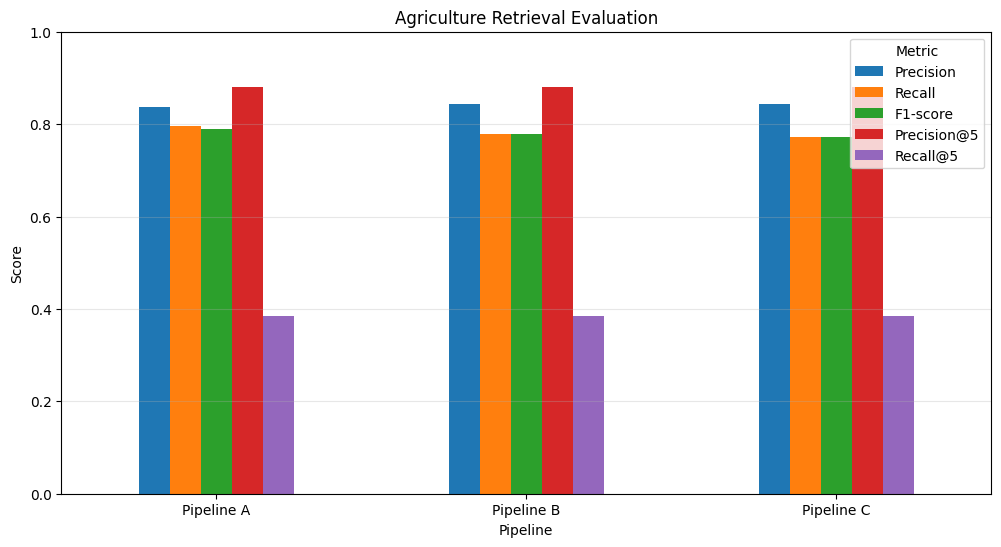

In [460]:
# ============================================================
# 6. Visual comparison of retrieval metrics
# ============================================================

import matplotlib.pyplot as plt

metric_results.set_index("Pipeline")[
    ["Precision", "Recall", "F1-score", "Precision@5", "Recall@5"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Agriculture Retrieval Evaluation")
plt.ylabel("Score")
plt.xlabel("Pipeline")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [462]:
FINAL_PIPELINE

'B'

In [463]:
pipeline_a_df
pipeline_b_df
pipeline_c_df

,doc_id,processed_tokens,pos_tags,ner_entities
0,1,"[home, |, u, |, success, story, |, farmer, association, |, farmer, ', innova...","[(home, NN), (|, NNP), (u, JJ), (|, NNP), (success, NN), (story, NN), (|, NN...","[(Us, GPE), (Success Stories, ORG), (Farmers Association, ORG), (Farmers' In..."
1,2,"[home, u, contact, u, sub, topic, principle, crop, establishment, system, ri...","[(home, NN), (u, NN), (contact, NN), (u, JJ), (sub, NN), (topic, NN), (princ...","[(US, GPE), (Rice Intensification, ORG), (Seedling Throwing Method Crop Stan..."
2,3,"[irri, rice, production, manual, irri, world, ’s, premier, research, organiz...","[(irri, JJ), (rice, CROP), (production, NN), (manual, JJ), (irri, NN), (worl...","[(Rice Production, PERSON), (Philippines, GPE), (17, CARDINAL), (IRRI, ORG),..."
3,4,"[answer, follow, question, promote, biodiversity, rice, paddy, ?, promote, b...","[(answer, RB), (follow, JJ), (question, NN), (promote, NN), (biodiversity, N...","[(IPM, ORG), (AWD, ORG), (IPM, ORG), (AWD, ORG), (Indian, NORP), (Indian, NO..."
4,5,"[grow, upland, rice, :, production, handbook, africe, rice, center, (, warda...","[(grow, NN), (upland, JJ), (rice, CROP), (:, :), (production, NN), (handbook...","[(Oikeh S.O., PERSON), (Nwilene F.E., ORG), (Agunbiade T.A., ORG), (Oladimej..."
5,6,"[editorial, front, plant, sci, ., 2023, nov, 22;14:1333904, ., doi, :, 10.33...","[(editorial, NN), (front, NN), (plant, NN), (sci, NN), (., .), (2023, CD), (...","[(Front Plant Sci, ORG), (2023, DATE), (10.3389/fpls.2023.1333904, CARDINAL)..."
6,7,"[answer, follow, question, promote, biodiversity, rice, paddy, ?, promote, b...","[(answer, RB), (follow, JJ), (question, NN), (promote, NN), (biodiversity, N...","[(IPM, ORG), (AWD, ORG), (IPM, ORG), (Indian, NORP), (Indian, NORP), (custar..."
7,8,"[home, _, _, protected_0, _, _, production, growth, pests, disease, print, p...","[(home, NN), (_, NNP), (_, NNP), (protected_0, NN), (_, NNP), (_, NNP), (pro...","[(Pests, NORP), (Print, GPE), (Farmers, ORG), (37%, PERCENT), (every year, D..."
8,9,"[integrated, pest, management, package, rice, anand, prakash, j, bentur, sri...","[(integrated, VBN), (pest, AGRI_PEST), (management, AGRI_CONCEPT), (package,...","[(INTEGRATED PEST MANAGEMENT PACKAGE, ORG), (K Sinha Ram Asre K S, ORG), (IA..."
9,10,"[university, nebraska, -, lincoln, university, nebraska, -, lincoln, digital...","[(university, NN), (nebraska, SYM), (-, :), (lincoln, NN), (university, NN),...","[(University of Nebraska - Lincoln University, ORG), (Lincoln, ORG), (Nebras..."


In [464]:
FINAL_INDEX

In [465]:
pipeline_a_vocab_size
pipeline_b_vocab_size
pipeline_c_vocab_size

16094

In [466]:
metric_results
overall_evaluation

,Pipeline,Precision,Recall,F1-score,Precision@5,Recall@5
0,A,0.837172,0.796792,0.789832,0.88,0.384954
1,B,0.844580,0.778355,0.778518,0.88,0.384954
2,C,0.844580,0.771688,0.771928,0.88,0.384954


In [467]:
df

,doc_id,file_name,format,owner,topic,source,raw_chars,text,text_length,clean_text,...,stem_then_stop,order_difference,nltk_lemmas,spacy_lemmas,lemma_difference,nltk_pos,spacy_pos,custom_pos,ner_entities,doc_label
0,1,agritech.tnau.ac.in_sri.html,.html,Amrutheshwari V,Rice cultivation practices,https://agritech.tnau.ac.in/sri.html,5652,Home | About Us | Success Stories | Farmers Association | Farmers' Innovatio...,4701,Home | About Us | Success Stories | Farmers Association | Farmers' Innovatio...,...,"[home, |, us, |, success, stori, |, farmer, associ, |, farmer, ', innov, |, ...",True,"[home, |, u, |, success, story, |, farmer, association, |, farmer, ', innova...","[home, |, we, |, success, stories, |, farmers, association, |, farmers, ', i...",True,"[(Home, NN), (|, VBP), (Us, NNP), (|, NNP), (Success, NNP), (Stories, NNP), ...","[(Home, NOUN, NN), (|, ADV, RB), (Us, PRON, PRP), (|, NOUN, NN), (Success, P...","[(Home, NN), (|, VBP), (Us, NNP), (|, NNP), (Success, NNP), (Stories, NNP), ...","[{'Entity': 'Us', 'Label': 'GPE', 'Start': 13, 'End': 15}, {'Entity': 'Succe...",D01
1,2,www.agritech.tnau.ac.in_expert_system_paddy_cultivationpractices2.html,.html,Amrutheshwari V,Rice cultivation practices,http://www.agritech.tnau.ac.in/expert_system/paddy/cultivationpractices2.htm...,12659,HOME ABOUT US CONTACT US Sub Topics Principles of Crop Establishment System ...,10211,HOME ABOUT US CONTACT US Sub Topics Principles of Crop Establishment System ...,...,"[home, us, contact, us, sub, topic, principl, crop, establish, system, rice,...",True,"[home, u, contact, u, sub, topic, principle, crop, establishment, system, ri...","[home, us, contact, us, sub, topic, principles, crop, establishment, system,...",True,"[(HOME, NNP), (US, NNP), (CONTACT, NNP), (US, NNP), (Sub, NNP), (Topics, NNP...","[(HOME, ADV, RB), (US, PROPN, NNP), (CONTACT, NOUN, NN), (US, PROPN, NNP), (...","[(HOME, NNP), (US, NNP), (CONTACT, NNP), (US, NNP), (Sub, NNP), (Topics, NNP...","[{'Entity': 'US', 'Label': 'GPE', 'Start': 11, 'End': 13}, {'Entity': 'Rice ...",D02
2,3,Rice-1.pdf,.pdf,Amrutheshwari V,Rice cultivation practices,https://drive.google.com/file/d/1W3_KGIa-sMnhvwri7Modv0QqP1M8UfrB/view?usp=d...,26086,IRRI Rice Production Manual IRRI is the world’s premier research organizatio...,25411,IRRI Rice Production Manual IRRI is the world’s premier research organizatio...,...,"[irri, rice, product, manual, irri, world, ’, premier, research, organ, dedi...",True,"[irri, rice, production, manual, irri, world, ’, premier, research, organiza...","[irri, rice, production, manual, irri, world, ’s, premier, research, organiz...",True,"[(IRRI, NNP), (Rice, NNP), (Production, NNP), (Manual, NNP), (IRRI, NNP), (w...","[(IRRI, PROPN, NNP), (Rice, PROPN, NNP), (Production, PROPN, NNP), (Manual, ...","[(IRRI, NNP), (Rice, NNP), (Production, NNP), (Manual, NNP), (IRRI, NNP), (w...","[{'Entity': 'Rice Production', 'Label': 'PERSON', 'Start': 5, 'End': 20}, {'...",D03
3,4,Copy_of_rice_qa.json,.json,Amrutheshwari V,Rice cultivation practices,https://drive.google.com/file/d/1BH0ixjCIii10rblAhkkZGRKum62SAs3G/view?usp=d...,44051,Answer the following question How can I promote biodiversity in rice paddies...,43966,Answer the following question How can I promote biodiversity in rice paddies...,...,"[answer, follow, question, promot, biodivers, rice, paddi, ?, promot, biodiv...",True,"[answer, follow, question, promote, biodiversity, rice, paddy, ?, promote, b...","[answer, following, question, promote, biodiversity, rice, paddy, ?, promote...",True,"[(Answer, NNP), (following, VBG), (question, NN), (promote, FW), (biodiversi...","[(Answer, VERB, VB), (following, ADJ, JJ), (question, NOUN, NN), (promote, V...","[(Answer, NNP), (following, VBG), (question, NN), (promote, FW), (biodiversi...","[{'Entity': 'IPM', 'Label': 'ORG', 'Start': 493, 'End': 496}, {'Entity': 'AW...",D04
4,5,Rice-2.pdf,.pdf,Amrutheshwari V,Rice cultivation practices,https://drive.google.com/file/d/1690A-9C6r53xm8D-U

In [468]:
pos_final_comparison

,Word,Expected POS,NLTK POS,NLTK POS Normalized,spaCy POS,Custom POS,ML POS,NLTK Correct,spaCy Correct,Custom Correct,ML Correct
0,fertilizer,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
1,pesticide,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
2,irrigation,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
3,cultivation,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
4,nematode,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
5,aphid,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
6,caterpillar,NOUN,JJ,ADJ,PROPN,NOUN,NOUN,False,False,True,True
7,nitrogen,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
8,phosphorus,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True
9,potassium,NOUN,NN,NOUN,NOUN,NOUN,NOUN,True,True,True,True


In [469]:
pipeline_comparison

,Measure,Pipeline A,Pipeline B,Pipeline C
0,Token Count,191008,189210,259188
1,Vocabulary Size,14503,15928,16094
2,Domain Terms,15347,21397,21676


In [471]:
inverted_index = FINAL_INDEX
display(inverted_index)

In [472]:
# ============================================================
# GUI READY PROJECT STATE
# ============================================================

import os
import joblib

os.makedirs("saved_model", exist_ok=True)

gui_state = {
    "final_pipeline": FINAL_PIPELINE,

    # Corpus
    "documents": df,

    # Pipeline information
    "pipeline_a_token_count": pipeline_a_token_count,
    "pipeline_b_token_count": pipeline_b_token_count,
    "pipeline_c_token_count": pipeline_c_token_count,

    "pipeline_a_vocab_size": pipeline_a_vocab_size,
    "pipeline_b_vocab_size": pipeline_b_vocab_size,
    "pipeline_c_vocab_size": pipeline_c_vocab_size,

    # Comparisons
    "pipeline_comparison": pipeline_comparison,

    # POS
    "pos_final_comparison": pos_final_comparison,

    # Evaluation
    "metric_results": metric_results,
    "overall_evaluation": overall_evaluation
}

joblib.dump(
    gui_state,
    "saved_model/gui_state.pkl"
)

print("GUI state saved successfully.")
print("File: saved_model/gui_state.pkl")

GUI state saved successfully.
File: saved_model/gui_state.pkl


In [473]:
import joblib

state = joblib.load("saved_model/gui_state.pkl")

print(state.keys())
print("Final pipeline:", state["final_pipeline"])

dict_keys(['final_pipeline', 'documents', 'pipeline_a_token_count', 'pipeline_b_token_count', 'pipeline_c_token_count', 'pipeline_a_vocab_size', 'pipeline_b_vocab_size', 'pipeline_c_vocab_size', 'pipeline_comparison', 'pos_final_comparison', 'metric_results', 'overall_evaluation'])
Final pipeline: B


In [474]:
import joblib
import os

pkl_path = "saved_model/gui_state.pkl"

print("Exists:", os.path.exists(pkl_path))

if os.path.exists(pkl_path):
    state = joblib.load(pkl_path)

    print("\nPKL loaded successfully.")
    print("\nSaved objects:")
    for key in state.keys():
        print("-", key)

    print("\nFinal Pipeline:", state.get("final_pipeline"))

Exists: True

PKL loaded successfully.

Saved objects:
- final_pipeline
- documents
- pipeline_a_token_count
- pipeline_b_token_count
- pipeline_c_token_count
- pipeline_a_vocab_size
- pipeline_b_vocab_size
- pipeline_c_vocab_size
- pipeline_comparison
- pos_final_comparison
- metric_results
- overall_evaluation

Final Pipeline: B


In [475]:
inverted_index

In [476]:
# ============================================================
# EXPORT FINAL INVERTED INDEX FOR GUI
# ============================================================

import json
from pathlib import Path

# Create results folder
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Convert InvertedIndex object to JSON-compatible dictionary
def index_to_json(index):

    body = {}

    for term in sorted(index.postings):

        body[term] = {
            "df": int(index.df[term]),
            "cf": int(index.cf[term]),
            "postings": index.postings[term]
        }

    return body


# Build final JSON payload
final_payload = {
    "pipeline": FINAL_PIPELINE,
    "description": PIPELINES[FINAL_PIPELINE]["label"],
    "num_documents": int(FINAL_INDEX.N),
    "vocabulary_size": int(FINAL_INDEX.vocabulary_size),
    "index": index_to_json(FINAL_INDEX)
}


# Save JSON file
output_path = RESULTS_DIR / "inverted_index.json"

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_payload,
        f,
        ensure_ascii=False,
        indent=2
    )


print("============================================================")
print("INVERTED INDEX EXPORTED SUCCESSFULLY")
print("============================================================")
print("File:", output_path)
print("Pipeline:", FINAL_PIPELINE)
print("Documents:", FINAL_INDEX.N)
print("Vocabulary:", FINAL_INDEX.vocabulary_size)
print("File exists:", output_path.exists())

INVERTED INDEX EXPORTED SUCCESSFULLY
File: results/inverted_index.json
Pipeline: B
Documents: 30
Vocabulary: 15928
File exists: True
